# Project 8 — Multifactor Forecasting + Full Corporate-Bond MILP

This notebook extends the existing Project 8 research pipeline into a full multifactor forecasting and corporate-bond portfolio optimization framework:

1. Load and validate the existing daily corporate-bond panel.
2. Engineer value, momentum, carry, liquidity, risk, and segment features.
3. Apply bond eligibility rules, including available maturity and issue-size filters.
4. Compare linear, nonlinear, tree, boosted-tree, and neural-network multifactor models.
5. Generate strictly out-of-sample expected-return forecasts using walk-forward estimation.
6. Evaluate forecast performance using MAE, RMSE, rank IC, IC t-statistics, and forecast-quintile spreads.
7. Construct a model-specific target portfolio using expected-return forecasts and MRR-based liquidity information.
8. Estimate MRR-based confidence, illiquidity, and dynamic position capacity.
9. Solve a full corporate-bond MILP with:
   - target-weight tracking,
   - sector-exposure tracking,
   - explicit holding variables,
   - explicit trade-ticket variables,
   - expected-return reward,
   - MRR/capacity-dependent position limits,
   - piecewise illiquidity penalties,
   - piecewise transaction costs,
   - issuer and sector concentration constraints,
   - subordination and perpetual constraints,
   - holding-count and trade-ticket limits.
10. Run the portfolio through time using weekly rebalancing and previous-period holdings.
11. Evaluate gross and net portfolio performance, turnover, transaction costs, drawdown, holdings, and trade activity.
12. Perform robustness and transaction-cost sensitivity tests across alternative liquidity and portfolio specifications.

The current Project 8 notebook remains the **baseline**. This notebook is the enhanced multifactor forecasting and full MILP research version.


## Stage 0 — Environment and configuration

The notebook expects either:

- an existing `panel` DataFrame in memory, or
- `panel_project8.parquet` in the working directory.

Required core columns are checked before modeling. Optional fields are used when available.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Callable

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import Bounds, LinearConstraint, milp
from scipy.sparse import lil_matrix, csr_matrix

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PolynomialFeatures,
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    ElasticNet,
)

from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    GradientBoostingRegressor,
)

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

BASE = Path(".")
PANEL_PATH = BASE / "panel_project8.parquet"

print("Environment ready.")

Environment ready.


In [2]:
@dataclass
class ModelConfig:
    horizon_days: int = 5
    rebalance_frequency: str = "W-FRI"
    minimum_training_days: int = 120
    refit_frequency: str = "MS"
    prediction_clip_quantiles: tuple[float, float] = (0.01, 0.99)

@dataclass
class PortfolioPolicy:
    max_weight_default: float = 0.01
    min_dynamic_cap: float = 0.005
    max_dynamic_cap: float = 0.030
    min_position: float = 0.0

    max_issuer_weight: float = 0.05
    max_sector_weight: float = 0.25
    min_ig_weight: float = 0.70
    max_hy_weight: float = 0.30

    max_holdings: int = 75
    max_tickets: int = 30

    max_subordinated_weight: float = 0.20
    max_perpetual_weight: float = 0.10

    min_years_to_maturity: float = 1.0
    max_years_to_maturity: float = 15.0
    min_outstanding_amount: float = 100_000_000

@dataclass
class ObjectivePenalties:
    target_tracking: float = 4.0
    segment_tracking: float = 2.0
    names: float = 0.001
    tickets: float = 0.002
    expected_return: float = 10.0
    illiquidity: float = 1.0
    transaction_cost: float = 1.0

MODEL_CONFIG = ModelConfig()
POLICY = PortfolioPolicy()
LAMBDA = ObjectivePenalties()

print(MODEL_CONFIG)
print(POLICY)
print(LAMBDA)


ModelConfig(horizon_days=5, rebalance_frequency='W-FRI', minimum_training_days=120, refit_frequency='MS', prediction_clip_quantiles=(0.01, 0.99))
PortfolioPolicy(max_weight_default=0.01, min_dynamic_cap=0.005, max_dynamic_cap=0.03, min_position=0.0, max_issuer_weight=0.05, max_sector_weight=0.25, min_ig_weight=0.7, max_hy_weight=0.3, max_holdings=75, max_tickets=30, max_subordinated_weight=0.2, max_perpetual_weight=0.1, min_years_to_maturity=1.0, max_years_to_maturity=15.0, min_outstanding_amount=100000000)
ObjectivePenalties(target_tracking=4.0, segment_tracking=2.0, names=0.001, tickets=0.002, expected_return=10.0, illiquidity=1.0, transaction_cost=1.0)


In [3]:
import pandas as pd

file_path = "/Users/sangpark/Documents/Deepmm/Operation Research/panel.parquet"

panel = pd.read_parquet(file_path)

print(panel.shape)
panel.head()

(5999996, 22)


,cusip,date,P_TRACE,P_AXOR,L_AXOR,n_trades,P_BCQ,L_BCQ,L_TRACE,D_t,...,L_AXOR_pct,L_BCQ_pct,L_TRACE_pct,L_TRACE_roll,L_TRACE_roll_pct,L_TRACE_MRR,R1_MRR,C1_MRR,n_mrr_trades,L_TRACE_MRR_pct
0,00033GAA3,2024-01-16,98.892750,98.921802,0.654559,20,NaN,NaN,0.000294,NaN,...,0.006617,NaN,0.000294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00033GAA3,2024-01-17,96.930786,97.310716,1.007398,14,NaN,NaN,0.003904,NaN,...,0.010352,NaN,0.003904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00033GAA3,2024-01-18,97.560000,97.289105,1.283986,5,NaN,NaN,0.002784,NaN,...,0.013198,NaN,0.002784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00033GAA3,2024-01-19,97.800000,97.735035,1.022091,2,NaN,NaN,0.000665,NaN,...,0.010458,NaN,0.000665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00033GAA3,2024-01-22,97.141842,97.159995,0.492521,19,NaN,NaN,0.000187,NaN,...,0.005069,NaN,0.000187,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## Stage 1 — Load and validate the daily panel


In [4]:

if "panel" in globals():
    research_panel = panel.copy()   
    print("Using `panel` from the current notebook session.")
elif PANEL_PATH.exists():
    research_panel = pd.read_parquet(PANEL_PATH)
    print(f"Loaded {PANEL_PATH}")
else:
    raise FileNotFoundError(
        "No in-memory `panel` and panel_project8.parquet was not found. "
        "Run the original Project 8 data-ingestion notebook first."
    )

research_panel["date"] = pd.to_datetime(research_panel["date"])
research_panel["cusip"] = research_panel["cusip"].astype(str)

CORE_COLUMNS = ["cusip", "date", "P_TRACE"]
missing_core = [c for c in CORE_COLUMNS if c not in research_panel.columns]
if missing_core:
    raise KeyError(f"Missing required columns: {missing_core}")

print(
    f"Rows: {len(research_panel):,} | "
    f"Bonds: {research_panel['cusip'].nunique():,} | "
    f"Dates: {research_panel['date'].nunique():,}"
)
print(research_panel["date"].min(), "to", research_panel["date"].max())


Using `panel` from the current notebook session.
Rows: 5,999,996 | Bonds: 26,752 | Dates: 557
2023-04-03 00:00:00 to 2025-06-26 00:00:00



## Stage 2 — Feature engineering

This stage separates the roles clearly:

- **Expected-return factors:** AXOR/BCQ relative value, momentum, carry, rating, maturity, and sector.
- **Liquidity factors:** MRR, Roll, BPW, BondCliQ spread, AXOR uncertainty, trade count.
- **Risk and implementation factors:** issue size, credit segment, subordination, perpetual status, and price disagreement \(D_t\).


In [5]:
def safe_numeric(df: pd.DataFrame, columns: list[str]) -> None:
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

def first_existing(df: pd.DataFrame, names: list[str], default=np.nan):
    for name in names:
        if name in df.columns:
            return df[name]
    return pd.Series(default, index=df.index)

def build_model_features(df: pd.DataFrame, horizon_days: int = 5) -> pd.DataFrame:
    out = df.copy().sort_values(["cusip", "date"]).reset_index(drop=True)

    safe_numeric(
        out,
        [
            "P_TRACE", "P_AXOR", "P_BCQ", "L_AXOR", "L_BCQ",
            "L_TRACE_MRR", "L_TRACE_MRR_pct", "L_TRACE_roll",
            "L_TRACE_roll_pct", "L_BPW", "L_AMIHUD", "n_trades",
            "coupon_rate", "years_to_maturity", "outstanding_amount",
        ],
    )

    # Relative-value factors
    if "P_AXOR" in out:
        out["axor_value"] = (out["P_AXOR"] - out["P_TRACE"]) / out["P_TRACE"]
    if "P_BCQ" in out:
        out["bcq_value"] = (out["P_BCQ"] - out["P_TRACE"]) / out["P_TRACE"]

    # Liquidity measures normalized by price when raw versions exist
    if "L_BCQ_pct" not in out and "L_BCQ" in out:
        out["L_BCQ_pct"] = out["L_BCQ"] / out["P_TRACE"]
    if "L_AXOR_pct" not in out and "L_AXOR" in out:
        out["L_AXOR_pct"] = out["L_AXOR"] / out["P_TRACE"]
    if "L_TRACE_roll_pct" not in out and "L_TRACE_roll" in out:
        out["L_TRACE_roll_pct"] = out["L_TRACE_roll"] / out["P_TRACE"]
    if "L_TRACE_MRR_pct" not in out and "L_TRACE_MRR" in out:
        out["L_TRACE_MRR_pct"] = out["L_TRACE_MRR"] / out["P_TRACE"]

    # Momentum
    out["momentum_5d"] = out.groupby("cusip")["P_TRACE"].pct_change(5)
    out["momentum_20d"] = out.groupby("cusip")["P_TRACE"].pct_change(20)

    # Carry proxy
    coupon = first_existing(out, ["coupon_rate", "coupon", "cpn"])
    out["carry_proxy"] = pd.to_numeric(coupon, errors="coerce") / out["P_TRACE"]

    # Cross-input disagreement
    price_cols = [c for c in ["P_TRACE", "P_BCQ", "P_AXOR"] if c in out.columns]
    if len(price_cols) >= 2:
        denom = out["P_AXOR"] if "P_AXOR" in out else out["P_TRACE"]
        out["D_t"] = out[price_cols].std(axis=1, ddof=0) / denom.replace(0, np.nan)

    # Capacity and size
    outstanding = first_existing(
        out,
        ["outstanding_amount", "amount_outstanding", "amt_outstanding", "issue_size"],
    )
    out["outstanding_amount_clean"] = pd.to_numeric(outstanding, errors="coerce")
    out["ln_outstanding_amount"] = np.log1p(out["outstanding_amount_clean"])

    # Corporate-bond classifications
    out["sector"] = first_existing(out, ["sector", "industry"], "Unknown").fillna("Unknown").astype(str)
    out["issuer"] = first_existing(
        out, ["issuer_name", "issuer", "company_name"], out["cusip"]
    ).fillna(out["cusip"]).astype(str)

    quality = first_existing(out, ["quality_flag", "rating_bucket", "ig_hy"], "Unknown")
    out["quality_flag"] = quality.fillna("Unknown").astype(str).str.upper()
    out["is_ig"] = out["quality_flag"].str.contains(r"\bIG\b|INVESTMENT", regex=True).astype(int)
    out["is_hy"] = out["quality_flag"].str.contains(r"\bHY\b|HIGH YIELD", regex=True).astype(int)

    out["years_to_maturity"] = pd.to_numeric(
        first_existing(out, ["years_to_maturity", "maturity_years"]),
        errors="coerce",
    )

    subordinated = first_existing(
        out, ["subordinated_share", "is_subordinated", "subordinated"], 0
    )
    out["is_subordinated"] = (
        pd.to_numeric(subordinated, errors="coerce").fillna(0) > 0
    ).astype(int)

    perpetual = first_existing(out, ["perpetual_share", "is_perpetual", "perpetual"], 0)
    out["is_perpetual"] = (
        pd.to_numeric(perpetual, errors="coerce").fillna(0) > 0
    ).astype(int)

    # Forward-return target — generated without using future information as a feature
    out[f"forward_return_{horizon_days}d"] = (
        out.groupby("cusip")["P_TRACE"].shift(-horizon_days) / out["P_TRACE"] - 1
    )

    return out

model_panel = build_model_features(
    research_panel,
    horizon_days=MODEL_CONFIG.horizon_days,
)

TARGET_COL = f"forward_return_{MODEL_CONFIG.horizon_days}d"

print("Feature panel:", model_panel.shape)
print("Target:", TARGET_COL)


Feature panel: (5999996, 38)
Target: forward_return_5d


In [16]:

NUMERIC_FEATURE_CANDIDATES = [
    "axor_value",
    "bcq_value",
    "momentum_5d",
    "momentum_20d",
    "carry_proxy",
    "L_TRACE_MRR_pct",
    "L_TRACE_roll_pct",
    "L_BCQ_pct",
    "L_AXOR_pct",
    "L_BPW",
    "L_AMIHUD",
    "D_t",
    "n_trades",
    "years_to_maturity",
    "ln_outstanding_amount",
]

CATEGORICAL_FEATURE_CANDIDATES = [
    "sector",
    "quality_flag",
]

NUMERIC_FEATURES = [
    c for c in NUMERIC_FEATURE_CANDIDATES
    if c in model_panel.columns and model_panel[c].notna().sum() > 0
]
CATEGORICAL_FEATURES = [
    c for c in CATEGORICAL_FEATURE_CANDIDATES
    if c in model_panel.columns and model_panel[c].notna().sum() > 0
]

print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)


Numeric features: ['axor_value', 'bcq_value', 'momentum_5d', 'momentum_20d', 'L_TRACE_MRR_pct', 'L_TRACE_roll_pct', 'L_BCQ_pct', 'L_AXOR_pct', 'D_t', 'n_trades']
Categorical features: ['sector', 'quality_flag']



## Stage 3 — Eligibility and policy filters


In [17]:
def apply_research_eligibility(
    df: pd.DataFrame,
    policy: PortfolioPolicy = POLICY,
) -> pd.DataFrame:
    out = df.copy()

    mask = out["P_TRACE"].notna() & (out["P_TRACE"] > 0)

    if "years_to_maturity" in out:
        maturity_ok = (
            out["years_to_maturity"].isna()
            | out["years_to_maturity"].between(
                policy.min_years_to_maturity,
                policy.max_years_to_maturity,
            )
        )
        mask &= maturity_ok

    if "outstanding_amount_clean" in out:
        size_ok = (
            out["outstanding_amount_clean"].isna()
            | (out["outstanding_amount_clean"] >= policy.min_outstanding_amount)
        )
        mask &= size_ok

    return out.loc[mask].copy()

eligible_panel = apply_research_eligibility(model_panel)
print(
    f"Eligible rows: {len(eligible_panel):,} | "
    f"Bonds: {eligible_panel['cusip'].nunique():,}"
)


Eligible rows: 5,999,996 | Bonds: 26,752



## Stage 4 — Multifactor model candidates

All models receive the same information set and predict the same future-return target.

Models:

1. OLS
2. Ridge
3. Elastic Net
4. Polynomial/interaction Ridge — interpretable nonlinear multifactor model
5. Decision-tree ensemble / Random Forest
6. Boosted Trees
7. Small Neural Network

The same out-of-sample predictions later enter the same MILP.


In [18]:

def make_preprocessor(scale_numeric: bool = True) -> ColumnTransformer:
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(numeric_steps),
                NUMERIC_FEATURES,
            ),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
    )

def make_model_registry() -> dict[str, Pipeline]:
    linear_pre = make_preprocessor(scale_numeric=True)
    tree_pre = make_preprocessor(scale_numeric=False)

    # Polynomial model uses numeric factors only to avoid exploding one-hot interactions.
    poly_pre = ColumnTransformer(
        transformers=[
            (
                "num_poly",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                        ("scaler", StandardScaler()),
                    ]
                ),
                NUMERIC_FEATURES,
            )
        ],
        remainder="drop",
    )

    return {
        "OLS": Pipeline(
            [("pre", linear_pre), ("model", LinearRegression())]
        ),
        "Ridge": Pipeline(
            [("pre", linear_pre), ("model", Ridge(alpha=10.0))]
        ),
        "ElasticNet": Pipeline(
            [
                ("pre", linear_pre),
                (
                    "model",
                    ElasticNet(
                        alpha=0.001,
                        l1_ratio=0.25,
                        max_iter=10_000,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "NonlinearPolynomialRidge": Pipeline(
            [("pre", poly_pre), ("model", Ridge(alpha=25.0))]
        ),
        "RandomForest": Pipeline(
            [
                ("pre", tree_pre),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=250,
                        max_depth=8,
                        min_samples_leaf=20,
                        n_jobs=-1,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "BoostedTrees": Pipeline(
            [
                ("pre", tree_pre),
                (
                    "model",
                    GradientBoostingRegressor(
                        n_estimators=200,
                        learning_rate=0.03,
                        max_depth=3,
                        min_samples_leaf=20,
                        loss="huber",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "NeuralNetwork": Pipeline(
            [
                ("pre", linear_pre),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(32, 16),
                        activation="relu",
                        alpha=0.01,
                        learning_rate_init=0.001,
                        early_stopping=True,
                        validation_fraction=0.15,
                        max_iter=300,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }

MODEL_REGISTRY = make_model_registry()
list(MODEL_REGISTRY)


['OLS',
 'Ridge',
 'ElasticNet',
 'NonlinearPolynomialRidge',
 'RandomForest',
 'BoostedTrees',
 'NeuralNetwork']


## Stage 5 — Walk-forward out-of-sample forecasts

This is deliberately date-based.

For every prediction period:

- training observations occur strictly before the test period;
- model fitting never sees future returns from the test period;
- each model produces `mu_hat`, the expected-return input to the MILP.


In [19]:
def cross_sectional_rank_ic(group: pd.DataFrame) -> float:
    use = group[["mu_hat", TARGET_COL]].dropna()
    if len(use) < 5:
        return np.nan
    return use["mu_hat"].corr(use[TARGET_COL], method="spearman")

def walk_forward_predictions(
    df: pd.DataFrame,
    models: dict[str, Pipeline],
    minimum_training_days: int = 120,
    refit_frequency: str = "MS",
) -> pd.DataFrame:
    use = df.dropna(subset=[TARGET_COL]).copy()
    use = use.sort_values("date")

    all_dates = pd.Series(use["date"].drop_duplicates().sort_values())
    if len(all_dates) <= minimum_training_days:
        raise ValueError(
            f"Only {len(all_dates)} dates are available; "
            f"minimum_training_days={minimum_training_days} is too large."
        )

    first_test_date = all_dates.iloc[minimum_training_days]
    test_periods = (
        pd.date_range(
            first_test_date.to_period("M").start_time,
            use["date"].max().to_period("M").start_time,
            freq=refit_frequency,
        )
    )

    prediction_frames = []

    feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES

    for period_start in test_periods:
        period_end = period_start + pd.offsets.MonthBegin(1)

        train = use[use["date"] < period_start].dropna(subset=[TARGET_COL])
        test = use[
            (use["date"] >= period_start)
            & (use["date"] < period_end)
        ].copy()

        if train["date"].nunique() < minimum_training_days or test.empty:
            continue

        y_train = train[TARGET_COL].copy()
        q_low, q_high = y_train.quantile(MODEL_CONFIG.prediction_clip_quantiles)
        y_train = y_train.clip(q_low, q_high)

        for model_name, estimator in models.items():
            fitted = estimator.fit(train[feature_cols], y_train)
            predicted = fitted.predict(test[feature_cols])

            frame = test[
                [
                    "cusip", "date", TARGET_COL, "P_TRACE",
                    "sector", "issuer", "quality_flag",
                    "is_ig", "is_hy", "is_subordinated", "is_perpetual",
                ]
                + [c for c in [
                    "L_TRACE_MRR_pct", "L_BCQ_pct", "L_AXOR_pct",
                    "D_t", "n_trades", "outstanding_amount_clean",
                    "years_to_maturity",
                ] if c in test.columns]
            ].copy()

            frame["model"] = model_name
            frame["mu_hat"] = predicted
            frame["train_end"] = train["date"].max()
            prediction_frames.append(frame)

        print(
            f"{period_start:%Y-%m}: trained through "
            f"{train['date'].max().date()} | test rows={len(test):,}"
        )

    if not prediction_frames:
        raise RuntimeError("No walk-forward predictions were generated.")

    return pd.concat(prediction_frames, ignore_index=True)

# This cell can be computationally intensive.
# Run it after verifying the panel and feature coverage.
#
# oos_predictions = walk_forward_predictions(
#     eligible_panel,
#     MODEL_REGISTRY,
#     minimum_training_days=MODEL_CONFIG.minimum_training_days,
#     refit_frequency=MODEL_CONFIG.refit_frequency,
# )
#
# print(oos_predictions.shape)
# oos_predictions.head()



## Stage 6 — Forecast-level model comparison


In [20]:

def predictive_model_summary(predictions: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for model_name, g in predictions.groupby("model"):
        use = g.dropna(subset=["mu_hat", TARGET_COL]).copy()

        daily_ic = (
            use.groupby("date", group_keys=False)
            .apply(cross_sectional_rank_ic)
            .dropna()
        )

        use["forecast_quintile"] = use.groupby("date")["mu_hat"].transform(
            lambda s: pd.qcut(
                s.rank(method="first"),
                q=min(5, s.notna().sum()),
                labels=False,
                duplicates="drop",
            )
        )

        quintile_return = (
            use.groupby("forecast_quintile")[TARGET_COL]
            .mean()
            .sort_index()
        )
        spread = (
            quintile_return.iloc[-1] - quintile_return.iloc[0]
            if len(quintile_return) >= 2 else np.nan
        )

        rows.append(
            {
                "model": model_name,
                "mae": mean_absolute_error(use[TARGET_COL], use["mu_hat"]),
                "rmse": mean_squared_error(
                    use[TARGET_COL], use["mu_hat"]
                ) ** 0.5,
                "mean_rank_ic": daily_ic.mean(),
                "rank_ic_tstat": (
                    daily_ic.mean() / daily_ic.std()
                    * np.sqrt(len(daily_ic))
                    if len(daily_ic) > 1 and daily_ic.std() > 0
                    else np.nan
                ),
                "top_minus_bottom_return": spread,
                "n_predictions": len(use),
                "n_test_dates": use["date"].nunique(),
            }
        )

    return pd.DataFrame(rows).sort_values(
        ["mean_rank_ic", "top_minus_bottom_return"],
        ascending=False,
    )

# forecast_summary = predictive_model_summary(oos_predictions)
# forecast_summary



## Stage 7 — MRR liquidity score, confidence, and dynamic capacity

Lower MRR means greater observed liquidity.

The raw MRR estimate is shrunk toward the date median when trade support is weak.  
The resulting liquidity score controls both:

- the illiquidity term in the objective;
- the security-specific maximum weight.


In [21]:

def add_liquidity_and_capacity(
    df: pd.DataFrame,
    policy: PortfolioPolicy = POLICY,
) -> pd.DataFrame:
    out = df.copy()

    if "L_TRACE_MRR_pct" not in out:
        raise KeyError("L_TRACE_MRR_pct is required for the MRR-based full MILP.")

    out["mrr_rank"] = out.groupby("date")["L_TRACE_MRR_pct"].rank(
        method="average",
        pct=True,
        ascending=True,
    )
    out["mrr_liquidity_score"] = 1.0 - out["mrr_rank"]

    trade_count = pd.to_numeric(
        first_existing(out, ["n_mrr_trades", "n_trades"], 0),
        errors="coerce",
    ).fillna(0)

    out["mrr_confidence"] = (trade_count / 100.0).clip(0, 1)

    daily_median = out.groupby("date")["mrr_liquidity_score"].transform("median")
    out["mrr_liquidity_score_shrunk"] = (
        out["mrr_confidence"] * out["mrr_liquidity_score"]
        + (1 - out["mrr_confidence"]) * daily_median
    )

    # Security-specific maximum position.
    out["dynamic_weight_cap"] = (
        policy.min_dynamic_cap
        + (policy.max_dynamic_cap - policy.min_dynamic_cap)
        * out["mrr_liquidity_score_shrunk"].clip(0, 1)
    )

    # D(t) haircut: disagreement reduces capacity.
    if "D_t" in out:
        dt_rank = out.groupby("date")["D_t"].rank(pct=True, ascending=True)
        disagreement_multiplier = 1.0 - 0.50 * dt_rank.fillna(0.5)
        out["dynamic_weight_cap"] *= disagreement_multiplier

    out["dynamic_weight_cap"] = out["dynamic_weight_cap"].clip(
        lower=policy.min_dynamic_cap * 0.5,
        upper=policy.max_dynamic_cap,
    )

    # Illiquidity index: higher means less liquid.
    out["illiquidity_index"] = (
        1.0 - out["mrr_liquidity_score_shrunk"].clip(0, 1)
    )

    return out

# oos_predictions = add_liquidity_and_capacity(oos_predictions)



## Stage 8 — Construct the model-specific target portfolio

The target portfolio represents what the return model would like to own before implementation constraints.

This initial target uses positive cross-sectional forecast strength, then normalizes weights.  
The full MILP may deviate from it to improve liquidity and reduce holdings, tickets, and costs.


In [22]:

def make_target_weights(day: pd.DataFrame) -> pd.Series:
    score = day["mu_hat"].rank(pct=True)
    positive_score = (score - 0.50).clip(lower=0)

    # Prefer bonds that have at least moderate liquidity.
    if "mrr_liquidity_score_shrunk" in day:
        positive_score *= 0.50 + 0.50 * day["mrr_liquidity_score_shrunk"].fillna(0.5)

    if positive_score.sum() <= 0:
        positive_score = pd.Series(1.0, index=day.index)

    return positive_score / positive_score.sum()

def attach_target_weights(predictions: pd.DataFrame) -> pd.DataFrame:
    out = predictions.copy()
    out["target_weight"] = (
        out.groupby(["model", "date"], group_keys=False)
        .apply(make_target_weights)
    )
    return out

# oos_predictions = attach_target_weights(oos_predictions)



## Stage 9 — Full corporate-bond MILP

### Decision variables

For \(n\) eligible bonds and \(K\) sectors:

- `w[i]`: final weight
- `y[i]`: binary holding indicator
- `z[i]`: binary trade-ticket indicator
- `track[i]`: absolute target-weight deviation
- `trade[i]`: absolute change from current weight
- `sector_dev[s]`: absolute sector deviation
- `liq_seg_1..3[i]`: piecewise position-size segments
- `tc_seg_1..3[i]`: piecewise trade-size segments

### Objective

Minimize:

- target tracking error,
- sector tracking error,
- number of names,
- number of tickets,
- negative expected return,
- piecewise illiquidity,
- piecewise transaction cost.

### Corporate-bond constraints

- fully invested,
- dynamic MRR-dependent security caps,
- issuer and sector limits,
- IG/HY limits,
- subordination and perpetual limits,
- maximum holdings and tickets,
- position/trade linking constraints.


In [23]:

@dataclass
class FullMILPResult:
    success: bool
    status: int
    message: str
    objective: float
    weights: pd.Series
    held: pd.Series
    traded: pd.Series
    buys: pd.Series
    sells: pd.Series
    diagnostics: dict[str, Any] = field(default_factory=dict)

class LinearSystemBuilder:
    def __init__(self, n_vars: int):
        self.n_vars = n_vars
        self.rows: list[dict[int, float]] = []
        self.lb: list[float] = []
        self.ub: list[float] = []

    def add(
        self,
        coefficients: dict[int, float],
        lower: float = -np.inf,
        upper: float = np.inf,
    ) -> None:
        self.rows.append(coefficients)
        self.lb.append(lower)
        self.ub.append(upper)

    def build(self) -> LinearConstraint:
        mat = lil_matrix((len(self.rows), self.n_vars), dtype=float)
        for r, coeffs in enumerate(self.rows):
            for c, value in coeffs.items():
                if value != 0:
                    mat[r, c] = value
        return LinearConstraint(
            csr_matrix(mat),
            np.asarray(self.lb, dtype=float),
            np.asarray(self.ub, dtype=float),
        )

def solve_full_corporate_bond_milp(
    day: pd.DataFrame,
    current_weights: pd.Series | None = None,
    policy: PortfolioPolicy = POLICY,
    penalties: ObjectivePenalties = LAMBDA,
) -> FullMILPResult:
    df = day.copy().reset_index(drop=True)
    n = len(df)

    if n == 0:
        return FullMILPResult(
            False, -1, "Empty eligible universe", np.nan,
            pd.Series(dtype=float), pd.Series(dtype=bool),
            pd.Series(dtype=bool), pd.Series(dtype=float),
            pd.Series(dtype=float),
        )

    required = [
        "cusip", "mu_hat", "target_weight",
        "dynamic_weight_cap", "illiquidity_index",
        "sector", "issuer",
    ]
    missing = [c for c in required if c not in df]
    if missing:
        raise KeyError(f"Full MILP missing columns: {missing}")

    cusips = df["cusip"].astype(str)
    if current_weights is None:
        w0 = np.zeros(n)
    else:
        w0 = (
            current_weights.reindex(cusips)
            .fillna(0)
            .to_numpy(dtype=float)
        )

    target = df["target_weight"].fillna(0).to_numpy(dtype=float)
    target = target / target.sum() if target.sum() > 0 else np.full(n, 1 / n)

    mu = df["mu_hat"].fillna(0).to_numpy(dtype=float)
    mu_scale = np.nanstd(mu)
    if mu_scale > 0:
        mu = (mu - np.nanmean(mu)) / mu_scale

    caps = df["dynamic_weight_cap"].fillna(policy.max_weight_default).to_numpy(float)
    caps = np.clip(caps, policy.min_position, policy.max_dynamic_cap)

    illiq = df["illiquidity_index"].fillna(0.5).clip(0, 1).to_numpy(float)

    # Variable slices
    start = 0
    sl_w = slice(start, start + n); start += n
    sl_y = slice(start, start + n); start += n
    sl_z = slice(start, start + n); start += n
    sl_track = slice(start, start + n); start += n
    sl_trade = slice(start, start + n); start += n

    sectors = sorted(df["sector"].fillna("Unknown").astype(str).unique())
    k = len(sectors)
    sl_sector_dev = slice(start, start + k); start += k

    sl_l1 = slice(start, start + n); start += n
    sl_l2 = slice(start, start + n); start += n
    sl_l3 = slice(start, start + n); start += n

    sl_t1 = slice(start, start + n); start += n
    sl_t2 = slice(start, start + n); start += n
    sl_t3 = slice(start, start + n); start += n

    n_vars = start

    def idx(sl: slice, i: int) -> int:
        return sl.start + i

    # Objective
    c = np.zeros(n_vars)

    c[sl_w] = -penalties.expected_return * mu
    c[sl_y] = penalties.names
    c[sl_z] = penalties.tickets
    c[sl_track] = penalties.target_tracking
    c[sl_sector_dev] = penalties.segment_tracking

    # Convex piecewise illiquidity slopes become steeper with position size.
    c[sl_l1] = penalties.illiquidity * (1.0 + 2.0 * illiq)
    c[sl_l2] = penalties.illiquidity * (2.0 + 4.0 * illiq)
    c[sl_l3] = penalties.illiquidity * (4.0 + 8.0 * illiq)

    # Transaction costs: use BCQ spread, then AXOR, then cross-sectional fallback.
    spread = pd.to_numeric(
        first_existing(df, ["L_BCQ_pct", "L_AXOR_pct"], np.nan),
        errors="coerce",
    )
    spread_fallback = spread.median() if spread.notna().any() else 0.005
    spread = spread.fillna(spread_fallback).clip(lower=0).to_numpy(float)

    c[sl_t1] = penalties.transaction_cost * spread * 0.50
    c[sl_t2] = penalties.transaction_cost * spread * 1.00
    c[sl_t3] = penalties.transaction_cost * spread * 2.00

    # Bounds
    lower = np.zeros(n_vars)
    upper = np.full(n_vars, np.inf)

    upper[sl_w] = caps
    upper[sl_y] = 1
    upper[sl_z] = 1
    upper[sl_track] = 1
    upper[sl_trade] = 1
    upper[sl_sector_dev] = 1

    # Piecewise position segments: 0-25%, 25-60%, 60-100% of each dynamic cap.
    upper[sl_l1] = 0.25 * caps
    upper[sl_l2] = 0.35 * caps
    upper[sl_l3] = 0.40 * caps

    # Piecewise trade capacity. Small trades are cheap; large trades are expensive.
    trade_capacity = np.maximum(caps, 1e-5)

    # Allow enough capacity to resize an existing position even when
    # today's liquidity-dependent position cap falls below yesterday's weight.
    #trade_capacity = np.maximum(
    #np.maximum(caps, w0),
    #1e-5,
    #can edit
    upper[sl_t1] = 0.10 * trade_capacity
    upper[sl_t2] = 0.20 * trade_capacity
    upper[sl_t3] = 0.70 * trade_capacity

    integrality = np.zeros(n_vars, dtype=int)
    integrality[sl_y] = 1
    integrality[sl_z] = 1

    system = LinearSystemBuilder(n_vars)

    # Fully invested
    system.add(
        {idx(sl_w, i): 1.0 for i in range(n)},
        lower=1.0,
        upper=1.0,
    )

    for i in range(n):
        # w_i <= cap_i * y_i
        system.add(
            {
                idx(sl_w, i): 1.0,
                idx(sl_y, i): -caps[i],
            },
            upper=0.0,
        )

        # Optional minimum weight when held
        if policy.min_position > 0:
            system.add(
                {
                    idx(sl_w, i): -1.0,
                    idx(sl_y, i): policy.min_position,
                },
                upper=0.0,
            )

        # Absolute target distance
        # track_i >= w_i - target_i
        system.add(
            {
                idx(sl_w, i): 1.0,
                idx(sl_track, i): -1.0,
            },
            upper=target[i],
        )
        # track_i >= target_i - w_i
        system.add(
            {
                idx(sl_w, i): -1.0,
                idx(sl_track, i): -1.0,
            },
            upper=-target[i],
        )

        # Absolute trade distance
        # trade_i >= w_i - w0_i
        system.add(
            {
                idx(sl_w, i): 1.0,
                idx(sl_trade, i): -1.0,
            },
            upper=w0[i],
        )
        # trade_i >= w0_i - w_i
        system.add(
            {
                idx(sl_w, i): -1.0,
                idx(sl_trade, i): -1.0,
            },
            upper=-w0[i],
        )

        # Trade-ticket link: trade_i <= M_i z_i
        big_m = max(caps[i], w0[i], 1e-5)
        system.add(
            {
                idx(sl_trade, i): 1.0,
                idx(sl_z, i): -big_m,
            },
            upper=0.0,
        )

        # Piecewise illiquidity decomposition
        system.add(
            {
                idx(sl_w, i): 1.0,
                idx(sl_l1, i): -1.0,
                idx(sl_l2, i): -1.0,
                idx(sl_l3, i): -1.0,
            },
            lower=0.0,
            upper=0.0,
        )

        # Piecewise transaction-cost decomposition
        system.add(
            {
                idx(sl_trade, i): 1.0,
                idx(sl_t1, i): -1.0,
                idx(sl_t2, i): -1.0,
                idx(sl_t3, i): -1.0,
            },
            lower=0.0,
            upper=0.0,
        )

    # Maximum names and tickets
    system.add(
        {idx(sl_y, i): 1.0 for i in range(n)},
        upper=float(min(policy.max_holdings, n)),
    )
    system.add(
        {idx(sl_z, i): 1.0 for i in range(n)},
        upper=float(min(policy.max_tickets, n)),
    )

    # Issuer caps
    for issuer, members in df.groupby("issuer").groups.items():
        system.add(
            {idx(sl_w, int(i)): 1.0 for i in members},
            upper=policy.max_issuer_weight,
        )

    # Sector caps and target-sector deviations
    target_sector = (
        pd.Series(target, index=df.index)
        .groupby(df["sector"].fillna("Unknown").astype(str))
        .sum()
    )

    for s_idx, sector in enumerate(sectors):
        members = df.index[df["sector"].fillna("Unknown").astype(str) == sector].tolist()

        system.add(
            {idx(sl_w, int(i)): 1.0 for i in members},
            upper=policy.max_sector_weight,
        )

        coeff_pos = {idx(sl_w, int(i)): 1.0 for i in members}
        coeff_pos[idx(sl_sector_dev, s_idx)] = -1.0
        system.add(coeff_pos, upper=float(target_sector.get(sector, 0.0)))

        coeff_neg = {idx(sl_w, int(i)): -1.0 for i in members}
        coeff_neg[idx(sl_sector_dev, s_idx)] = -1.0
        system.add(coeff_neg, upper=-float(target_sector.get(sector, 0.0)))

    # IG/HY
    ig_members = df.index[df["is_ig"].fillna(0).astype(int) == 1].tolist()
    hy_members = df.index[df["is_hy"].fillna(0).astype(int) == 1].tolist()

    if ig_members:
        system.add(
            {idx(sl_w, int(i)): 1.0 for i in ig_members},
            lower=policy.min_ig_weight,
        )
    if hy_members:
        system.add(
            {idx(sl_w, int(i)): 1.0 for i in hy_members},
            upper=policy.max_hy_weight,
        )

    # Subordinated and perpetual
    sub_members = df.index[df["is_subordinated"].fillna(0).astype(int) == 1].tolist()
    perp_members = df.index[df["is_perpetual"].fillna(0).astype(int) == 1].tolist()

    if sub_members:
        system.add(
            {idx(sl_w, int(i)): 1.0 for i in sub_members},
            upper=policy.max_subordinated_weight,
        )
    if perp_members:
        system.add(
            {idx(sl_w, int(i)): 1.0 for i in perp_members},
            upper=policy.max_perpetual_weight,
        )

    result = milp(
        c=c,
        integrality=integrality,
        bounds=Bounds(lower, upper),
        constraints=system.build(),
        options={"time_limit": 30, "mip_rel_gap": 0.03},
    )

    if result.x is None:
        return FullMILPResult(
            False,
            int(result.status),
            str(result.message),
            np.nan,
            pd.Series(0.0, index=cusips),
            pd.Series(False, index=cusips),
            pd.Series(False, index=cusips),
            pd.Series(0.0, index=cusips),
            pd.Series(0.0, index=cusips),
        )

    weights = pd.Series(result.x[sl_w], index=cusips, name="weight")
    held = pd.Series(result.x[sl_y] > 0.5, index=cusips, name="held")
    traded = pd.Series(result.x[sl_z] > 0.5, index=cusips, name="traded")

    change = weights.to_numpy() - w0
    buys = pd.Series(np.clip(change, 0, None), index=cusips, name="buy")
    sells = pd.Series(np.clip(-change, 0, None), index=cusips, name="sell")

    diagnostics = {
        "n_eligible": n,
        "n_held": int(held.sum()),
        "n_tickets": int(traded.sum()),
        "turnover": float(np.abs(change).sum()),
        "expected_return_score": float(np.dot(weights, mu)),
        "target_tracking_l1": float(np.abs(weights.to_numpy() - target).sum()),
        "avg_illiquidity": float(np.dot(weights, illiq)),
        "max_weight": float(weights.max()),
        "ig_weight": float(weights.iloc[ig_members].sum()) if ig_members else np.nan,
        "hy_weight": float(weights.iloc[hy_members].sum()) if hy_members else np.nan,
    }

    return FullMILPResult(
        success=bool(result.success),
        status=int(result.status),
        message=str(result.message),
        objective=float(result.fun),
        weights=weights,
        held=held,
        traded=traded,
        buys=buys,
        sells=sells,
        diagnostics=diagnostics,
    )

import gc
import time
import re

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.base import clone


@dataclass
class EfficientRunConfig:
    mode: str = "fast"

    candidate_limit: int = 350
    retry_candidate_limit: int = 700

    predict_rebalance_only: bool = True

    checkpoint_dir: str = "p8_checkpoints"
    output_dir: str = "p8_advanced_results"

    resume: bool = True
    verbose: bool = True


EFFICIENT_CONFIG = EfficientRunConfig()


## Stage 10 — Run the full MILP through time for every forecasting model

This loop:

1. takes each model's out-of-sample forecasts;
2. chooses the weekly rebalance date;
3. aligns the current portfolio to that day's eligible universe;
4. solves the same full MILP;
5. carries the final weights into the next rebalance;
6. stores holdings, trades, costs, and diagnostics.


In [24]:

def select_rebalance_dates(dates: pd.Series, frequency: str = "W-FRI") -> pd.DatetimeIndex:
    unique = pd.DatetimeIndex(pd.to_datetime(dates).drop_duplicates().sort_values())
    calendar = pd.Series(unique, index=unique)
    selected = calendar.resample(frequency).last().dropna()
    return pd.DatetimeIndex(selected.values)

def run_model_milp_backtest(
    predictions: pd.DataFrame,
    policy: PortfolioPolicy = POLICY,
    penalties: ObjectivePenalties = LAMBDA,
    frequency: str = "W-FRI",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    holdings_rows = []
    diagnostic_rows = []

    for model_name, model_df in predictions.groupby("model"):
        model_df = model_df.sort_values("date").copy()
        rebalance_dates = select_rebalance_dates(model_df["date"], frequency)

        current_weights = pd.Series(dtype=float)

        for dt in rebalance_dates:
            day = model_df[model_df["date"] == dt].copy()
            day = day.dropna(
                subset=["mu_hat", "target_weight", "dynamic_weight_cap"]
            )

            if day.empty:
                continue

            result = solve_full_corporate_bond_milp(
                day,
                current_weights=current_weights,
                policy=policy,
                penalties=penalties,
            )

            diagnostic_rows.append(
                {
                    "model": model_name,
                    "date": dt,
                    "success": result.success,
                    "status": result.status,
                    "message": result.message,
                    "objective": result.objective,
                    **result.diagnostics,
                }
            )

            if not result.success:
                continue

            day_indexed = day.set_index("cusip")
            next_return = day_indexed[TARGET_COL].reindex(result.weights.index)
            cost_rate = pd.to_numeric(
                first_existing(day_indexed, ["L_BCQ_pct", "L_AXOR_pct"], np.nan),
                errors="coerce",
            ).reindex(result.weights.index)
            fallback_cost = cost_rate.median() if cost_rate.notna().any() else 0.005
            cost_rate = cost_rate.fillna(fallback_cost)

            for cusip, weight in result.weights[result.weights > 1e-10].items():
                holdings_rows.append(
                    {
                        "model": model_name,
                        "date": dt,
                        "cusip": cusip,
                        "weight": float(weight),
                        "target_weight": float(
                            day_indexed["target_weight"].get(cusip, np.nan)
                        ),
                        "mu_hat": float(day_indexed["mu_hat"].get(cusip, np.nan)),
                        "realized_forward_return": float(next_return.get(cusip, np.nan)),
                        "buy": float(result.buys.get(cusip, 0)),
                        "sell": float(result.sells.get(cusip, 0)),
                        "ticket": bool(result.traded.get(cusip, False)),
                        "cost_rate": float(cost_rate.get(cusip, fallback_cost)),
                        "mrr": float(
                            day_indexed.get(
                                "L_TRACE_MRR_pct",
                                pd.Series(index=day_indexed.index, dtype=float),
                            ).get(cusip, np.nan)
                        ),
                        "dynamic_weight_cap": float(
                            day_indexed["dynamic_weight_cap"].get(cusip, np.nan)
                        ),
                    }
                )

            current_weights = result.weights[result.weights > 1e-10].copy()

        print(
            f"{model_name}: "
            f"{sum(r['model'] == model_name for r in diagnostic_rows)} "
            "rebalance attempts"
        )

    return (
        pd.DataFrame(holdings_rows),
        pd.DataFrame(diagnostic_rows),
    )

# full_milp_holdings, full_milp_diagnostics = run_model_milp_backtest(
#     oos_predictions,
#     policy=POLICY,
#     penalties=LAMBDA,
#     frequency=MODEL_CONFIG.rebalance_frequency,
# )


In [35]:
import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# RIDGE-ONLY END-TO-END PIPELINE
# ============================================================

ridge_start = time.time()

config = EFFICIENT_CONFIG

output_dir = Path(config.output_dir)
output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------
# 1. Use Ridge only
# ------------------------------------------------------------

models = make_efficient_model_registry(
    mode=config.mode
)

ridge_model = models["Ridge"]

print("=" * 70)
print("RIDGE-ONLY PIPELINE")
print("=" * 70)

print(
    "Candidate limit:",
    config.candidate_limit,
)

print(
    "Weekly predictions:",
    config.predict_rebalance_only,
)

print()


# ------------------------------------------------------------
# 2. Walk-forward Ridge predictions
# ------------------------------------------------------------

ridge_predictions = walk_forward_one_model_efficient(
    eligible_panel,
    model_name="Ridge",
    estimator=ridge_model,
    minimum_training_days=MODEL_CONFIG.minimum_training_days,
    refit_frequency=MODEL_CONFIG.refit_frequency,
    rebalance_frequency=MODEL_CONFIG.rebalance_frequency,
    predict_rebalance_only=config.predict_rebalance_only,
    checkpoint_dir=config.checkpoint_dir,
    resume=config.resume,
    verbose=config.verbose,
)


print("\nRidge prediction shape:")
print(ridge_predictions.shape)


# ------------------------------------------------------------
# 3. Forecast diagnostics
# ------------------------------------------------------------

ridge_forecast_summary = predictive_model_summary(
    ridge_predictions
)

print("\nRIDGE FORECAST DIAGNOSTICS")

display(
    ridge_forecast_summary
)


# ------------------------------------------------------------
# 4. Add MRR liquidity + dynamic capacity
# ------------------------------------------------------------

ridge_predictions = add_liquidity_and_capacity(
    ridge_predictions
)


# ------------------------------------------------------------
# 5. Construct target portfolio
# ------------------------------------------------------------

ridge_predictions = attach_target_weights(
    ridge_predictions
)


# ------------------------------------------------------------
# 6. Run efficient MILP backtest
# ------------------------------------------------------------

ridge_holdings, ridge_diagnostics = (
    run_model_milp_backtest_efficient(
        ridge_predictions,
        policy=POLICY,
        penalties=LAMBDA,
        frequency=MODEL_CONFIG.rebalance_frequency,
        candidate_limit=config.candidate_limit,
        retry_candidate_limit=config.retry_candidate_limit,
        verbose=config.verbose,
    )
)


if ridge_holdings.empty:
    raise RuntimeError(
        "Ridge MILP produced no successful holdings."
    )


# ------------------------------------------------------------
# 7. Calculate portfolio performance
# ------------------------------------------------------------

ridge_returns, ridge_summary = (
    portfolio_returns_from_holdings(
        ridge_holdings,
        annualization=52,
    )
)


print("\nRIDGE PORTFOLIO PERFORMANCE")

display(
    ridge_summary
)


# ------------------------------------------------------------
# 8. Display MILP diagnostics
# ------------------------------------------------------------

print("\nRIDGE MILP DIAGNOSTICS")

display(
    ridge_diagnostics.head(20)
)


# ------------------------------------------------------------
# 9. Save Ridge results
# ------------------------------------------------------------

ridge_predictions.to_parquet(
    output_dir / "Ridge_predictions.parquet",
    index=False,
)

ridge_holdings.to_parquet(
    output_dir / "Ridge_holdings.parquet",
    index=False,
)

ridge_diagnostics.to_parquet(
    output_dir / "Ridge_diagnostics.parquet",
    index=False,
)

ridge_returns.to_parquet(
    output_dir / "Ridge_returns.parquet",
    index=False,
)

ridge_summary.to_csv(
    output_dir / "Ridge_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 10. Runtime
# ------------------------------------------------------------

ridge_minutes = (
    time.time() - ridge_start
) / 60

print()
print("=" * 70)
print("RIDGE PIPELINE COMPLETED")
print(
    f"Runtime: {ridge_minutes:.2f} minutes"
)
print(
    f"Results saved to: {output_dir.resolve()}"
)
print("=" * 70)

RIDGE-ONLY PIPELINE
Candidate limit: 350
Weekly predictions: True

[Ridge] 2023-10 loaded checkpoint
[Ridge] 2023-11 loaded checkpoint
[Ridge] 2023-12 loaded checkpoint
[Ridge] 2024-01 loaded checkpoint
[Ridge] 2024-02 loaded checkpoint
[Ridge] 2024-03 loaded checkpoint
[Ridge] 2024-04 loaded checkpoint
[Ridge] 2024-05 loaded checkpoint
[Ridge] 2024-06 loaded checkpoint
[Ridge] 2024-07 loaded checkpoint
[Ridge] 2024-08 loaded checkpoint
[Ridge] 2024-09 loaded checkpoint
[Ridge] 2024-10 loaded checkpoint
[Ridge] 2024-11 loaded checkpoint
[Ridge] 2024-12 loaded checkpoint
[Ridge] 2025-01 loaded checkpoint
[Ridge] 2025-02 loaded checkpoint
[Ridge] 2025-03 loaded checkpoint
[Ridge] 2025-04 loaded checkpoint
[Ridge] 2025-05 loaded checkpoint
[Ridge] 2025-06 loaded checkpoint

Ridge forecasting completed in 0.02 minutes.
Prediction rows: 1,046,330

Ridge prediction shape:
(1046330, 22)

RIDGE FORECAST DIAGNOSTICS


,model,mae,rmse,mean_rank_ic,rank_ic_tstat,top_minus_bottom_return,n_predictions,n_test_dates
0,Ridge,0.009419,0.01648,0.055103,3.005146,0.001959,1046330,99


[Ridge] 2023-10-06 | 1/90 | full=8,883 | MILP=522 | success=False | solve=0.1s | ETA≈0.1 min
[Ridge] 2023-10-13 | 2/90 | full=9,171 | MILP=509 | success=False | solve=0.1s | ETA≈0.1 min
[Ridge] 2023-10-20 | 3/90 | full=9,363 | MILP=523 | success=False | solve=0.1s | ETA≈0.1 min
[Ridge] 2023-10-27 | 4/90 | full=9,135 | MILP=509 | success=False | solve=0.1s | ETA≈0.1 min
[Ridge] 2023-11-03 | 5/90 | full=9,690 | MILP=504 | success=False | solve=0.1s | ETA≈0.1 min
[Ridge] 2023-11-10 | 6/90 | full=9,314 | MILP=519 | success=False | solve=0.1s | ETA≈0.1 min
[Ridge] 2023-11-17 | 7/90 | full=9,805 | MILP=491 | success=False | solve=0.1s | ETA≈0.1 min
[Ridge] 2023-11-24 | 8/90 | full=6,629 | MILP=493 | success=False | solve=0.1s | ETA≈0.1 min
[Ridge] 2023-12-01 | 9/90 | full=10,380 | MILP=525 | success=False | solve=0.1s | ETA≈0.1 min
[Ridge] 2023-12-08 | 10/90 | full=9,641 | MILP=525 | success=False | solve=0.1s | ETA≈0.1 min
[Ridge] 2023-12-15 | 11/90 | full=10,226 | MILP=525 | success=False 

RuntimeError: Ridge MILP produced no successful holdings.


## Stage 11 — Portfolio-level performance metrics


In [ ]:

def portfolio_returns_from_holdings(
    holdings: pd.DataFrame,
    annualization: int = 52,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []

    for (model_name, dt), g in holdings.groupby(["model", "date"]):
        gross = np.nansum(g["weight"] * g["realized_forward_return"])

        # Half-spread cost on traded notional.
        traded_notional = g["buy"].fillna(0) + g["sell"].fillna(0)
        cost = np.nansum(traded_notional * g["cost_rate"] / 2.0)
        net = gross - cost

        rows.append(
            {
                "model": model_name,
                "date": pd.Timestamp(dt),
                "gross_return": gross,
                "transaction_cost": cost,
                "net_return": net,
                "turnover": traded_notional.sum(),
                "n_holdings": int((g["weight"] > 0).sum()),
                "n_tickets": int(g["ticket"].sum()),
                "weighted_mrr": np.nansum(g["weight"] * g["mrr"]),
            }
        )

    daily = pd.DataFrame(rows).sort_values(["model", "date"])

    summary_rows = []
    for model_name, g in daily.groupby("model"):
        net = g["net_return"].dropna()
        gross = g["gross_return"].dropna()

        def sharpe(s: pd.Series) -> float:
            return (
                np.sqrt(annualization) * s.mean() / s.std()
                if len(s) > 1 and s.std() > 0 else np.nan
            )

        cumulative = (1 + net).cumprod()
        drawdown = cumulative / cumulative.cummax() - 1

        summary_rows.append(
            {
                "model": model_name,
                "gross_sharpe": sharpe(gross),
                "net_sharpe": sharpe(net),
                "gross_total_return": (1 + gross).prod() - 1,
                "net_total_return": (1 + net).prod() - 1,
                "max_drawdown": drawdown.min(),
                "avg_turnover": g["turnover"].mean(),
                "total_transaction_cost": g["transaction_cost"].sum(),
                "avg_holdings": g["n_holdings"].mean(),
                "avg_tickets": g["n_tickets"].mean(),
                "avg_weighted_mrr": g["weighted_mrr"].mean(),
                "n_periods": len(g),
            }
        )

    return daily, pd.DataFrame(summary_rows).sort_values(
        "net_sharpe",
        ascending=False,
    )

# model_portfolio_returns, model_portfolio_summary = portfolio_returns_from_holdings(
#     full_milp_holdings,
#     annualization=52,
# )
# model_portfolio_summary



## Stage 12 — Research comparison matrix

The final experiment should include:

| Forecasting model | Raw top-ranked portfolio | Simplified liquidity MILP | Full paper-inspired MILP |
|---|---:|---:|---:|
| Ridge | ✓ | ✓ | ✓ |
| Elastic Net | ✓ | ✓ | ✓ |
| Nonlinear polynomial | ✓ | ✓ | ✓ |
| Random Forest | ✓ | ✓ | ✓ |
| Boosted Trees | ✓ | ✓ | ✓ |
| Neural Network | ✓ | ✓ | ✓ |

This separates:

- value added by forecasting,
- value added by MILP,
- value added by the full target/ticket/cost formulation.


In [36]:

def plot_model_comparison(
    portfolio_returns: pd.DataFrame,
    summary: pd.DataFrame,
) -> None:
    plt.figure(figsize=(12, 6))
    for model_name, g in portfolio_returns.groupby("model"):
        g = g.sort_values("date")
        cumulative = (1 + g["net_return"].fillna(0)).cumprod() - 1
        plt.plot(g["date"], cumulative, label=model_name)
    plt.title("Full MILP: cumulative net return by multifactor model")
    plt.xlabel("Date")
    plt.ylabel("Cumulative net return")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 5))
    ordered = summary.sort_values("net_sharpe", ascending=False)
    plt.bar(ordered["model"], ordered["net_sharpe"])
    plt.title("Full MILP: net Sharpe by multifactor model")
    plt.xlabel("Model")
    plt.ylabel("Net Sharpe")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# plot_model_comparison(model_portfolio_returns, model_portfolio_summary)


In [37]:
def make_efficient_model_registry(
    mode="fast",
):
    if mode == "full":
        return {
            name: clone(model)
            for name, model in MODEL_REGISTRY.items()
        }

    ridge = clone(
        MODEL_REGISTRY["Ridge"]
    )

    random_forest = clone(
        MODEL_REGISTRY["RandomForest"]
    )

    random_forest.set_params(
        model__n_estimators=100,
        model__max_depth=7,
        model__min_samples_leaf=30,
        model__n_jobs=-1,
    )

    neural_network = clone(
        MODEL_REGISTRY["NeuralNetwork"]
    )

    neural_network.set_params(
        model__max_iter=150,
        model__early_stopping=True,
    )

    return {
        "Ridge": ridge,
        "RandomForest": random_forest,
        "NeuralNetwork": neural_network,
    }


## Stage 13 — End-to-end execution cell

Run this only after the earlier validation cells complete successfully.


In [38]:
def safe_model_name(name):
    return re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(name),
    )


def walk_forward_one_model_efficient(
    df,
    model_name,
    estimator,
    minimum_training_days=120,
    refit_frequency="MS",
    rebalance_frequency="W-FRI",
    predict_rebalance_only=True,
    checkpoint_dir=None,
    resume=True,
    verbose=True,
):
    start_total = time.time()

    feature_cols = (
        NUMERIC_FEATURES
        + CATEGORICAL_FEATURES
    )

    output_cols = [
        "cusip",
        "date",
        TARGET_COL,
        "P_TRACE",
        "sector",
        "issuer",
        "quality_flag",
        "is_ig",
        "is_hy",
        "is_subordinated",
        "is_perpetual",
    ]

    optional_cols = [
        "L_TRACE_MRR_pct",
        "L_BCQ_pct",
        "L_AXOR_pct",
        "D_t",
        "n_trades",
        "n_mrr_trades",
        "outstanding_amount_clean",
        "years_to_maturity",
    ]

    required_cols = list(
        dict.fromkeys(
            feature_cols
            + output_cols
            + optional_cols
        )
    )

    required_cols = [
        c
        for c in required_cols
        if c in df.columns
    ]

    use = (
        df[required_cols]
        .dropna(subset=[TARGET_COL])
        .sort_values("date")
        .reset_index(drop=True)
    )

    all_dates = pd.Series(
        use["date"]
        .drop_duplicates()
        .sort_values()
    )

    if len(all_dates) <= minimum_training_days:
        raise ValueError(
            f"Only {len(all_dates)} dates available. "
            f"minimum_training_days="
            f"{minimum_training_days}"
        )

    first_test_date = (
        all_dates
        .iloc[minimum_training_days]
    )

    test_periods = pd.date_range(
        first_test_date
        .to_period("M")
        .start_time,
        use["date"]
        .max()
        .to_period("M")
        .start_time,
        freq=refit_frequency,
    )

    checkpoint_root = None

    if checkpoint_dir is not None:
        checkpoint_root = (
            Path(checkpoint_dir)
            / (
                "weekly"
                if predict_rebalance_only
                else "all_dates"
            )
            / safe_model_name(model_name)
        )

        checkpoint_root.mkdir(
            parents=True,
            exist_ok=True,
        )

    prediction_frames = []

    n_periods = len(test_periods)

    for period_number, period_start in enumerate(
        test_periods,
        start=1,
    ):
        month_start = time.time()

        period_end = (
            period_start
            + pd.offsets.MonthBegin(1)
        )

        checkpoint_file = None

        if checkpoint_root is not None:
            checkpoint_file = (
                checkpoint_root
                / f"{period_start:%Y-%m}.parquet"
            )

        if (
            resume
            and checkpoint_file is not None
            and checkpoint_file.exists()
        ):
            frame = pd.read_parquet(
                checkpoint_file
            )

            prediction_frames.append(
                frame
            )

            if verbose:
                print(
                    f"[{model_name}] "
                    f"{period_start:%Y-%m} "
                    f"loaded checkpoint"
                )

            continue

        train_end_idx = (
            use["date"]
            .searchsorted(
                period_start,
                side="left",
            )
        )

        test_end_idx = (
            use["date"]
            .searchsorted(
                period_end,
                side="left",
            )
        )

        train = use.iloc[
            :train_end_idx
        ]

        test = use.iloc[
            train_end_idx:test_end_idx
        ].copy()

        if (
            train["date"].nunique()
            < minimum_training_days
            or test.empty
        ):
            continue

        if predict_rebalance_only:
            rebalance_dates = (
                select_rebalance_dates(
                    test["date"],
                    rebalance_frequency,
                )
            )

            test = test[
                test["date"].isin(
                    rebalance_dates
                )
            ].copy()

        if test.empty:
            continue

        y_train = train[
            TARGET_COL
        ].copy()

        q_low, q_high = (
            y_train.quantile(
                MODEL_CONFIG
                .prediction_clip_quantiles
            )
        )

        y_train = y_train.clip(
            q_low,
            q_high,
        )

        fitted = clone(
            estimator
        )

        fit_start = time.time()

        fitted.fit(
            train[feature_cols],
            y_train,
        )

        fit_seconds = (
            time.time()
            - fit_start
        )

        predicted = fitted.predict(
            test[feature_cols]
        )

        keep_cols = (
            output_cols
            + optional_cols
        )

        keep_cols = [
            c
            for c in keep_cols
            if c in test.columns
        ]

        frame = test[
            keep_cols
        ].copy()

        frame["model"] = model_name
        frame["mu_hat"] = predicted
        frame["train_end"] = (
            train["date"].max()
        )

        prediction_frames.append(
            frame
        )

        if checkpoint_file is not None:
            frame.to_parquet(
                checkpoint_file,
                index=False,
            )

        elapsed_month = (
            time.time()
            - month_start
        )

        elapsed_total = (
            time.time()
            - start_total
        )

        avg_period = (
            elapsed_total
            / period_number
        )

        remaining = (
            n_periods
            - period_number
        )

        eta_minutes = (
            avg_period
            * remaining
            / 60
        )

        if verbose:
            print(
                f"[{model_name}] "
                f"{period_start:%Y-%m} | "
                f"train rows="
                f"{len(train):,} | "
                f"test rows="
                f"{len(test):,} | "
                f"fit="
                f"{fit_seconds / 60:.2f} min | "
                f"month="
                f"{elapsed_month / 60:.2f} min | "
                f"ETA≈"
                f"{eta_minutes:.1f} min"
            )

        del fitted
        del train
        del test
        del y_train

        gc.collect()

    if not prediction_frames:
        raise RuntimeError(
            f"No predictions generated "
            f"for {model_name}."
        )

    predictions = pd.concat(
        prediction_frames,
        ignore_index=True,
    )

    total_minutes = (
        time.time()
        - start_total
    ) / 60

    if verbose:
        print(
            f"\n{model_name} forecasting "
            f"completed in "
            f"{total_minutes:.2f} minutes."
        )

        print(
            f"Prediction rows: "
            f"{len(predictions):,}"
        )

    return predictions
def preselect_milp_candidates(
    day,
    current_weights=None,
    max_candidates=350,
    per_sector=8,
    min_ig_candidates=150,
    min_hy_candidates=50,
):
    day = day.copy()

    day = day.dropna(
        subset=[
            "mu_hat",
            "target_weight",
            "dynamic_weight_cap",
        ]
    )

    if len(day) <= max_candidates:
        return day.copy()

    frames = []

    top_target = (
        day
        .sort_values(
            "target_weight",
            ascending=False,
        )
        .head(
            max_candidates // 2
        )
    )

    frames.append(
        top_target
    )

    top_forecast = (
        day
        .sort_values(
            "mu_hat",
            ascending=False,
        )
        .head(
            max_candidates // 4
        )
    )

    frames.append(
        top_forecast
    )

    top_capacity = (
        day
        .sort_values(
            "dynamic_weight_cap",
            ascending=False,
        )
        .head(
            max_candidates // 4
        )
    )

    frames.append(
        top_capacity
    )

    if current_weights is not None:
        current_names = set(
            current_weights[
                current_weights > 1e-10
            ].index.astype(str)
        )

        current_holdings = day[
            day["cusip"]
            .astype(str)
            .isin(current_names)
        ]

        frames.append(
            current_holdings
        )

    if "is_ig" in day.columns:
        ig = (
            day[
                day["is_ig"]
                .fillna(0)
                .astype(int)
                .eq(1)
            ]
            .sort_values(
                "target_weight",
                ascending=False,
            )
            .head(
                min_ig_candidates
            )
        )

        frames.append(
            ig
        )

    if "is_hy" in day.columns:
        hy = (
            day[
                day["is_hy"]
                .fillna(0)
                .astype(int)
                .eq(1)
            ]
            .sort_values(
                "target_weight",
                ascending=False,
            )
            .head(
                min_hy_candidates
            )
        )

        frames.append(
            hy
        )

    if "sector" in day.columns:
        sector_candidates = (
            day
            .sort_values(
                "target_weight",
                ascending=False,
            )
            .groupby(
                "sector",
                group_keys=False,
            )
            .head(
                per_sector
            )
        )

        frames.append(
            sector_candidates
        )

    candidates = (
        pd.concat(
            frames,
            ignore_index=False,
        )
        .drop_duplicates(
            subset="cusip"
        )
        .copy()
    )

    if current_weights is not None:
        current_names = set(
            current_weights[
                current_weights > 1e-10
            ].index.astype(str)
        )

        candidates[
            "_current"
        ] = (
            candidates["cusip"]
            .astype(str)
            .isin(current_names)
            .astype(int)
        )

    else:
        candidates[
            "_current"
        ] = 0

    candidates = candidates.sort_values(
        [
            "_current",
            "target_weight",
            "mu_hat",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )

    if len(candidates) > max_candidates:
        current_part = candidates[
            candidates["_current"] == 1
        ]

        noncurrent_part = candidates[
            candidates["_current"] == 0
        ]

        remaining_slots = max(
            max_candidates
            - len(current_part),
            0,
        )

        candidates = pd.concat(
            [
                current_part,
                noncurrent_part.head(
                    remaining_slots
                ),
            ]
        )

    candidates = (
        candidates
        .drop(
            columns="_current"
        )
        .copy()
    )

    return candidates

In [39]:
def candidate_capacity_check(
    candidates,
    policy=POLICY,
):
    total_capacity = (
        candidates[
            "dynamic_weight_cap"
        ]
        .fillna(0)
        .sum()
    )

    if "is_ig" in candidates:
        ig_capacity = (
            candidates.loc[
                candidates[
                    "is_ig"
                ]
                .fillna(0)
                .astype(int)
                .eq(1),
                "dynamic_weight_cap",
            ]
            .fillna(0)
            .sum()
        )
    else:
        ig_capacity = np.inf

    enough_total = (
        total_capacity
        >= 1.0
    )

    enough_ig = (
        ig_capacity
        >= policy.min_ig_weight
    )

    return (
        enough_total
        and enough_ig
    )
def run_model_milp_backtest_efficient(
    predictions,
    policy=POLICY,
    penalties=LAMBDA,
    frequency="W-FRI",
    candidate_limit=350,
    retry_candidate_limit=700,
    verbose=True,
):
    holdings_rows = []
    diagnostic_rows = []

    for (
        model_name,
        model_df,
    ) in predictions.groupby(
        "model"
    ):
        model_df = (
            model_df
            .sort_values("date")
            .copy()
        )

        rebalance_dates = (
            select_rebalance_dates(
                model_df["date"],
                frequency,
            )
        )

        current_weights = pd.Series(
            dtype=float
        )

        n_dates = len(
            rebalance_dates
        )

        model_start = time.time()

        for rebalance_number, dt in enumerate(
            rebalance_dates,
            start=1,
        ):
            solve_start = time.time()

            full_day = model_df[
                model_df["date"] == dt
            ].copy()

            full_day = full_day.dropna(
                subset=[
                    "mu_hat",
                    "target_weight",
                    "dynamic_weight_cap",
                ]
            )

            if full_day.empty:
                continue

            day = preselect_milp_candidates(
                full_day,
                current_weights=current_weights,
                max_candidates=candidate_limit,
            )

            if not candidate_capacity_check(
                day,
                policy=policy,
            ):
                day = preselect_milp_candidates(
                    full_day,
                    current_weights=current_weights,
                    max_candidates=retry_candidate_limit,
                    min_ig_candidates=250,
                    min_hy_candidates=100,
                    per_sector=15,
                )

            result = (
                solve_full_corporate_bond_milp(
                    day,
                    current_weights=current_weights,
                    policy=policy,
                    penalties=penalties,
                )
            )

            retried = False

            if (
                not result.success
                and len(full_day)
                > len(day)
            ):
                retried = True

                retry_day = (
                    preselect_milp_candidates(
                        full_day,
                        current_weights=current_weights,
                        max_candidates=retry_candidate_limit,
                        min_ig_candidates=250,
                        min_hy_candidates=100,
                        per_sector=15,
                    )
                )

                result = (
                    solve_full_corporate_bond_milp(
                        retry_day,
                        current_weights=current_weights,
                        policy=policy,
                        penalties=penalties,
                    )
                )

                day = retry_day

            solve_seconds = (
                time.time()
                - solve_start
            )

            diagnostic_rows.append(
                {
                    "model": model_name,
                    "date": dt,
                    "success": result.success,
                    "status": result.status,
                    "message": result.message,
                    "objective": result.objective,
                    "n_full_universe": len(
                        full_day
                    ),
                    "n_candidates": len(
                        day
                    ),
                    "retried": retried,
                    "solve_seconds": solve_seconds,
                    **result.diagnostics,
                }
            )

            elapsed = (
                time.time()
                - model_start
            )

            avg_time = (
                elapsed
                / rebalance_number
            )

            eta = (
                avg_time
                * (
                    n_dates
                    - rebalance_number
                )
            )

            if verbose:
                print(
                    f"[{model_name}] "
                    f"{dt.date()} | "
                    f"{rebalance_number}/"
                    f"{n_dates} | "
                    f"full="
                    f"{len(full_day):,} | "
                    f"MILP="
                    f"{len(day):,} | "
                    f"success="
                    f"{result.success} | "
                    f"solve="
                    f"{solve_seconds:.1f}s | "
                    f"ETA≈"
                    f"{eta / 60:.1f} min"
                )

            if not result.success:
                continue

            day_indexed = (
                day
                .set_index("cusip")
            )

            next_return = (
                day_indexed[
                    TARGET_COL
                ]
                .reindex(
                    result.weights.index
                )
            )

            cost_rate = pd.to_numeric(
                first_existing(
                    day_indexed,
                    [
                        "L_BCQ_pct",
                        "L_AXOR_pct",
                    ],
                    np.nan,
                ),
                errors="coerce",
            ).reindex(
                result.weights.index
            )

            fallback_cost = (
                cost_rate.median()
                if cost_rate.notna().any()
                else 0.005
            )

            cost_rate = (
                cost_rate
                .fillna(
                    fallback_cost
                )
            )

            positive_weights = (
                result.weights[
                    result.weights
                    > 1e-10
                ]
            )

            for (
                cusip,
                weight,
            ) in positive_weights.items():
                holdings_rows.append(
                    {
                        "model": model_name,
                        "date": dt,
                        "cusip": cusip,
                        "weight": float(
                            weight
                        ),
                        "target_weight": float(
                            day_indexed[
                                "target_weight"
                            ].get(
                                cusip,
                                np.nan,
                            )
                        ),
                        "mu_hat": float(
                            day_indexed[
                                "mu_hat"
                            ].get(
                                cusip,
                                np.nan,
                            )
                        ),
                        "realized_forward_return": float(
                            next_return.get(
                                cusip,
                                np.nan,
                            )
                        ),
                        "buy": float(
                            result.buys.get(
                                cusip,
                                0,
                            )
                        ),
                        "sell": float(
                            result.sells.get(
                                cusip,
                                0,
                            )
                        ),
                        "ticket": bool(
                            result.traded.get(
                                cusip,
                                False,
                            )
                        ),
                        "cost_rate": float(
                            cost_rate.get(
                                cusip,
                                fallback_cost,
                            )
                        ),
                        "mrr": float(
                            day_indexed.get(
                                "L_TRACE_MRR_pct",
                                pd.Series(
                                    index=
                                    day_indexed.index,
                                    dtype=float,
                                ),
                            ).get(
                                cusip,
                                np.nan,
                            )
                        ),
                        "dynamic_weight_cap": float(
                            day_indexed[
                                "dynamic_weight_cap"
                            ].get(
                                cusip,
                                np.nan,
                            )
                        ),
                    }
                )

            current_weights = (
                result.weights[
                    result.weights
                    > 1e-10
                ]
                .copy()
            )

        if verbose:
            print(
                f"\n{model_name} MILP "
                f"completed in "
                f"{(time.time() - model_start) / 60:.2f} "
                f"minutes.\n"
            )

    return (
        pd.DataFrame(
            holdings_rows
        ),
        pd.DataFrame(
            diagnostic_rows
        ),
    )

In [40]:
import numpy as np
import pandas as pd

if "dynamic_weight_cap" not in ridge_predictions.columns:
    ridge_predictions = add_liquidity_and_capacity(
        ridge_predictions
    )

if "target_weight" not in ridge_predictions.columns:
    ridge_predictions = attach_target_weights(
        ridge_predictions
    )

dt = ridge_predictions["date"].min()

full_day = (
    ridge_predictions[
        ridge_predictions["date"] == dt
    ]
    .dropna(
        subset=[
            "mu_hat",
            "target_weight",
            "dynamic_weight_cap",
        ]
    )
    .copy()
)

day = preselect_milp_candidates(
    full_day,
    current_weights=pd.Series(dtype=float),
    max_candidates=700,
    min_ig_candidates=250,
    min_hy_candidates=100,
    per_sector=15,
)

caps = (
    day["dynamic_weight_cap"]
    .fillna(0)
    .clip(
        lower=0,
        upper=POLICY.max_dynamic_cap,
    )
)

sorted_caps = caps.sort_values(
    ascending=False
)

top75_capacity = sorted_caps.head(
    POLICY.max_holdings
).sum()

if top75_capacity >= 1:
    min_names_needed = (
        sorted_caps.cumsum()
        .ge(1)
        .idxmax()
    )

    min_names_needed = (
        sorted_caps
        .reset_index(drop=True)
        .cumsum()
        .ge(1)
        .idxmax()
        + 1
    )
else:
    min_names_needed = np.inf


ig_mask = (
    day["is_ig"]
    .fillna(0)
    .astype(int)
    .eq(1)
)

ig_capacity_top75 = (
    day.loc[
        ig_mask,
        "dynamic_weight_cap"
    ]
    .sort_values(
        ascending=False
    )
    .head(POLICY.max_holdings)
    .sum()
)


sector_capacity = (
    day.groupby(
        day["sector"]
        .fillna("Unknown")
    )["dynamic_weight_cap"]
    .sum()
    .clip(
        upper=POLICY.max_sector_weight
    )
    .sum()
)


issuer_capacity = (
    day.groupby(
        day["issuer"]
        .fillna("Unknown")
    )["dynamic_weight_cap"]
    .sum()
    .clip(
        upper=POLICY.max_issuer_weight
    )
    .sum()
)


print("DATE:", dt)
print()
print("Candidate bonds:", len(day))
print("IG bonds:", ig_mask.sum())
print("Sectors:", day["sector"].nunique())
print("Issuers:", day["issuer"].nunique())

print()
print("========== CAPACITY TEST ==========")

print(
    "Total candidate capacity:",
    round(caps.sum(), 4)
)

print(
    "Top 75 capacity:",
    round(top75_capacity, 4)
)

print(
    "Minimum names needed for 100%:",
    min_names_needed
)

print()
print(
    "Top IG capacity:",
    round(ig_capacity_top75, 4)
)

print(
    "Required IG weight:",
    POLICY.min_ig_weight
)

print()
print(
    "Maximum capacity after sector caps:",
    round(sector_capacity, 4)
)

print(
    "Maximum capacity after issuer caps:",
    round(issuer_capacity, 4)
)

DATE: 2023-10-06 00:00:00

Candidate bonds: 522
IG bonds: 0
Sectors: 1
Issuers: 522

========== CAPACITY TEST ==========
Total candidate capacity: 7.0761
Top 75 capacity: 1.3121
Minimum names needed for 100%: 58

Top IG capacity: 0.0
Required IG weight: 0.7

Maximum capacity after sector caps: 0.25
Maximum capacity after issuer caps: 7.0761


In [41]:
from dataclasses import replace

RIDGE_TEST_POLICY = replace(
    POLICY,

    # Sector classification unavailable
    max_sector_weight=1.00,

    # Credit classification unavailable
    min_ig_weight=0.00,
    max_hy_weight=1.00,

    # Keep original portfolio size constraint
    max_holdings=75,
)


ridge_holdings, ridge_diagnostics = (
    run_model_milp_backtest_efficient(
        ridge_predictions,
        policy=RIDGE_TEST_POLICY,
        penalties=LAMBDA,
        frequency=MODEL_CONFIG.rebalance_frequency,
        candidate_limit=500,
        retry_candidate_limit=900,
        verbose=True,
    )
)

[Ridge] 2023-10-06 | 1/90 | full=8,883 | MILP=671 | success=False | solve=0.2s | ETA≈0.2 min
[Ridge] 2023-10-13 | 2/90 | full=9,171 | MILP=648 | success=False | solve=0.2s | ETA≈0.2 min
[Ridge] 2023-10-20 | 3/90 | full=9,363 | MILP=673 | success=False | solve=0.2s | ETA≈0.2 min
[Ridge] 2023-10-27 | 4/90 | full=9,135 | MILP=649 | success=False | solve=0.2s | ETA≈0.2 min
[Ridge] 2023-11-03 | 5/90 | full=9,690 | MILP=638 | success=False | solve=0.2s | ETA≈0.2 min
[Ridge] 2023-11-10 | 6/90 | full=9,314 | MILP=660 | success=False | solve=0.2s | ETA≈0.2 min
[Ridge] 2023-11-17 | 7/90 | full=9,805 | MILP=618 | success=False | solve=0.2s | ETA≈0.2 min
[Ridge] 2023-11-24 | 8/90 | full=6,629 | MILP=624 | success=False | solve=0.1s | ETA≈0.2 min
[Ridge] 2023-12-01 | 9/90 | full=10,380 | MILP=673 | success=False | solve=0.2s | ETA≈0.2 min
[Ridge] 2023-12-08 | 10/90 | full=9,641 | MILP=674 | success=False | solve=0.2s | ETA≈0.2 min
[Ridge] 2023-12-15 | 11/90 | full=10,226 | MILP=675 | success=False 

In [42]:
print("Successful solves:")
print(
    ridge_diagnostics["success"]
    .value_counts(dropna=False)
)

display(
    ridge_diagnostics[
        [
            "date",
            "success",
            "status",
            "message",
            "n_full_universe",
            "n_candidates",
        ]
    ].head(20)
)

Successful solves:
success
False    90
Name: count, dtype: int64


,date,success,status,message,n_full_universe,n_candidates
0,2023-10-06,False,2,The problem is infeasible. (HiGHS Status 8: mo...,8883,671
1,2023-10-13,False,2,The problem is infeasible. (HiGHS Status 8: mo...,9171,648
2,2023-10-20,False,2,The problem is infeasible. (HiGHS Status 8: mo...,9363,673
3,2023-10-27,False,2,The problem is infeasible. (HiGHS Status 8: mo...,9135,649
4,2023-11-03,False,2,The problem is infeasible. (HiGHS Status 8: mo...,9690,638
5,2023-11-10,False,2,The problem is infeasible. (HiGHS Status 8: mo...,9314,660
6,2023-11-17,False,2,The problem is infeasible. (HiGHS Status 8: mo...,9805,618
7,2023-11-24,False,2,The problem is infeasible. (HiGHS Status 8: mo...,6629,624
8,2023-12-01,False,2,The problem is infeasible. (HiGHS Status 8: mo...,10380,673
9,2023-12-08,False,2,The problem is infeasible. (HiGHS Status 8: mo...,9641,674


In [43]:
from dataclasses import replace

RIDGE_INITIAL_POLICY = replace(
    RIDGE_TEST_POLICY,
    max_tickets=75,
)

dt = ridge_predictions["date"].min()

test_day = (
    ridge_predictions[
        ridge_predictions["date"] == dt
    ]
    .dropna(
        subset=[
            "mu_hat",
            "target_weight",
            "dynamic_weight_cap",
        ]
    )
    .copy()
)

test_day = preselect_milp_candidates(
    test_day,
    current_weights=pd.Series(dtype=float),
    max_candidates=700,
    min_ig_candidates=250,
    min_hy_candidates=100,
    per_sector=15,
)

test_result = solve_full_corporate_bond_milp(
    test_day,
    current_weights=pd.Series(dtype=float),
    policy=RIDGE_INITIAL_POLICY,
    penalties=LAMBDA,
)

print("Success:", test_result.success)
print("Status:", test_result.status)
print("Message:", test_result.message)

print()
print("Diagnostics:")
print(test_result.diagnostics)
      

Success: True
Status: 0
Message: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Diagnostics:
{'n_eligible': 522, 'n_held': 75, 'n_tickets': 75, 'turnover': 0.9999999999999952, 'expected_return_score': 1.0672962076112475, 'target_tracking_l1': 1.6020387374359568, 'avg_illiquidity': 0.4997255817088533, 'max_weight': 0.017442745285836506, 'ig_weight': nan, 'hy_weight': nan}


In [46]:
print("Success:", test_result.success)
print("Status:", test_result.status)
print("Message:", test_result.message)

print()
print("Diagnostics:")
print(test_result.diagnostics)

if test_result.success:
    print()
    print("Top holdings:")

    top_weights = (
        test_result.weights[
            test_result.weights > 1e-10
        ]
        .sort_values(ascending=False)
        .head(20)
    )

    display(top_weights)

Success: True
Status: 0
Message: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Diagnostics:
{'n_eligible': 522, 'n_held': 75, 'n_tickets': 75, 'turnover': 0.9999999999999952, 'expected_return_score': 1.0672962076112475, 'target_tracking_l1': 1.6020387374359568, 'avg_illiquidity': 0.4997255817088533, 'max_weight': 0.017442745285836506, 'ig_weight': nan, 'hy_weight': nan}

Top holdings:


cusip
097023CT0    0.017443
61761JVL0    0.017441
46625HJY7    0.017435
06051GGC7    0.017283
833034AL5    0.017254
594918AW4    0.017234
279158AS8    0.017217
37045XDZ6    0.017203
94974BGL8    0.017160
46625HHF0    0.017156
316773CX6    0.017096
025816DB2    0.017093
61761JZN2    0.017018
92343VER1    0.017012
00206RHJ4    0.016949
00287YAQ2    0.016873
37045VAV2    0.016863
925524AX8    0.016859
68389XCH6    0.016856
023135CP9    0.016772
Name: weight, dtype: float64

In [45]:
from dataclasses import replace

RIDGE_RUN_POLICY = replace(
    POLICY,
    max_sector_weight=1.00,
    min_ig_weight=0.00,
    max_hy_weight=1.00,
    max_holdings=75,
    max_tickets=75,
)

print(RIDGE_RUN_POLICY)

PortfolioPolicy(max_weight_default=0.01, min_dynamic_cap=0.005, max_dynamic_cap=0.03, min_position=0.0, max_issuer_weight=0.05, max_sector_weight=1.0, min_ig_weight=0.0, max_hy_weight=1.0, max_holdings=75, max_tickets=75, max_subordinated_weight=0.2, max_perpetual_weight=0.1, min_years_to_maturity=1.0, max_years_to_maturity=15.0, min_outstanding_amount=100000000)


In [47]:
ridge_holdings, ridge_diagnostics = (
    run_model_milp_backtest_efficient(
        ridge_predictions,
        policy=RIDGE_RUN_POLICY,
        penalties=LAMBDA,
        frequency=MODEL_CONFIG.rebalance_frequency,
        candidate_limit=500,
        retry_candidate_limit=900,
        verbose=True,
    )
)

[Ridge] 2023-10-06 | 1/90 | full=8,883 | MILP=372 | success=True | solve=0.4s | ETA≈0.6 min
[Ridge] 2023-10-13 | 2/90 | full=9,171 | MILP=392 | success=True | solve=0.5s | ETA≈0.7 min
[Ridge] 2023-10-20 | 3/90 | full=9,363 | MILP=420 | success=True | solve=0.8s | ETA≈0.8 min
[Ridge] 2023-10-27 | 4/90 | full=9,135 | MILP=392 | success=True | solve=0.6s | ETA≈0.8 min
[Ridge] 2023-11-03 | 5/90 | full=9,690 | MILP=404 | success=True | solve=0.6s | ETA≈0.8 min
[Ridge] 2023-11-10 | 6/90 | full=9,314 | MILP=413 | success=True | solve=0.8s | ETA≈0.9 min
[Ridge] 2023-11-17 | 7/90 | full=9,805 | MILP=395 | success=True | solve=0.3s | ETA≈0.8 min
[Ridge] 2023-11-24 | 8/90 | full=6,629 | MILP=378 | success=True | solve=0.3s | ETA≈0.7 min
[Ridge] 2023-12-01 | 9/90 | full=10,380 | MILP=438 | success=True | solve=0.8s | ETA≈0.8 min
[Ridge] 2023-12-08 | 10/90 | full=9,641 | MILP=416 | success=True | solve=0.7s | ETA≈0.8 min
[Ridge] 2023-12-15 | 11/90 | full=10,226 | MILP=410 | success=True | solve=0.3

In [48]:
ridge_returns, ridge_summary = (
    portfolio_returns_from_holdings(
        ridge_holdings,
        annualization=52,
    )
)

display(ridge_summary.T)

,0
model,Ridge
gross_sharpe,4.253505
net_sharpe,-1.831603
gross_total_return,0.65553
net_total_return,-0.385739
max_drawdown,-0.468116
avg_turnover,0.55757
total_transaction_cost,0.976582
avg_holdings,75.0
avg_tickets,65.788889


Marking from here 

In [49]:
ridge_returns, ridge_summary = (
    portfolio_returns_from_holdings(
        ridge_holdings,
        annualization=52,
    )
)

display(ridge_summary.T)

,0
model,Ridge
gross_sharpe,4.253505
net_sharpe,-1.831603
gross_total_return,0.65553
net_total_return,-0.385739
max_drawdown,-0.468116
avg_turnover,0.55757
total_transaction_cost,0.976582
avg_holdings,75.0
avg_tickets,65.788889


In [50]:
from dataclasses import replace
import time
import pandas as pd
import numpy as np


def run_model_milp_backtest_efficient(
    predictions,
    policy=POLICY,
    penalties=LAMBDA,
    frequency="W-FRI",
    candidate_limit=500,
    retry_candidate_limit=900,
    verbose=True,
):

    holdings_rows = []
    diagnostic_rows = []

    # =========================================================
    # Run separately for each forecasting model
    # =========================================================
    for model_name, model_df in predictions.groupby("model"):

        model_df = (
            model_df
            .sort_values("date")
            .copy()
        )

        rebalance_dates = select_rebalance_dates(
            model_df["date"],
            frequency,
        )

        # -----------------------------------------------------
        # Portfolio starts empty
        # -----------------------------------------------------
        current_weights = pd.Series(dtype=float)

        n_dates = len(rebalance_dates)

        model_start = time.time()

        # =====================================================
        # Rebalance loop
        # =====================================================
        for rebalance_number, dt in enumerate(
            rebalance_dates,
            start=1,
        ):

            solve_start = time.time()

            # -------------------------------------------------
            # Get current rebalance-date universe
            # -------------------------------------------------
            full_day = model_df[
                model_df["date"] == dt
            ].copy()

            full_day = full_day.dropna(
                subset=[
                    "mu_hat",
                    "target_weight",
                    "dynamic_weight_cap",
                ]
            )

            if full_day.empty:
                continue

            # -------------------------------------------------
            # Candidate pre-selection
            # -------------------------------------------------
            day = preselect_milp_candidates(
                full_day,
                current_weights=current_weights,
                max_candidates=candidate_limit,
            )

            # =================================================
            # INITIAL PORTFOLIO VS NORMAL REBALANCE
            # =================================================

            is_initial_build = (
                current_weights.empty
                or current_weights.sum() < 1e-8
            )

            if is_initial_build:

                # Starting from zero requires enough tickets
                # to construct the full portfolio.
                solve_policy = replace(
                    policy,
                    max_tickets=policy.max_holdings,
                )

            else:

                # Afterwards use normal weekly ticket limit
                # e.g. max_tickets = 30
                solve_policy = policy

            # =================================================
            # First MILP attempt
            # =================================================
            result = solve_full_corporate_bond_milp(
                day,
                current_weights=current_weights,
                policy=solve_policy,
                penalties=penalties,
            )

            # =================================================
            # Retry with larger universe if needed
            # =================================================
            retried = False

            if (
                not result.success
                and len(full_day) > len(day)
            ):

                retried = True

                day = preselect_milp_candidates(
                    full_day,
                    current_weights=current_weights,
                    max_candidates=retry_candidate_limit,
                    min_ig_candidates=250,
                    min_hy_candidates=100,
                    per_sector=15,
                )

                result = solve_full_corporate_bond_milp(
                    day,
                    current_weights=current_weights,
                    policy=solve_policy,
                    penalties=penalties,
                )

            solve_seconds = (
                time.time() - solve_start
            )

            # =================================================
            # Diagnostics
            # =================================================
            diagnostic_rows.append(
                {
                    "model": model_name,
                    "date": dt,
                    "success": result.success,
                    "status": result.status,
                    "message": result.message,
                    "objective": result.objective,

                    "initial_build": is_initial_build,

                    "ticket_limit_used":
                        solve_policy.max_tickets,

                    "n_full_universe":
                        len(full_day),

                    "n_candidates":
                        len(day),

                    "retried":
                        retried,

                    "solve_seconds":
                        solve_seconds,

                    **result.diagnostics,
                }
            )

            if verbose:

                print(
                    f"[{model_name}] "
                    f"{pd.Timestamp(dt).date()} | "
                    f"{rebalance_number}/{n_dates} | "
                    f"candidates={len(day):,} | "
                    f"ticket_limit={solve_policy.max_tickets} | "
                    f"initial={is_initial_build} | "
                    f"success={result.success} | "
                    f"solve={solve_seconds:.1f}s"
                )

            # -------------------------------------------------
            # Failed solve:
            # do not change current portfolio
            # -------------------------------------------------
            if not result.success:
                continue

            # =================================================
            # Prepare result data
            # =================================================
            day_indexed = (
                day
                .drop_duplicates("cusip")
                .set_index("cusip")
            )

            # Realized forward returns
            next_return = (
                day_indexed[TARGET_COL]
                .reindex(result.weights.index)
            )

            # -------------------------------------------------
            # Transaction-cost estimate
            # BCQ first, AXOR second
            # -------------------------------------------------
            cost_rate = pd.to_numeric(
                first_existing(
                    day_indexed,
                    [
                        "L_BCQ_pct",
                        "L_AXOR_pct",
                    ],
                    np.nan,
                ),
                errors="coerce",
            ).reindex(
                result.weights.index
            )

            fallback_cost = (
                cost_rate.median()
                if cost_rate.notna().any()
                else 0.005
            )

            cost_rate = (
                cost_rate
                .fillna(fallback_cost)
                .clip(lower=0)
            )

            # =================================================
            # IMPORTANT:
            # Include BOTH:
            # 1. bonds still held
            # 2. bonds traded completely out of portfolio
            #
            # Otherwise sell-to-zero transaction costs can
            # disappear from the backtest.
            # =================================================
            weights_aligned = (
                result.weights
                .reindex(result.weights.index)
                .fillna(0.0)
            )

            traded_aligned = (
                result.traded
                .reindex(result.weights.index)
                .fillna(False)
                .astype(bool)
            )

            relevant_mask = (
                (weights_aligned > 1e-10)
                | traded_aligned
            )

            relevant_cusips = (
                result.weights.index[
                    relevant_mask
                ]
            )

            # =================================================
            # Store holdings + trades
            # =================================================
            for cusip in relevant_cusips:

                weight = float(
                    result.weights.get(
                        cusip,
                        0.0,
                    )
                )

                holdings_rows.append(
                    {
                        "model": model_name,
                        "date": dt,
                        "cusip": cusip,

                        "weight":
                            weight,

                        "target_weight":
                            float(
                                day_indexed[
                                    "target_weight"
                                ].get(
                                    cusip,
                                    np.nan,
                                )
                            ),

                        "mu_hat":
                            float(
                                day_indexed[
                                    "mu_hat"
                                ].get(
                                    cusip,
                                    np.nan,
                                )
                            ),

                        "realized_forward_return":
                            float(
                                next_return.get(
                                    cusip,
                                    np.nan,
                                )
                            ),

                        "buy":
                            float(
                                result.buys.get(
                                    cusip,
                                    0.0,
                                )
                            ),

                        "sell":
                            float(
                                result.sells.get(
                                    cusip,
                                    0.0,
                                )
                            ),

                        "ticket":
                            bool(
                                result.traded.get(
                                    cusip,
                                    False,
                                )
                            ),

                        "cost_rate":
                            float(
                                cost_rate.get(
                                    cusip,
                                    fallback_cost,
                                )
                            ),

                        "mrr":
                            float(
                                day_indexed.get(
                                    "L_TRACE_MRR_pct",
                                    pd.Series(
                                        index=day_indexed.index,
                                        dtype=float,
                                    ),
                                ).get(
                                    cusip,
                                    np.nan,
                                )
                            ),

                        "dynamic_weight_cap":
                            float(
                                day_indexed[
                                    "dynamic_weight_cap"
                                ].get(
                                    cusip,
                                    np.nan,
                                )
                            ),
                    }
                )

            # =================================================
            # Carry portfolio into next week
            # =================================================
            current_weights = (
                result.weights[
                    result.weights > 1e-10
                ]
                .copy()
            )

        # =====================================================
        # Model completed
        # =====================================================
        print()

        print(
            f"{model_name} completed in "
            f"{(time.time() - model_start) / 60:.2f} minutes"
        )

        print()

    # =========================================================
    # Return outputs
    # =========================================================
    holdings_df = pd.DataFrame(
        holdings_rows
    )

    diagnostics_df = pd.DataFrame(
        diagnostic_rows
    )

    return (
        holdings_df,
        diagnostics_df,
    )

In [51]:
from dataclasses import replace
import time
import pandas as pd
import numpy as np


def run_model_milp_backtest_efficient(
    predictions,
    policy=POLICY,
    penalties=LAMBDA,
    frequency="W-FRI",
    candidate_limit=500,
    retry_candidate_limit=900,
    verbose=True,
):

    holdings_rows = []
    diagnostic_rows = []

    for model_name, model_df in predictions.groupby("model"):

        model_df = (
            model_df
            .sort_values("date")
            .copy()
        )

        rebalance_dates = select_rebalance_dates(
            model_df["date"],
            frequency,
        )

        # =====================================================
        # current_weights IS CREATED HERE
        # =====================================================
        current_weights = pd.Series(dtype=float)

        n_dates = len(rebalance_dates)
        model_start = time.time()

        for rebalance_number, dt in enumerate(
            rebalance_dates,
            start=1,
        ):

            solve_start = time.time()

            full_day = model_df[
                model_df["date"] == dt
            ].copy()

            full_day = full_day.dropna(
                subset=[
                    "mu_hat",
                    "target_weight",
                    "dynamic_weight_cap",
                ]
            )

            if full_day.empty:
                continue

            # =================================================
            # Candidate universe
            # =================================================
            day = preselect_milp_candidates(
                full_day,
                current_weights=current_weights,
                max_candidates=candidate_limit,
            )

            # =================================================
            # ADAPTIVE TICKET LOGIC
            # THIS MUST STAY INSIDE THE FUNCTION
            # =================================================

            is_initial_build = (
                current_weights.empty
                or current_weights.sum() < 1e-8
            )

            if is_initial_build:

                ticket_limits_to_try = [
                    policy.max_holdings
                ]

            else:

                ticket_limits_to_try = [
                    policy.max_tickets,               # 30
                    int(policy.max_tickets * 1.5),    # 45
                    int(policy.max_tickets * 2.0),    # 60
                    policy.max_holdings,              # 75
                ]

                ticket_limits_to_try = [
                    min(x, policy.max_holdings)
                    for x in ticket_limits_to_try
                ]

                ticket_limits_to_try = list(
                    dict.fromkeys(
                        ticket_limits_to_try
                    )
                )

            # =================================================
            # Try each ticket limit
            # =================================================

            result = None
            solve_policy = None
            ticket_limit_used = None
            ticket_limits_tested = []

            for ticket_limit in ticket_limits_to_try:

                ticket_limits_tested.append(
                    ticket_limit
                )

                solve_policy = replace(
                    policy,
                    max_tickets=ticket_limit,
                )

                result = solve_full_corporate_bond_milp(
                    day,
                    current_weights=current_weights,
                    policy=solve_policy,
                    penalties=penalties,
                )

                if result.success:

                    ticket_limit_used = (
                        ticket_limit
                    )

                    break

            # =================================================
            # Retry with larger candidate universe
            # =================================================

            retried = False

            if (
                not result.success
                and len(full_day) > len(day)
            ):

                retried = True

                day = preselect_milp_candidates(
                    full_day,
                    current_weights=current_weights,
                    max_candidates=retry_candidate_limit,
                    min_ig_candidates=250,
                    min_hy_candidates=100,
                    per_sector=15,
                )

                for ticket_limit in ticket_limits_to_try:

                    ticket_limits_tested.append(
                        ticket_limit
                    )

                    solve_policy = replace(
                        policy,
                        max_tickets=ticket_limit,
                    )

                    result = solve_full_corporate_bond_milp(
                        day,
                        current_weights=current_weights,
                        policy=solve_policy,
                        penalties=penalties,
                    )

                    if result.success:

                        ticket_limit_used = (
                            ticket_limit
                        )

                        break

            if ticket_limit_used is None:

                ticket_limit_used = (
                    ticket_limits_to_try[-1]
                )

            solve_seconds = (
                time.time() - solve_start
            )

            # =================================================
            # Diagnostics
            # =================================================

            diagnostic_rows.append(
                {
                    "model": model_name,
                    "date": dt,

                    "success": result.success,
                    "status": result.status,
                    "message": result.message,
                    "objective": result.objective,

                    "initial_build":
                        is_initial_build,

                    "ticket_limit_used":
                        ticket_limit_used,

                    "ticket_limits_tested":
                        ticket_limits_tested,

                    "n_full_universe":
                        len(full_day),

                    "n_candidates":
                        len(day),

                    "retried":
                        retried,

                    "solve_seconds":
                        solve_seconds,

                    **result.diagnostics,
                }
            )

            if verbose:

                print(
                    f"[{model_name}] "
                    f"{pd.Timestamp(dt).date()} | "
                    f"{rebalance_number}/{n_dates} | "
                    f"tickets_tested={ticket_limits_tested} | "
                    f"ticket_used={ticket_limit_used} | "
                    f"initial={is_initial_build} | "
                    f"success={result.success} | "
                    f"solve={solve_seconds:.2f}s"
                )

            if not result.success:
                continue

            # =================================================
            # Store portfolio results
            # =================================================

            day_indexed = (
                day
                .drop_duplicates("cusip")
                .set_index("cusip")
            )

            next_return = (
                day_indexed[TARGET_COL]
                .reindex(result.weights.index)
            )

            cost_rate = pd.to_numeric(
                first_existing(
                    day_indexed,
                    [
                        "L_BCQ_pct",
                        "L_AXOR_pct",
                    ],
                    np.nan,
                ),
                errors="coerce",
            ).reindex(
                result.weights.index
            )

            fallback_cost = (
                cost_rate.median()
                if cost_rate.notna().any()
                else 0.005
            )

            cost_rate = (
                cost_rate
                .fillna(fallback_cost)
                .clip(lower=0)
            )

            # Keep held bonds AND bonds sold to zero
            relevant_cusips = set(
                result.weights[
                    result.weights > 1e-10
                ].index
            )

            relevant_cusips.update(
                result.traded[
                    result.traded
                ].index
            )

            for cusip in relevant_cusips:

                holdings_rows.append(
                    {
                        "model": model_name,
                        "date": dt,
                        "cusip": cusip,

                        "weight":
                            float(
                                result.weights.get(
                                    cusip,
                                    0.0,
                                )
                            ),

                        "target_weight":
                            float(
                                day_indexed[
                                    "target_weight"
                                ].get(
                                    cusip,
                                    np.nan,
                                )
                            ),

                        "mu_hat":
                            float(
                                day_indexed[
                                    "mu_hat"
                                ].get(
                                    cusip,
                                    np.nan,
                                )
                            ),

                        "realized_forward_return":
                            float(
                                next_return.get(
                                    cusip,
                                    np.nan,
                                )
                            ),

                        "buy":
                            float(
                                result.buys.get(
                                    cusip,
                                    0.0,
                                )
                            ),

                        "sell":
                            float(
                                result.sells.get(
                                    cusip,
                                    0.0,
                                )
                            ),

                        "ticket":
                            bool(
                                result.traded.get(
                                    cusip,
                                    False,
                                )
                            ),

                        "cost_rate":
                            float(
                                cost_rate.get(
                                    cusip,
                                    fallback_cost,
                                )
                            ),

                        "mrr":
                            float(
                                day_indexed.get(
                                    "L_TRACE_MRR_pct",
                                    pd.Series(
                                        index=day_indexed.index,
                                        dtype=float,
                                    ),
                                ).get(
                                    cusip,
                                    np.nan,
                                )
                            ),

                        "dynamic_weight_cap":
                            float(
                                day_indexed[
                                    "dynamic_weight_cap"
                                ].get(
                                    cusip,
                                    np.nan,
                                )
                            ),
                    }
                )

            # =================================================
            # CRITICAL:
            # carry successful portfolio into next week
            # =================================================

            current_weights = (
                result.weights[
                    result.weights > 1e-10
                ]
                .copy()
            )

        print(
            f"\n{model_name} completed in "
            f"{(time.time() - model_start)/60:.2f} minutes\n"
        )

    return (
        pd.DataFrame(holdings_rows),
        pd.DataFrame(diagnostic_rows),
    )

Policy:
PortfolioPolicy(max_weight_default=0.01, min_dynamic_cap=0.005, max_dynamic_cap=0.03, min_position=0.0, max_issuer_weight=0.05, max_sector_weight=1.0, min_ig_weight=0.0, max_hy_weight=1.0, max_holdings=75, max_tickets=30, max_subordinated_weight=0.2, max_perpetual_weight=0.1, min_years_to_maturity=1.0, max_years_to_maturity=15.0, min_outstanding_amount=100000000)

Penalties:
ObjectivePenalties(target_tracking=4.0, segment_tracking=2.0, names=0.001, tickets=0.002, expected_return=10.0, illiquidity=1.0, transaction_cost=5.0)
[Ridge] 2023-10-06 | 1/90 | candidates=372 | tickets_tested=[75] | ticket_used=75 | initial=True | success=True | solve=0.40s
[Ridge] 2023-10-13 | 2/90 | candidates=390 | tickets_tested=[30, 45, 60] | ticket_used=60 | initial=False | success=True | solve=0.77s
[Ridge] 2023-10-20 | 3/90 | candidates=420 | tickets_tested=[30, 45] | ticket_used=45 | initial=False | success=True | solve=0.90s
[Ridge] 2023-10-27 | 4/90 | candidates=400 | tickets_tested=[30, 45] | 

,date,success,initial_build,ticket_limit_used,ticket_limits_tested,n_held,n_tickets,turnover,solve_seconds
0,2023-10-06,True,True,75,[75],75.0,75.0,1.000000,0.403837
1,2023-10-13,True,False,60,"[30, 45, 60]",75.0,60.0,0.415457,0.773207
2,2023-10-20,True,False,45,"[30, 45]",75.0,45.0,0.290719,0.900749
3,2023-10-27,True,False,45,"[30, 45]",75.0,45.0,0.262333,1.725335
4,2023-11-03,True,False,45,"[30, 45]",75.0,45.0,0.259313,2.371206
5,2023-11-10,True,False,45,"[30, 45]",75.0,45.0,0.265361,10.046847
6,2023-11-17,True,False,45,"[30, 45]",75.0,45.0,0.195840,1.124482
7,2023-11-24,True,False,45,"[30, 45]",75.0,45.0,0.306392,1.168130
8,2023-12-01,True,False,30,[30],75.0,30.0,0.153232,1.576798
9,2023-12-08,True,False,30,[30],75.0,30.0,0.191510,0.518878



PERFORMANCE SUMMARY


,0
model,Ridge
gross_sharpe,3.615608
net_sharpe,-2.547377
gross_total_return,0.328876
net_total_return,-0.482234
max_drawdown,-0.488204
avg_turnover,0.318803
total_transaction_cost,0.923563
avg_holdings,75.0
avg_tickets,44.292135


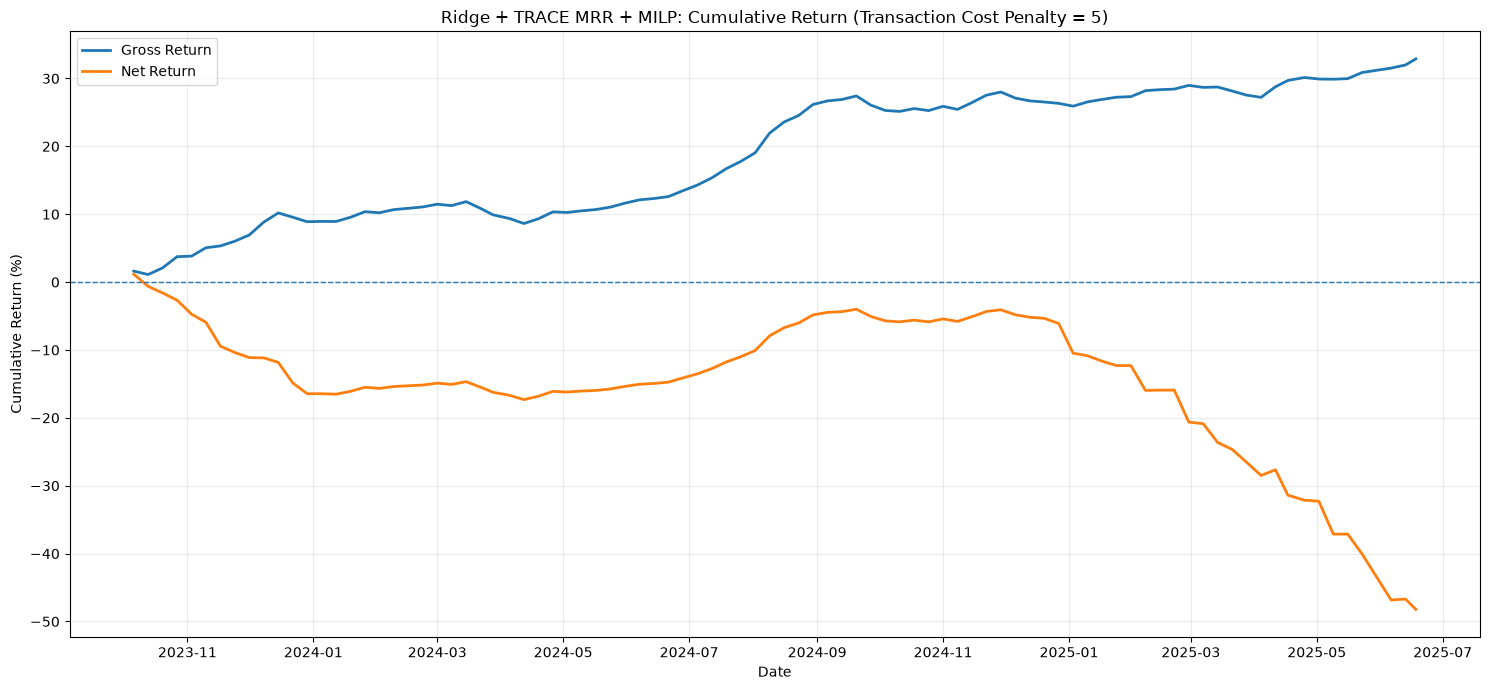

Final Gross Return: 32.89%
Final Net Return: -48.22%
Average Turnover: 31.88%
Total Transaction Cost: 92.36%
Average Tickets: 44.29


In [52]:
from dataclasses import replace
import time
import pandas as pd
import numpy as np


# ============================================================
# 1. TEST POLICY
# ============================================================

# Temporary test policy because sector / rating metadata
# were incomplete in the current dataset.
#
# Initial portfolio may use up to 75 tickets.
# Normal adaptive rebalance starts at 30 tickets.

RIDGE_TEST_POLICY = replace(
    POLICY,
    max_sector_weight=1.00,
    min_ig_weight=0.00,
    max_hy_weight=1.00,
    max_holdings=75,
    max_tickets=30,
)


# ============================================================
# 2. STRONGER TRANSACTION COST PENALTY
# ============================================================

LAMBDA_COST_5 = replace(
    LAMBDA,
    transaction_cost=5.0,
)

print("Policy:")
print(RIDGE_TEST_POLICY)

print("\nPenalties:")
print(LAMBDA_COST_5)


# ============================================================
# 3. ADVANCED MILP BACKTEST
# ============================================================

def run_model_milp_backtest_efficient(
    predictions,
    policy=POLICY,
    penalties=LAMBDA,
    frequency="W-FRI",
    candidate_limit=500,
    retry_candidate_limit=900,
    verbose=True,
):

    holdings_rows = []
    diagnostic_rows = []

    # ========================================================
    # Run model-by-model
    # ========================================================

    for model_name, model_df in predictions.groupby("model"):

        model_df = (
            model_df
            .sort_values("date")
            .copy()
        )

        rebalance_dates = select_rebalance_dates(
            model_df["date"],
            frequency,
        )

        # ----------------------------------------------------
        # Portfolio starts empty
        #
        # IMPORTANT:
        # current_weights exists INSIDE the function.
        # ----------------------------------------------------

        current_weights = pd.Series(dtype=float)

        n_dates = len(rebalance_dates)

        model_start = time.time()

        # ====================================================
        # Rebalance loop
        # ====================================================

        for rebalance_number, dt in enumerate(
            rebalance_dates,
            start=1,
        ):

            solve_start = time.time()

            # ------------------------------------------------
            # Current rebalance universe
            # ------------------------------------------------

            full_day = model_df[
                model_df["date"] == dt
            ].copy()

            full_day = full_day.dropna(
                subset=[
                    "mu_hat",
                    "target_weight",
                    "dynamic_weight_cap",
                ]
            )

            if full_day.empty:
                continue

            # ------------------------------------------------
            # Candidate pre-selection
            # ------------------------------------------------

            day = preselect_milp_candidates(
                full_day,
                current_weights=current_weights,
                max_candidates=candidate_limit,
            )

            # =================================================
            # INITIAL PORTFOLIO CHECK
            # =================================================

            is_initial_build = (
                current_weights.empty
                or current_weights.sum() < 1e-8
            )

            # =================================================
            # ADAPTIVE TICKET LIMIT
            # =================================================

            if is_initial_build:

                # Need enough trades to construct
                # the initial portfolio.
                ticket_limits_to_try = [
                    policy.max_holdings
                ]

            else:

                # Start restrictive.
                # Relax only if MILP is infeasible.

                base_tickets = policy.max_tickets
                max_tickets = policy.max_holdings

                ticket_limits_to_try = [
                    base_tickets,                     # 30
                    int(np.ceil(base_tickets * 1.5)), # 45
                    int(np.ceil(base_tickets * 2.0)), # 60
                    max_tickets,                      # 75
                ]

                # Do not exceed max holdings
                ticket_limits_to_try = [
                    min(x, max_tickets)
                    for x in ticket_limits_to_try
                ]

                # Remove duplicates
                ticket_limits_to_try = list(
                    dict.fromkeys(
                        ticket_limits_to_try
                    )
                )

            # =================================================
            # FIRST MILP ATTEMPT
            # =================================================

            result = None
            solve_policy = None
            ticket_limit_used = None
            ticket_limits_tested = []

            for ticket_limit in ticket_limits_to_try:

                ticket_limits_tested.append(
                    ticket_limit
                )

                solve_policy = replace(
                    policy,
                    max_tickets=int(ticket_limit),
                )

                result = solve_full_corporate_bond_milp(
                    day,
                    current_weights=current_weights,
                    policy=solve_policy,
                    penalties=penalties,
                )

                # Smallest feasible ticket limit wins
                if result.success:

                    ticket_limit_used = int(
                        ticket_limit
                    )

                    break

            # =================================================
            # RETRY WITH LARGER CANDIDATE UNIVERSE
            # =================================================

            retried = False

            if (
                not result.success
                and len(full_day) > len(day)
            ):

                retried = True

                day = preselect_milp_candidates(
                    full_day,
                    current_weights=current_weights,
                    max_candidates=retry_candidate_limit,
                    min_ig_candidates=250,
                    min_hy_candidates=100,
                    per_sector=15,
                )

                # Try the ticket ladder again
                for ticket_limit in ticket_limits_to_try:

                    ticket_limits_tested.append(
                        ticket_limit
                    )

                    solve_policy = replace(
                        policy,
                        max_tickets=int(ticket_limit),
                    )

                    result = solve_full_corporate_bond_milp(
                        day,
                        current_weights=current_weights,
                        policy=solve_policy,
                        penalties=penalties,
                    )

                    if result.success:

                        ticket_limit_used = int(
                            ticket_limit
                        )

                        break

            # ------------------------------------------------
            # If every ticket limit failed
            # ------------------------------------------------

            if ticket_limit_used is None:

                ticket_limit_used = int(
                    ticket_limits_to_try[-1]
                )

            solve_seconds = (
                time.time()
                - solve_start
            )

            # =================================================
            # DIAGNOSTICS
            # =================================================

            diagnostic_rows.append(
                {
                    "model":
                        model_name,

                    "date":
                        dt,

                    "success":
                        result.success,

                    "status":
                        result.status,

                    "message":
                        result.message,

                    "objective":
                        result.objective,

                    "initial_build":
                        is_initial_build,

                    "ticket_limit_used":
                        ticket_limit_used,

                    "ticket_limits_tested":
                        ticket_limits_tested,

                    "n_full_universe":
                        len(full_day),

                    "n_candidates":
                        len(day),

                    "retried":
                        retried,

                    "solve_seconds":
                        solve_seconds,

                    **result.diagnostics,
                }
            )

            # =================================================
            # PRINT PROGRESS
            # =================================================

            if verbose:

                print(
                    f"[{model_name}] "
                    f"{pd.Timestamp(dt).date()} | "
                    f"{rebalance_number}/{n_dates} | "
                    f"candidates={len(day):,} | "
                    f"tickets_tested={ticket_limits_tested} | "
                    f"ticket_used={ticket_limit_used} | "
                    f"initial={is_initial_build} | "
                    f"success={result.success} | "
                    f"solve={solve_seconds:.2f}s"
                )

            # ------------------------------------------------
            # If solve failed:
            # keep old portfolio and move to next date
            # ------------------------------------------------

            if not result.success:
                continue

            # =================================================
            # PREPARE SUCCESSFUL PORTFOLIO
            # =================================================

            day_indexed = (
                day
                .drop_duplicates("cusip")
                .set_index("cusip")
            )

            # ------------------------------------------------
            # Realized forward return
            # ------------------------------------------------

            next_return = (
                day_indexed[TARGET_COL]
                .reindex(
                    result.weights.index
                )
            )

            # =================================================
            # TRANSACTION COST RATE
            # =================================================

            cost_rate = pd.to_numeric(
                first_existing(
                    day_indexed,
                    [
                        "L_BCQ_pct",
                        "L_AXOR_pct",
                    ],
                    np.nan,
                ),
                errors="coerce",
            ).reindex(
                result.weights.index
            )

            fallback_cost = (
                cost_rate.median()
                if cost_rate.notna().any()
                else 0.005
            )

            cost_rate = (
                cost_rate
                .fillna(fallback_cost)
                .clip(lower=0)
            )

            # =================================================
            # KEEP:
            #
            # 1. Current holdings
            # 2. Bonds traded completely to zero
            #
            # This ensures sell transaction costs
            # are not lost.
            # =================================================

            relevant_cusips = set(
                result.weights[
                    result.weights > 1e-10
                ].index
            )

            relevant_cusips.update(
                result.traded[
                    result.traded
                ].index
            )

            # =================================================
            # STORE HOLDINGS / TRADES
            # =================================================

            for cusip in relevant_cusips:

                # --------------------------------------------
                # Safe metadata access
                # --------------------------------------------

                target_weight_value = (
                    day_indexed[
                        "target_weight"
                    ].get(
                        cusip,
                        np.nan,
                    )
                )

                mu_value = (
                    day_indexed[
                        "mu_hat"
                    ].get(
                        cusip,
                        np.nan,
                    )
                )

                dynamic_cap_value = (
                    day_indexed[
                        "dynamic_weight_cap"
                    ].get(
                        cusip,
                        np.nan,
                    )
                )

                if "L_TRACE_MRR_pct" in day_indexed.columns:

                    mrr_value = (
                        day_indexed[
                            "L_TRACE_MRR_pct"
                        ].get(
                            cusip,
                            np.nan,
                        )
                    )

                else:

                    mrr_value = np.nan

                # --------------------------------------------
                # Append row
                # --------------------------------------------

                holdings_rows.append(
                    {
                        "model":
                            model_name,

                        "date":
                            dt,

                        "cusip":
                            cusip,

                        "weight":
                            float(
                                result.weights.get(
                                    cusip,
                                    0.0,
                                )
                            ),

                        "target_weight":
                            float(
                                target_weight_value
                            ),

                        "mu_hat":
                            float(
                                mu_value
                            ),

                        "realized_forward_return":
                            float(
                                next_return.get(
                                    cusip,
                                    np.nan,
                                )
                            ),

                        "buy":
                            float(
                                result.buys.get(
                                    cusip,
                                    0.0,
                                )
                            ),

                        "sell":
                            float(
                                result.sells.get(
                                    cusip,
                                    0.0,
                                )
                            ),

                        "ticket":
                            bool(
                                result.traded.get(
                                    cusip,
                                    False,
                                )
                            ),

                        "cost_rate":
                            float(
                                cost_rate.get(
                                    cusip,
                                    fallback_cost,
                                )
                            ),

                        "mrr":
                            float(
                                mrr_value
                            ),

                        "dynamic_weight_cap":
                            float(
                                dynamic_cap_value
                            ),
                    }
                )

            # =================================================
            # CRITICAL:
            # Carry successful portfolio into next week
            # =================================================

            current_weights = (
                result.weights[
                    result.weights > 1e-10
                ]
                .copy()
            )

        # ====================================================
        # MODEL COMPLETED
        # ====================================================

        print()

        print(
            f"{model_name} completed in "
            f"{(time.time() - model_start) / 60:.2f} minutes"
        )

        print()

    # ========================================================
    # OUTPUT
    # ========================================================

    holdings_df = pd.DataFrame(
        holdings_rows
    )

    diagnostics_df = pd.DataFrame(
        diagnostic_rows
    )

    return (
        holdings_df,
        diagnostics_df,
    )


# ============================================================
# 4. RUN RIDGE + MRR + MILP WITH COST PENALTY = 5
# ============================================================

ridge_holdings_cost5, ridge_diagnostics_cost5 = (
    run_model_milp_backtest_efficient(
        ridge_predictions,
        policy=RIDGE_TEST_POLICY,
        penalties=LAMBDA_COST_5,
        frequency=MODEL_CONFIG.rebalance_frequency,
        candidate_limit=500,
        retry_candidate_limit=900,
        verbose=True,
    )
)


# ============================================================
# 5. CHECK SOLVER RESULTS
# ============================================================

print("\nSUCCESS COUNTS")
print(
    ridge_diagnostics_cost5[
        "success"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nSuccess rate:",
    f"{ridge_diagnostics_cost5['success'].mean():.2%}"
)

print(
    "\nHoldings/trade rows:",
    len(ridge_holdings_cost5)
)


# ============================================================
# 6. SHOW FIRST 20 REBALANCES
# ============================================================

diagnostic_columns = [
    "date",
    "success",
    "initial_build",
    "ticket_limit_used",
    "ticket_limits_tested",
    "n_held",
    "n_tickets",
    "turnover",
    "solve_seconds",
]

diagnostic_columns = [
    c
    for c in diagnostic_columns
    if c in ridge_diagnostics_cost5.columns
]

display(
    ridge_diagnostics_cost5[
        diagnostic_columns
    ].head(20)
)


# ============================================================
# 7. CALCULATE RETURNS
# ============================================================

ridge_returns_cost5, ridge_summary_cost5 = (
    portfolio_returns_from_holdings(
        ridge_holdings_cost5,
        annualization=52,
    )
)

print("\nPERFORMANCE SUMMARY")

display(
    ridge_summary_cost5.T
)


# ============================================================
# 8. CUMULATIVE GROSS / NET RETURN
# ============================================================

ridge_plot_cost5 = (
    ridge_returns_cost5
    .sort_values("date")
    .copy()
)

ridge_plot_cost5[
    "cumulative_gross_return"
] = (
    1
    + ridge_plot_cost5[
        "gross_return"
    ].fillna(0)
).cumprod() - 1


ridge_plot_cost5[
    "cumulative_net_return"
] = (
    1
    + ridge_plot_cost5[
        "net_return"
    ].fillna(0)
).cumprod() - 1


# ============================================================
# 9. PLOT
# ============================================================

import matplotlib.pyplot as plt

plt.figure(
    figsize=(15, 7)
)

plt.plot(
    ridge_plot_cost5["date"],
    ridge_plot_cost5[
        "cumulative_gross_return"
    ] * 100,
    label="Gross Return",
    linewidth=2,
)

plt.plot(
    ridge_plot_cost5["date"],
    ridge_plot_cost5[
        "cumulative_net_return"
    ] * 100,
    label="Net Return",
    linewidth=2,
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Ridge + TRACE MRR + MILP: "
    "Cumulative Return "
    "(Transaction Cost Penalty = 5)"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Cumulative Return (%)"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. FINAL NUMBERS
# ============================================================

print(
    "Final Gross Return:",
    f"{ridge_plot_cost5['cumulative_gross_return'].iloc[-1]:.2%}"
)

print(
    "Final Net Return:",
    f"{ridge_plot_cost5['cumulative_net_return'].iloc[-1]:.2%}"
)

print(
    "Average Turnover:",
    f"{ridge_returns_cost5['turnover'].mean():.2%}"
)

print(
    "Total Transaction Cost:",
    f"{ridge_returns_cost5['transaction_cost'].sum():.2%}"
)

print(
    "Average Tickets:",
    f"{ridge_returns_cost5['n_tickets'].mean():.2f}"
)

In [53]:
# ============================================================
# DIAGNOSE WHY NET RETURN IS LOW
# ============================================================

print("===== TURNOVER =====")

print(
    "Average weekly turnover:",
    f"{ridge_returns_cost5['turnover'].mean():.2%}"
)

print(
    "Median weekly turnover:",
    f"{ridge_returns_cost5['turnover'].median():.2%}"
)

print(
    "Max weekly turnover:",
    f"{ridge_returns_cost5['turnover'].max():.2%}"
)


print("\n===== TRANSACTION COST =====")

print(
    "Average weekly transaction cost:",
    f"{ridge_returns_cost5['transaction_cost'].mean():.2%}"
)

print(
    "Median weekly transaction cost:",
    f"{ridge_returns_cost5['transaction_cost'].median():.2%}"
)

print(
    "Total transaction cost:",
    f"{ridge_returns_cost5['transaction_cost'].sum():.2%}"
)


print("\n===== COST RATE =====")

cost_stats = (
    ridge_holdings_cost5[
        "cost_rate"
    ]
    .dropna()
    .quantile(
        [
            0.00,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            1.00,
        ]
    )
)

display(
    pd.DataFrame(
        {
            "cost_rate": cost_stats,
            "cost_rate_bps": cost_stats * 10000,
        }
    )
)


print("\n===== TICKETS =====")

print(
    ridge_diagnostics_cost5[
        "ticket_limit_used"
    ]
    .value_counts()
    .sort_index()
)


print("\n===== WORST COST WEEKS =====")

display(
    ridge_returns_cost5[
        [
            "date",
            "gross_return",
            "transaction_cost",
            "net_return",
            "turnover",
            "n_tickets",
        ]
    ]
    .sort_values(
        "transaction_cost",
        ascending=False,
    )
    .head(15)
)


===== TURNOVER =====
Average weekly turnover: 31.88%
Median weekly turnover: 30.93%
Max weekly turnover: 100.00%

===== TRANSACTION COST =====
Average weekly transaction cost: 1.04%
Median weekly transaction cost: 0.06%
Total transaction cost: 92.36%

===== COST RATE =====


,cost_rate,cost_rate_bps
0.00,0.000000,0.000000
0.10,0.001844,18.436533
0.25,0.002545,25.448992
0.50,0.003288,32.879880
0.75,0.005411,54.108405
0.90,0.012678,126.782884
0.95,0.377811,3778.110078
0.99,2.000000,20000.000000
1.00,2.000000,20000.000000



===== TICKETS =====
ticket_limit_used
30    16
45    63
60     8
75     3
Name: count, dtype: int64

===== WORST COST WEEKS =====


,date,gross_return,transaction_cost,net_return,turnover,n_tickets
86,2025-06-06,0.004919,0.117545,-0.112625,0.685131,75
83,2025-05-09,-0.000227,0.071326,-0.071552,0.504728,60
73,2025-02-28,0.004265,0.060260,-0.055995,0.423268,45
80,2025-04-17,0.007220,0.058987,-0.051767,0.362594,45
85,2025-05-23,0.006965,0.054032,-0.047066,0.363263,60
70,2025-02-07,0.006879,0.048548,-0.041669,0.441809,60
65,2025-01-03,-0.003275,0.043363,-0.046639,0.447200,60
6,2023-11-17,0.002621,0.040024,-0.037402,0.195840,45
88,2025-06-18,0.006781,0.035426,-0.028645,0.386277,60
75,2025-03-14,0.000401,0.035363,-0.034962,0.402561,60


Winzorize transaction cost-rates. 

In [54]:
# ============================================================
# ADVANCED TRANSACTION-COST TAIL CONTROL
#
# Goal:
# 1. Preserve the original raw cost data
# 2. Diagnose the tail
# 3. Create economically interpretable cost caps
# 4. Compare 100 / 150 / 200 / 250 bps specifications
# 5. Recalculate net returns for each specification
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. START FROM ORIGINAL HOLDINGS
# ============================================================

ridge_cost_analysis = ridge_holdings_cost5.copy()

ridge_cost_analysis["cost_rate"] = pd.to_numeric(
    ridge_cost_analysis["cost_rate"],
    errors="coerce",
)

# No negative transaction costs
ridge_cost_analysis["cost_rate"] = (
    ridge_cost_analysis["cost_rate"]
    .clip(lower=0)
)


# ============================================================
# 2. DIAGNOSE ORIGINAL DISTRIBUTION
# ============================================================

qs = [
    0.50,
    0.75,
    0.80,
    0.85,
    0.90,
    0.91,
    0.92,
    0.93,
    0.94,
    0.95,
    0.96,
    0.97,
    0.98,
    0.99,
    1.00,
]

q = (
    ridge_cost_analysis["cost_rate"]
    .quantile(qs)
)

cost_distribution = pd.DataFrame(
    {
        "cost_rate": q,
        "cost_bps": q * 10000,
    }
)

print("===== RAW COST DISTRIBUTION =====")

display(cost_distribution)


# ============================================================
# 3. DEFINE ECONOMIC COST CAPS
# ============================================================
#
# Decimal equivalents:
#
# 100 bps = 0.010
# 150 bps = 0.015
# 200 bps = 0.020
# 250 bps = 0.025
#
# We will use 150 bps as the main test,
# but keep the others for sensitivity analysis.
# ============================================================

COST_CAPS = {
    "100bps": 0.010,
    "150bps": 0.015,
    "200bps": 0.020,
    "250bps": 0.025,
}


# ============================================================
# 4. CREATE WINSORIZED COST COLUMNS
# ============================================================

for label, cap in COST_CAPS.items():

    ridge_cost_analysis[
        f"cost_rate_{label}"
    ] = (
        ridge_cost_analysis["cost_rate"]
        .clip(
            lower=0,
            upper=cap,
        )
    )


# ============================================================
# 5. PRIMARY SPECIFICATION:
# 150 BPS UPPER CAP
# ============================================================

ridge_cost_analysis[
    "cost_rate_winsor"
] = (
    ridge_cost_analysis[
        "cost_rate_150bps"
    ]
)

print("\n===== PRIMARY COST CAP =====")

print(
    "Primary cap:",
    COST_CAPS["150bps"],
    "=",
    COST_CAPS["150bps"] * 10000,
    "bps"
)


# ============================================================
# 6. HOW MANY OBSERVATIONS ARE AFFECTED?
# ============================================================

tail_summary = []

n_total = len(ridge_cost_analysis)

for label, cap in COST_CAPS.items():

    n_above = (
        ridge_cost_analysis["cost_rate"]
        > cap
    ).sum()

    pct_above = (
        n_above / n_total
        if n_total > 0
        else np.nan
    )

    tail_summary.append(
        {
            "cap": label,
            "cap_decimal": cap,
            "cap_bps": cap * 10000,
            "observations_above_cap": n_above,
            "percent_above_cap": pct_above,
        }
    )

tail_summary = pd.DataFrame(
    tail_summary
)

print(
    "\n===== OBSERVATIONS AFFECTED ====="
)

display(tail_summary)


# ============================================================
# 7. COMPARE RAW VS 150-BPS COST DISTRIBUTION
# ============================================================

comparison = pd.DataFrame(
    {
        "raw_cost_bps":
            ridge_cost_analysis[
                "cost_rate"
            ] * 10000,

        "winsor_150bps":
            ridge_cost_analysis[
                "cost_rate_winsor"
            ] * 10000,
    }
)

print(
    "\n===== RAW VS 150-BPS CONTROLLED COST ====="
)

display(
    comparison.describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    ).T
)


# ============================================================
# 8. CREATE SEPARATE HOLDINGS DATASETS FOR EACH SCENARIO
# ============================================================
#
# portfolio_returns_from_holdings() expects the transaction
# cost variable to be called "cost_rate".
#
# Therefore, for each scenario we create a COPY and replace
# cost_rate only in that copy.
# ============================================================

ridge_holdings_raw = (
    ridge_cost_analysis.copy()
)


ridge_holdings_100bps = (
    ridge_cost_analysis.copy()
)

ridge_holdings_100bps["cost_rate"] = (
    ridge_holdings_100bps[
        "cost_rate_100bps"
    ]
)


ridge_holdings_150bps = (
    ridge_cost_analysis.copy()
)

ridge_holdings_150bps["cost_rate"] = (
    ridge_holdings_150bps[
        "cost_rate_150bps"
    ]
)


ridge_holdings_200bps = (
    ridge_cost_analysis.copy()
)

ridge_holdings_200bps["cost_rate"] = (
    ridge_holdings_200bps[
        "cost_rate_200bps"
    ]
)


ridge_holdings_250bps = (
    ridge_cost_analysis.copy()
)

ridge_holdings_250bps["cost_rate"] = (
    ridge_holdings_250bps[
        "cost_rate_250bps"
    ]
)


# ============================================================
# 9. RECALCULATE PORTFOLIO RETURNS
# ============================================================

returns_raw, summary_raw = (
    portfolio_returns_from_holdings(
        ridge_holdings_raw,
        annualization=52,
    )
)


returns_100, summary_100 = (
    portfolio_returns_from_holdings(
        ridge_holdings_100bps,
        annualization=52,
    )
)


returns_150, summary_150 = (
    portfolio_returns_from_holdings(
        ridge_holdings_150bps,
        annualization=52,
    )
)


returns_200, summary_200 = (
    portfolio_returns_from_holdings(
        ridge_holdings_200bps,
        annualization=52,
    )
)


returns_250, summary_250 = (
    portfolio_returns_from_holdings(
        ridge_holdings_250bps,
        annualization=52,
    )
)


# ============================================================
# 10. HELPER FUNCTION FOR PERFORMANCE STATISTICS
# ============================================================

def summarize_cost_scenario(
    name,
    returns_df,
):

    cumulative_gross = (
        (
            1
            + returns_df[
                "gross_return"
            ].fillna(0)
        ).prod()
        - 1
    )

    cumulative_net = (
        (
            1
            + returns_df[
                "net_return"
            ].fillna(0)
        ).prod()
        - 1
    )

    return {
        "scenario":
            name,

        "gross_return":
            cumulative_gross,

        "net_return":
            cumulative_net,

        "avg_turnover":
            returns_df[
                "turnover"
            ].mean(),

        "avg_weekly_cost":
            returns_df[
                "transaction_cost"
            ].mean(),

        "total_transaction_cost":
            returns_df[
                "transaction_cost"
            ].sum(),

        "avg_tickets":
            returns_df[
                "n_tickets"
            ].mean(),
    }


# ============================================================
# 11. BUILD SENSITIVITY TABLE
# ============================================================

cost_sensitivity = pd.DataFrame(
    [
        summarize_cost_scenario(
            "Raw",
            returns_raw,
        ),

        summarize_cost_scenario(
            "100 bps cap",
            returns_100,
        ),

        summarize_cost_scenario(
            "150 bps cap",
            returns_150,
        ),

        summarize_cost_scenario(
            "200 bps cap",
            returns_200,
        ),

        summarize_cost_scenario(
            "250 bps cap",
            returns_250,
        ),
    ]
)


# Convert to percentages for easier reading

percentage_columns = [
    "gross_return",
    "net_return",
    "avg_turnover",
    "avg_weekly_cost",
    "total_transaction_cost",
]

cost_sensitivity_display = (
    cost_sensitivity.copy()
)

for col in percentage_columns:

    cost_sensitivity_display[col] = (
        cost_sensitivity_display[col]
        * 100
    )


print(
    "\n===== TRANSACTION COST SENSITIVITY ====="
)

display(
    cost_sensitivity_display.round(3)
)


# ============================================================
# 12. SAVE PRIMARY 150-BPS RESULT
#
# Use these variables for the next return graph.
# ============================================================

ridge_holdings_cost5_controlled = (
    ridge_holdings_150bps.copy()
)

ridge_returns_cost5_controlled = (
    returns_150.copy()
)

ridge_summary_cost5_controlled = (
    summary_150.copy()
)


print(
    "\nPrimary controlled specification created:"
)

print(
    "ridge_holdings_cost5_controlled"
)

print(
    "ridge_returns_cost5_controlled"
)

===== RAW COST DISTRIBUTION =====


,cost_rate,cost_bps
0.50,0.003288,32.879880
0.75,0.005411,54.108405
0.80,0.007184,71.836610
0.85,0.008906,89.063997
0.90,0.012678,126.782884
0.91,0.016514,165.144564
0.92,0.023530,235.302028
0.93,0.039852,398.519869
0.94,0.124270,1242.698334
0.95,0.377811,3778.110078



===== PRIMARY COST CAP =====
Primary cap: 0.015 = 150.0 bps

===== OBSERVATIONS AFFECTED =====


,cap,cap_decimal,cap_bps,observations_above_cap,percent_above_cap
0,100bps,0.010,100.0,925,0.134448
1,150bps,0.015,150.0,642,0.093314
2,200bps,0.020,200.0,585,0.085029
3,250bps,0.025,250.0,541,0.078634



===== RAW VS 150-BPS CONTROLLED COST =====


,count,mean,std,min,50%,75%,90%,95%,99%,max
raw_cost_bps,6880.0,730.57007,3131.917595,0.0,32.87988,54.108405,126.782884,3778.110078,20000.0,20000.0
winsor_150bps,6880.0,49.91498,40.004211,0.0,32.87988,54.108405,126.782884,150.000000,150.0,150.0



===== TRANSACTION COST SENSITIVITY =====


,scenario,gross_return,net_return,avg_turnover,avg_weekly_cost,total_transaction_cost,avg_tickets
0,Raw,32.888,-48.223,31.88,1.038,92.356,44.292
1,100 bps cap,32.888,24.102,31.88,0.077,6.860,44.292
2,150 bps cap,32.888,23.149,31.88,0.086,7.633,44.292
3,200 bps cap,32.888,22.384,31.88,0.093,8.258,44.292
4,250 bps cap,32.888,21.696,31.88,0.099,8.823,44.292



Primary controlled specification created:
ridge_holdings_cost5_controlled
ridge_returns_cost5_controlled


Controlled

In [55]:
# ============================================================
# ADVANCED TRANSACTION-COST TAIL CONTROL
#
# Goal:
# 1. Preserve the original raw cost data
# 2. Diagnose the tail
# 3. Create economically interpretable cost caps
# 4. Compare 100 / 150 / 200 / 250 bps specifications
# 5. Recalculate net returns for each specification
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. START FROM ORIGINAL HOLDINGS
# ============================================================

ridge_cost_analysis = ridge_holdings_cost5.copy()

ridge_cost_analysis["cost_rate"] = pd.to_numeric(
    ridge_cost_analysis["cost_rate"],
    errors="coerce",
)

# No negative transaction costs
ridge_cost_analysis["cost_rate"] = (
    ridge_cost_analysis["cost_rate"]
    .clip(lower=0)
)


# ============================================================
# 2. DIAGNOSE ORIGINAL DISTRIBUTION
# ============================================================

qs = [
    0.50,
    0.75,
    0.80,
    0.85,
    0.90,
    0.91,
    0.92,
    0.93,
    0.94,
    0.95,
    0.96,
    0.97,
    0.98,
    0.99,
    1.00,
]

q = (
    ridge_cost_analysis["cost_rate"]
    .quantile(qs)
)

cost_distribution = pd.DataFrame(
    {
        "cost_rate": q,
        "cost_bps": q * 10000,
    }
)

print("===== RAW COST DISTRIBUTION =====")

display(cost_distribution)


# ============================================================
# 3. DEFINE ECONOMIC COST CAPS
# ============================================================
#
# Decimal equivalents:
#
# 100 bps = 0.010
# 150 bps = 0.015
# 200 bps = 0.020
# 250 bps = 0.025
#
# We will use 150 bps as the main test,
# but keep the others for sensitivity analysis.
# ============================================================

COST_CAPS = {
    "100bps": 0.010,
    "150bps": 0.015,
    "200bps": 0.020,
    "250bps": 0.025,
}


# ============================================================
# 4. CREATE WINSORIZED COST COLUMNS
# ============================================================

for label, cap in COST_CAPS.items():

    ridge_cost_analysis[
        f"cost_rate_{label}"
    ] = (
        ridge_cost_analysis["cost_rate"]
        .clip(
            lower=0,
            upper=cap,
        )
    )


# ============================================================
# 5. PRIMARY SPECIFICATION:
# 150 BPS UPPER CAP
# ============================================================

ridge_cost_analysis[
    "cost_rate_winsor"
] = (
    ridge_cost_analysis[
        "cost_rate_150bps"
    ]
)

print("\n===== PRIMARY COST CAP =====")

print(
    "Primary cap:",
    COST_CAPS["150bps"],
    "=",
    COST_CAPS["150bps"] * 10000,
    "bps"
)


# ============================================================
# 6. HOW MANY OBSERVATIONS ARE AFFECTED?
# ============================================================

tail_summary = []

n_total = len(ridge_cost_analysis)

for label, cap in COST_CAPS.items():

    n_above = (
        ridge_cost_analysis["cost_rate"]
        > cap
    ).sum()

    pct_above = (
        n_above / n_total
        if n_total > 0
        else np.nan
    )

    tail_summary.append(
        {
            "cap": label,
            "cap_decimal": cap,
            "cap_bps": cap * 10000,
            "observations_above_cap": n_above,
            "percent_above_cap": pct_above,
        }
    )

tail_summary = pd.DataFrame(
    tail_summary
)

print(
    "\n===== OBSERVATIONS AFFECTED ====="
)

display(tail_summary)


# ============================================================
# 7. COMPARE RAW VS 150-BPS COST DISTRIBUTION
# ============================================================

comparison = pd.DataFrame(
    {
        "raw_cost_bps":
            ridge_cost_analysis[
                "cost_rate"
            ] * 10000,

        "winsor_150bps":
            ridge_cost_analysis[
                "cost_rate_winsor"
            ] * 10000,
    }
)

print(
    "\n===== RAW VS 150-BPS CONTROLLED COST ====="
)

display(
    comparison.describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    ).T
)


# ============================================================
# 8. CREATE SEPARATE HOLDINGS DATASETS FOR EACH SCENARIO
# ============================================================
#
# portfolio_returns_from_holdings() expects the transaction
# cost variable to be called "cost_rate".
#
# Therefore, for each scenario we create a COPY and replace
# cost_rate only in that copy.
# ============================================================

ridge_holdings_raw = (
    ridge_cost_analysis.copy()
)


ridge_holdings_100bps = (
    ridge_cost_analysis.copy()
)

ridge_holdings_100bps["cost_rate"] = (
    ridge_holdings_100bps[
        "cost_rate_100bps"
    ]
)


ridge_holdings_150bps = (
    ridge_cost_analysis.copy()
)

ridge_holdings_150bps["cost_rate"] = (
    ridge_holdings_150bps[
        "cost_rate_150bps"
    ]
)


ridge_holdings_200bps = (
    ridge_cost_analysis.copy()
)

ridge_holdings_200bps["cost_rate"] = (
    ridge_holdings_200bps[
        "cost_rate_200bps"
    ]
)


ridge_holdings_250bps = (
    ridge_cost_analysis.copy()
)

ridge_holdings_250bps["cost_rate"] = (
    ridge_holdings_250bps[
        "cost_rate_250bps"
    ]
)


# ============================================================
# 9. RECALCULATE PORTFOLIO RETURNS
# ============================================================

returns_raw, summary_raw = (
    portfolio_returns_from_holdings(
        ridge_holdings_raw,
        annualization=52,
    )
)


returns_100, summary_100 = (
    portfolio_returns_from_holdings(
        ridge_holdings_100bps,
        annualization=52,
    )
)


returns_150, summary_150 = (
    portfolio_returns_from_holdings(
        ridge_holdings_150bps,
        annualization=52,
    )
)


returns_200, summary_200 = (
    portfolio_returns_from_holdings(
        ridge_holdings_200bps,
        annualization=52,
    )
)


returns_250, summary_250 = (
    portfolio_returns_from_holdings(
        ridge_holdings_250bps,
        annualization=52,
    )
)


# ============================================================
# 10. HELPER FUNCTION FOR PERFORMANCE STATISTICS
# ============================================================

def summarize_cost_scenario(
    name,
    returns_df,
):

    cumulative_gross = (
        (
            1
            + returns_df[
                "gross_return"
            ].fillna(0)
        ).prod()
        - 1
    )

    cumulative_net = (
        (
            1
            + returns_df[
                "net_return"
            ].fillna(0)
        ).prod()
        - 1
    )

    return {
        "scenario":
            name,

        "gross_return":
            cumulative_gross,

        "net_return":
            cumulative_net,

        "avg_turnover":
            returns_df[
                "turnover"
            ].mean(),

        "avg_weekly_cost":
            returns_df[
                "transaction_cost"
            ].mean(),

        "total_transaction_cost":
            returns_df[
                "transaction_cost"
            ].sum(),

        "avg_tickets":
            returns_df[
                "n_tickets"
            ].mean(),
    }


# ============================================================
# 11. BUILD SENSITIVITY TABLE
# ============================================================

cost_sensitivity = pd.DataFrame(
    [
        summarize_cost_scenario(
            "Raw",
            returns_raw,
        ),

        summarize_cost_scenario(
            "100 bps cap",
            returns_100,
        ),

        summarize_cost_scenario(
            "150 bps cap",
            returns_150,
        ),

        summarize_cost_scenario(
            "200 bps cap",
            returns_200,
        ),

        summarize_cost_scenario(
            "250 bps cap",
            returns_250,
        ),
    ]
)


# Convert to percentages for easier reading

percentage_columns = [
    "gross_return",
    "net_return",
    "avg_turnover",
    "avg_weekly_cost",
    "total_transaction_cost",
]

cost_sensitivity_display = (
    cost_sensitivity.copy()
)

for col in percentage_columns:

    cost_sensitivity_display[col] = (
        cost_sensitivity_display[col]
        * 100
    )


print(
    "\n===== TRANSACTION COST SENSITIVITY ====="
)

display(
    cost_sensitivity_display.round(3)
)


# ============================================================
# 12. SAVE PRIMARY 150-BPS RESULT
#
# Use these variables for the next return graph.
# ============================================================

ridge_holdings_cost5_controlled = (
    ridge_holdings_150bps.copy()
)

ridge_returns_cost5_controlled = (
    returns_150.copy()
)

ridge_summary_cost5_controlled = (
    summary_150.copy()
)


print(
    "\nPrimary controlled specification created:"
)

print(
    "ridge_holdings_cost5_controlled"
)

print(
    "ridge_returns_cost5_controlled"
)

===== RAW COST DISTRIBUTION =====


,cost_rate,cost_bps
0.50,0.003288,32.879880
0.75,0.005411,54.108405
0.80,0.007184,71.836610
0.85,0.008906,89.063997
0.90,0.012678,126.782884
0.91,0.016514,165.144564
0.92,0.023530,235.302028
0.93,0.039852,398.519869
0.94,0.124270,1242.698334
0.95,0.377811,3778.110078



===== PRIMARY COST CAP =====
Primary cap: 0.015 = 150.0 bps

===== OBSERVATIONS AFFECTED =====


,cap,cap_decimal,cap_bps,observations_above_cap,percent_above_cap
0,100bps,0.010,100.0,925,0.134448
1,150bps,0.015,150.0,642,0.093314
2,200bps,0.020,200.0,585,0.085029
3,250bps,0.025,250.0,541,0.078634



===== RAW VS 150-BPS CONTROLLED COST =====


,count,mean,std,min,50%,75%,90%,95%,99%,max
raw_cost_bps,6880.0,730.57007,3131.917595,0.0,32.87988,54.108405,126.782884,3778.110078,20000.0,20000.0
winsor_150bps,6880.0,49.91498,40.004211,0.0,32.87988,54.108405,126.782884,150.000000,150.0,150.0



===== TRANSACTION COST SENSITIVITY =====


,scenario,gross_return,net_return,avg_turnover,avg_weekly_cost,total_transaction_cost,avg_tickets
0,Raw,32.888,-48.223,31.88,1.038,92.356,44.292
1,100 bps cap,32.888,24.102,31.88,0.077,6.860,44.292
2,150 bps cap,32.888,23.149,31.88,0.086,7.633,44.292
3,200 bps cap,32.888,22.384,31.88,0.093,8.258,44.292
4,250 bps cap,32.888,21.696,31.88,0.099,8.823,44.292



Primary controlled specification created:
ridge_holdings_cost5_controlled
ridge_returns_cost5_controlled


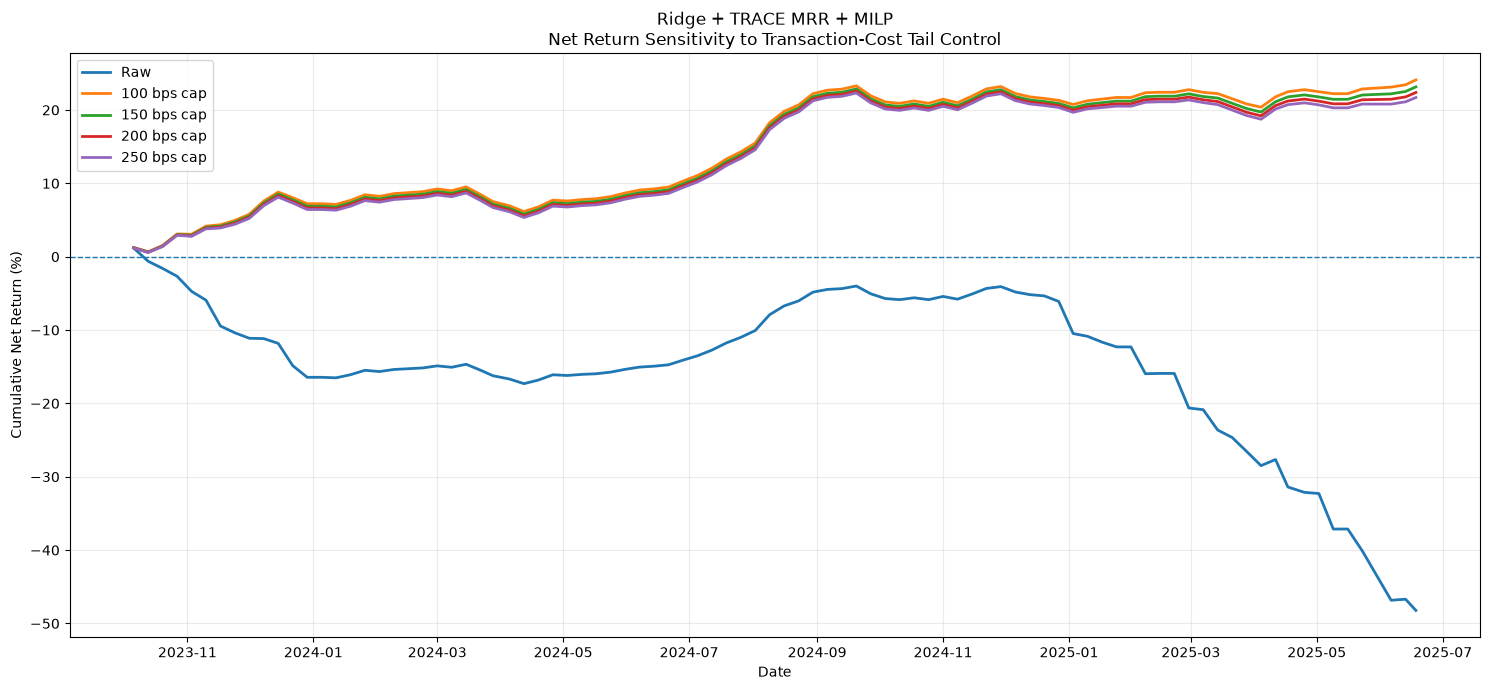

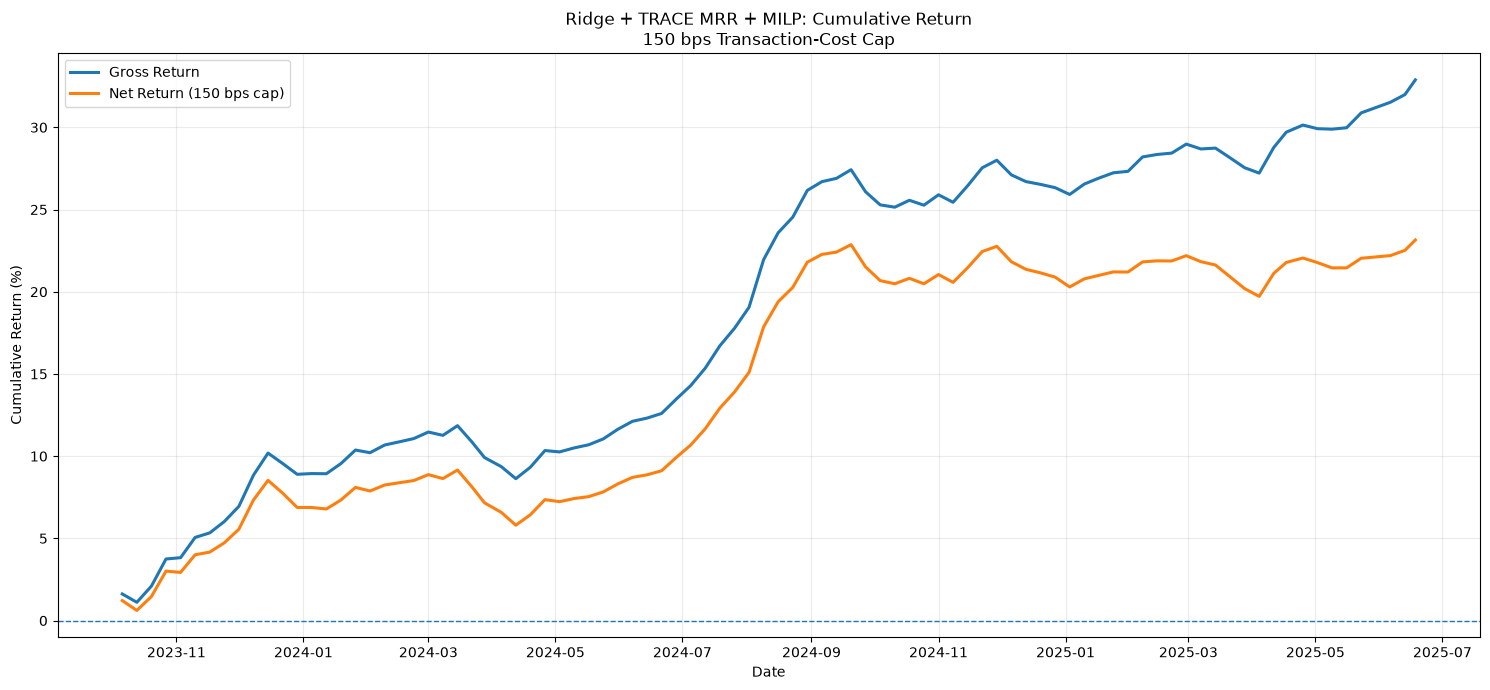

===== COST CAP PERFORMANCE COMPARISON =====


,Scenario,Final Gross Return,Final Net Return,Average Turnover,Average Weekly Cost,Total Transaction Cost
0,Raw,32.89%,-48.22%,31.88%,1.04%,92.36%
1,100 bps cap,32.89%,24.10%,31.88%,0.08%,6.86%
2,150 bps cap,32.89%,23.15%,31.88%,0.09%,7.63%
3,200 bps cap,32.89%,22.38%,31.88%,0.09%,8.26%
4,250 bps cap,32.89%,21.70%,31.88%,0.10%,8.82%



===== PRIMARY 150 BPS RESULT =====
Gross Return: 32.89%
Net Return: 23.15%
Average Turnover: 31.88%
Average Weekly Transaction Cost: 0.09%
Total Transaction Cost: 7.63%


In [56]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PREPARE CUMULATIVE RETURN SERIES
# ============================================================

scenario_returns = {
    "Raw": returns_raw,
    "100 bps cap": returns_100,
    "150 bps cap": returns_150,
    "200 bps cap": returns_200,
    "250 bps cap": returns_250,
}


plot_data = {}

for name, df in scenario_returns.items():

    temp = (
        df
        .sort_values("date")
        .copy()
    )

    temp["cumulative_gross_return"] = (
        1
        + temp["gross_return"].fillna(0)
    ).cumprod() - 1

    temp["cumulative_net_return"] = (
        1
        + temp["net_return"].fillna(0)
    ).cumprod() - 1

    plot_data[name] = temp


# ============================================================
# 2. GRAPH:
# RAW VS COST-CONTROLLED NET RETURNS
# ============================================================

plt.figure(figsize=(15, 7))

for name, temp in plot_data.items():

    plt.plot(
        temp["date"],
        temp["cumulative_net_return"] * 100,
        label=name,
        linewidth=2,
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Ridge + TRACE MRR + MILP\n"
    "Net Return Sensitivity to Transaction-Cost Tail Control"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Net Return (%)")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()


# ============================================================
# 3. PRIMARY 150-BPS SPECIFICATION:
# GROSS VS NET RETURN
# ============================================================

primary_plot = plot_data[
    "150 bps cap"
].copy()


plt.figure(figsize=(15, 7))

plt.plot(
    primary_plot["date"],
    primary_plot["cumulative_gross_return"] * 100,
    label="Gross Return",
    linewidth=2.2,
)

plt.plot(
    primary_plot["date"],
    primary_plot["cumulative_net_return"] * 100,
    label="Net Return (150 bps cap)",
    linewidth=2.2,
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Ridge + TRACE MRR + MILP: Cumulative Return\n"
    "150 bps Transaction-Cost Cap"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()


# ============================================================
# 4. FINAL PERFORMANCE COMPARISON
# ============================================================

comparison_rows = []

for name, temp in plot_data.items():

    final_gross = (
        temp["cumulative_gross_return"]
        .iloc[-1]
    )

    final_net = (
        temp["cumulative_net_return"]
        .iloc[-1]
    )

    avg_turnover = (
        temp["turnover"].mean()
    )

    avg_cost = (
        temp["transaction_cost"].mean()
    )

    total_cost = (
        temp["transaction_cost"].sum()
    )

    comparison_rows.append(
        {
            "Scenario": name,

            "Final Gross Return":
                final_gross,

            "Final Net Return":
                final_net,

            "Average Turnover":
                avg_turnover,

            "Average Weekly Cost":
                avg_cost,

            "Total Transaction Cost":
                total_cost,
        }
    )


performance_comparison = pd.DataFrame(
    comparison_rows
)


# ============================================================
# 5. FORMAT AS 
# ============================================================

display_table = (
    performance_comparison.copy()
)

pct_cols = [
    "Final Gross Return",
    "Final Net Return",
    "Average Turnover",
    "Average Weekly Cost",
    "Total Transaction Cost",
]

for col in pct_cols:

    display_table[col] = (
        display_table[col]
        .map(lambda x: f"{x:.2%}")
    )


print(
    "===== COST CAP PERFORMANCE COMPARISON ====="
)

display(display_table)


# ============================================================
# 6. PRINT PRIMARY RESULT
# ============================================================

print("\n===== PRIMARY 150 BPS RESULT =====")

print(
    "Gross Return:",
    f"{primary_plot['cumulative_gross_return'].iloc[-1]:.2%}"
)

print(
    "Net Return:",
    f"{primary_plot['cumulative_net_return'].iloc[-1]:.2%}"
)

print(
    "Average Turnover:",
    f"{returns_150['turnover'].mean():.2%}"
)

print(
    "Average Weekly Transaction Cost:",
    f"{returns_150['transaction_cost'].mean():.2%}"
)

print(
    "Total Transaction Cost:",
    f"{returns_150['transaction_cost'].sum():.2%}"
)

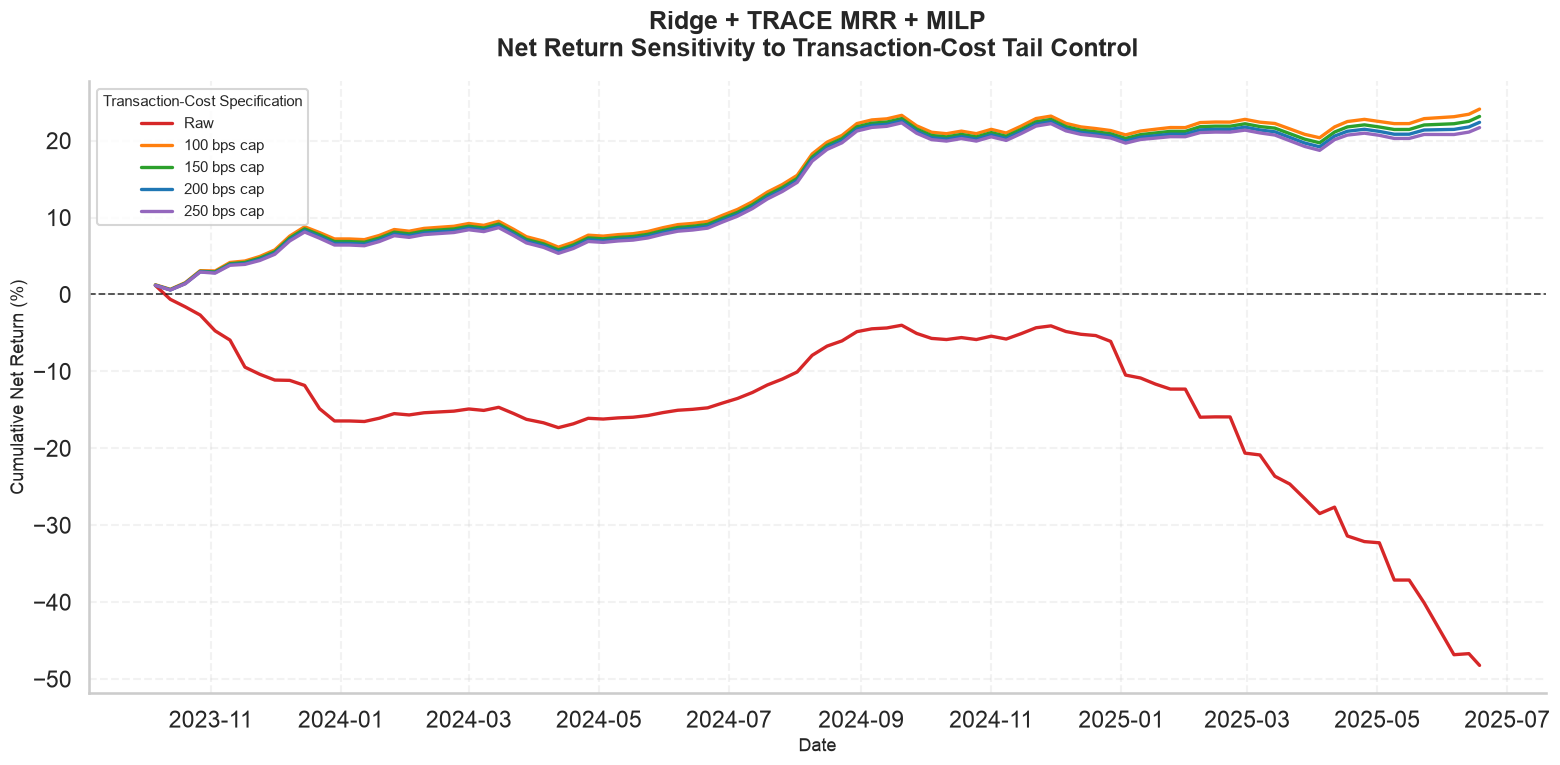

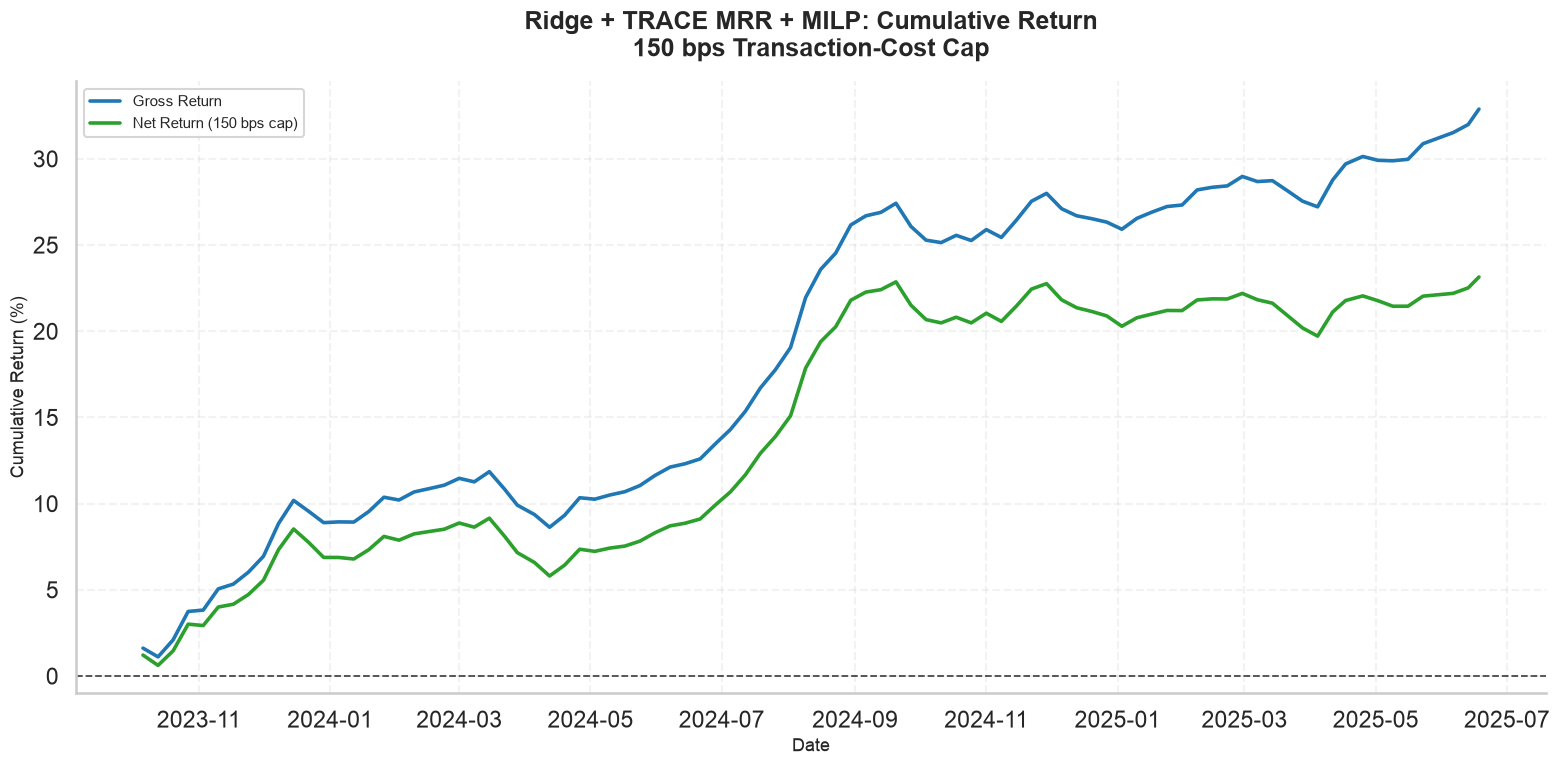

===== COST CAP PERFORMANCE COMPARISON =====


,Scenario,Final Gross Return,Final Net Return,Average Turnover,Average Weekly Cost,Total Transaction Cost
0,Raw,32.89%,-48.22%,31.88%,1.04%,92.36%
1,100 bps cap,32.89%,24.10%,31.88%,0.08%,6.86%
2,150 bps cap,32.89%,23.15%,31.88%,0.09%,7.63%
3,200 bps cap,32.89%,22.38%,31.88%,0.09%,8.26%
4,250 bps cap,32.89%,21.70%,31.88%,0.10%,8.82%


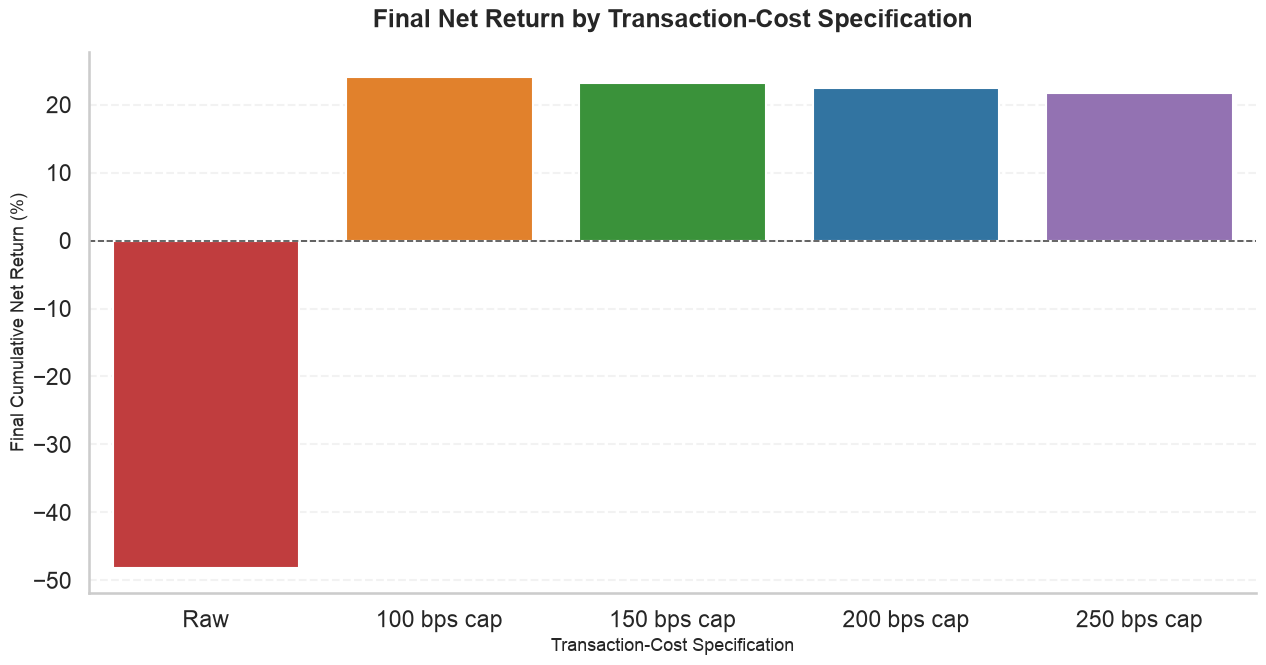

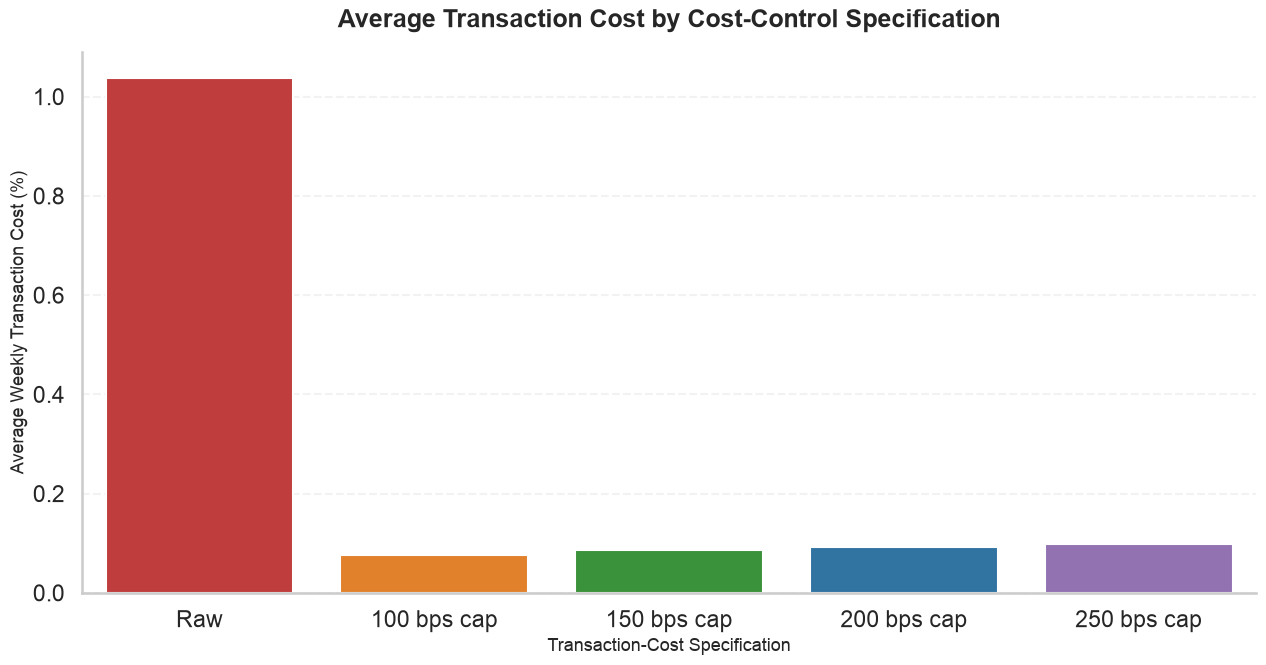


===== PRIMARY 150 BPS RESULT =====
Gross Return: 32.89%
Net Return: 23.15%
Average Turnover: 31.88%
Average Weekly Transaction Cost: 0.09%
Total Transaction Cost: 7.63%


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 0. SEABORN VISUAL STYLE
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="talk"
)

# Distinct colors for the five cost scenarios
scenario_palette = {
    "Raw": "#D62728",          # red
    "100 bps cap": "#FF7F0E",  # orange
    "150 bps cap": "#2CA02C",  # green
    "200 bps cap": "#1F77B4",  # blue
    "250 bps cap": "#9467BD",  # purple
}


# ============================================================
# 1. PREPARE CUMULATIVE RETURN SERIES
# ============================================================

scenario_returns = {
    "Raw": returns_raw,
    "100 bps cap": returns_100,
    "150 bps cap": returns_150,
    "200 bps cap": returns_200,
    "250 bps cap": returns_250,
}


plot_data = {}

for name, df in scenario_returns.items():

    temp = (
        df
        .sort_values("date")
        .copy()
    )

    temp["cumulative_gross_return"] = (
        1 + temp["gross_return"].fillna(0)
    ).cumprod() - 1

    temp["cumulative_net_return"] = (
        1 + temp["net_return"].fillna(0)
    ).cumprod() - 1

    plot_data[name] = temp


# ============================================================
# 2. SEABORN GRAPH:
# RAW VS COST-CONTROLLED NET RETURNS
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

for name, temp in plot_data.items():

    sns.lineplot(
        data=temp,
        x="date",
        y=temp["cumulative_net_return"] * 100,
        label=name,
        linewidth=2.4,
        color=scenario_palette[name],
        ax=ax,
    )


# Zero-return reference line
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.3,
    color="black",
    alpha=0.7,
)


ax.set_title(
    "Ridge + TRACE MRR + MILP\n"
    "Net Return Sensitivity to Transaction-Cost Tail Control",
    fontsize=18,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Date",
    fontsize=13,
)

ax.set_ylabel(
    "Cumulative Net Return (%)",
    fontsize=13,
)


# Cleaner legend
ax.legend(
    title="Transaction-Cost Specification",
    frameon=True,
    fontsize=11,
    title_fontsize=11,
)


# Light research-paper style grid
ax.grid(
    True,
    linestyle="--",
    alpha=0.25,
)


sns.despine()

plt.tight_layout()
plt.show()


# ============================================================
# 3. PRIMARY 150-BPS SPECIFICATION:
# GROSS VS NET RETURN
# ============================================================

primary_plot = plot_data[
    "150 bps cap"
].copy()


fig, ax = plt.subplots(figsize=(16, 8))


sns.lineplot(
    data=primary_plot,
    x="date",
    y=primary_plot["cumulative_gross_return"] * 100,
    label="Gross Return",
    linewidth=2.6,
    color="#1F77B4",
    ax=ax,
)


sns.lineplot(
    data=primary_plot,
    x="date",
    y=primary_plot["cumulative_net_return"] * 100,
    label="Net Return (150 bps cap)",
    linewidth=2.6,
    color="#2CA02C",
    ax=ax,
)


ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.3,
    color="black",
    alpha=0.7,
)


ax.set_title(
    "Ridge + TRACE MRR + MILP: Cumulative Return\n"
    "150 bps Transaction-Cost Cap",
    fontsize=18,
    fontweight="bold",
    pad=18,
)


ax.set_xlabel(
    "Date",
    fontsize=13,
)


ax.set_ylabel(
    "Cumulative Return (%)",
    fontsize=13,
)


ax.legend(
    frameon=True,
    fontsize=11,
)


ax.grid(
    True,
    linestyle="--",
    alpha=0.25,
)


sns.despine()

plt.tight_layout()
plt.show()


# ============================================================
# 4. FINAL PERFORMANCE COMPARISON
# ============================================================

comparison_rows = []

for name, temp in plot_data.items():

    final_gross = (
        temp["cumulative_gross_return"]
        .iloc[-1]
    )

    final_net = (
        temp["cumulative_net_return"]
        .iloc[-1]
    )

    avg_turnover = (
        temp["turnover"].mean()
    )

    avg_cost = (
        temp["transaction_cost"].mean()
    )

    total_cost = (
        temp["transaction_cost"].sum()
    )

    comparison_rows.append(
        {
            "Scenario": name,

            "Final Gross Return":
                final_gross,

            "Final Net Return":
                final_net,

            "Average Turnover":
                avg_turnover,

            "Average Weekly Cost":
                avg_cost,

            "Total Transaction Cost":
                total_cost,
        }
    )


performance_comparison = pd.DataFrame(
    comparison_rows
)


# ============================================================
# 5. FORMAT TABLE
# ============================================================

display_table = (
    performance_comparison.copy()
)


pct_cols = [
    "Final Gross Return",
    "Final Net Return",
    "Average Turnover",
    "Average Weekly Cost",
    "Total Transaction Cost",
]


for col in pct_cols:

    display_table[col] = (
        display_table[col]
        .map(lambda x: f"{x:.2%}")
    )


print(
    "===== COST CAP PERFORMANCE COMPARISON ====="
)

display(display_table)


# ============================================================
# 6. SEABORN BAR CHART:
# FINAL NET RETURN BY COST SPECIFICATION
# ============================================================

bar_data = (
    performance_comparison
    .copy()
)

bar_data["Final Net Return (%)"] = (
    bar_data["Final Net Return"] * 100
)


fig, ax = plt.subplots(figsize=(13, 7))


sns.barplot(
    data=bar_data,
    x="Scenario",
    y="Final Net Return (%)",
    hue="Scenario",
    palette=scenario_palette,
    legend=False,
    ax=ax,
)


ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    color="black",
    alpha=0.7,
)


ax.set_title(
    "Final Net Return by Transaction-Cost Specification",
    fontsize=18,
    fontweight="bold",
    pad=18,
)


ax.set_xlabel(
    "Transaction-Cost Specification",
    fontsize=13,
)


ax.set_ylabel(
    "Final Cumulative Net Return (%)",
    fontsize=13,
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)


sns.despine()

plt.tight_layout()
plt.show()


# ============================================================
# 7. SEABORN BAR CHART:
# AVERAGE TRANSACTION COST
# ============================================================

cost_bar_data = (
    performance_comparison
    .copy()
)

cost_bar_data["Average Weekly Cost (%)"] = (
    cost_bar_data["Average Weekly Cost"] * 100
)


fig, ax = plt.subplots(figsize=(13, 7))


sns.barplot(
    data=cost_bar_data,
    x="Scenario",
    y="Average Weekly Cost (%)",
    hue="Scenario",
    palette=scenario_palette,
    legend=False,
    ax=ax,
)


ax.set_title(
    "Average Transaction Cost by Cost-Control Specification",
    fontsize=18,
    fontweight="bold",
    pad=18,
)


ax.set_xlabel(
    "Transaction-Cost Specification",
    fontsize=13,
)


ax.set_ylabel(
    "Average Weekly Transaction Cost (%)",
    fontsize=13,
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)


sns.despine()

plt.tight_layout()
plt.show()


# ============================================================
# 8. PRINT PRIMARY RESULT
# ============================================================

print("\n===== PRIMARY 150 BPS RESULT =====")

print(
    "Gross Return:",
    f"{primary_plot['cumulative_gross_return'].iloc[-1]:.2%}"
)

print(
    "Net Return:",
    f"{primary_plot['cumulative_net_return'].iloc[-1]:.2%}"
)

print(
    "Average Turnover:",
    f"{returns_150['turnover'].mean():.2%}"
)

print(
    "Average Weekly Transaction Cost:",
    f"{returns_150['transaction_cost'].mean():.2%}"
)

print(
    "Total Transaction Cost:",
    f"{returns_150['transaction_cost'].sum():.2%}"
)

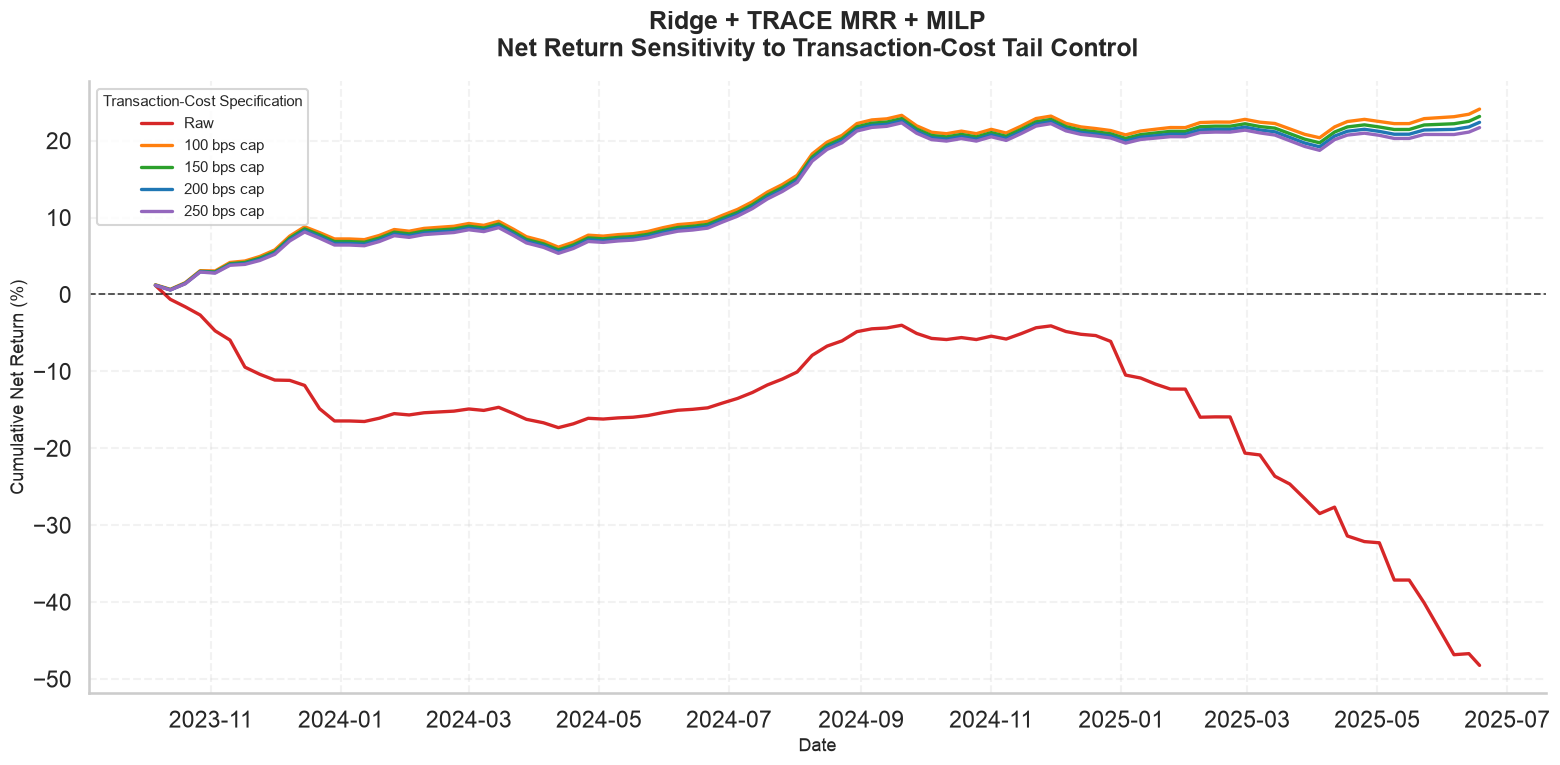

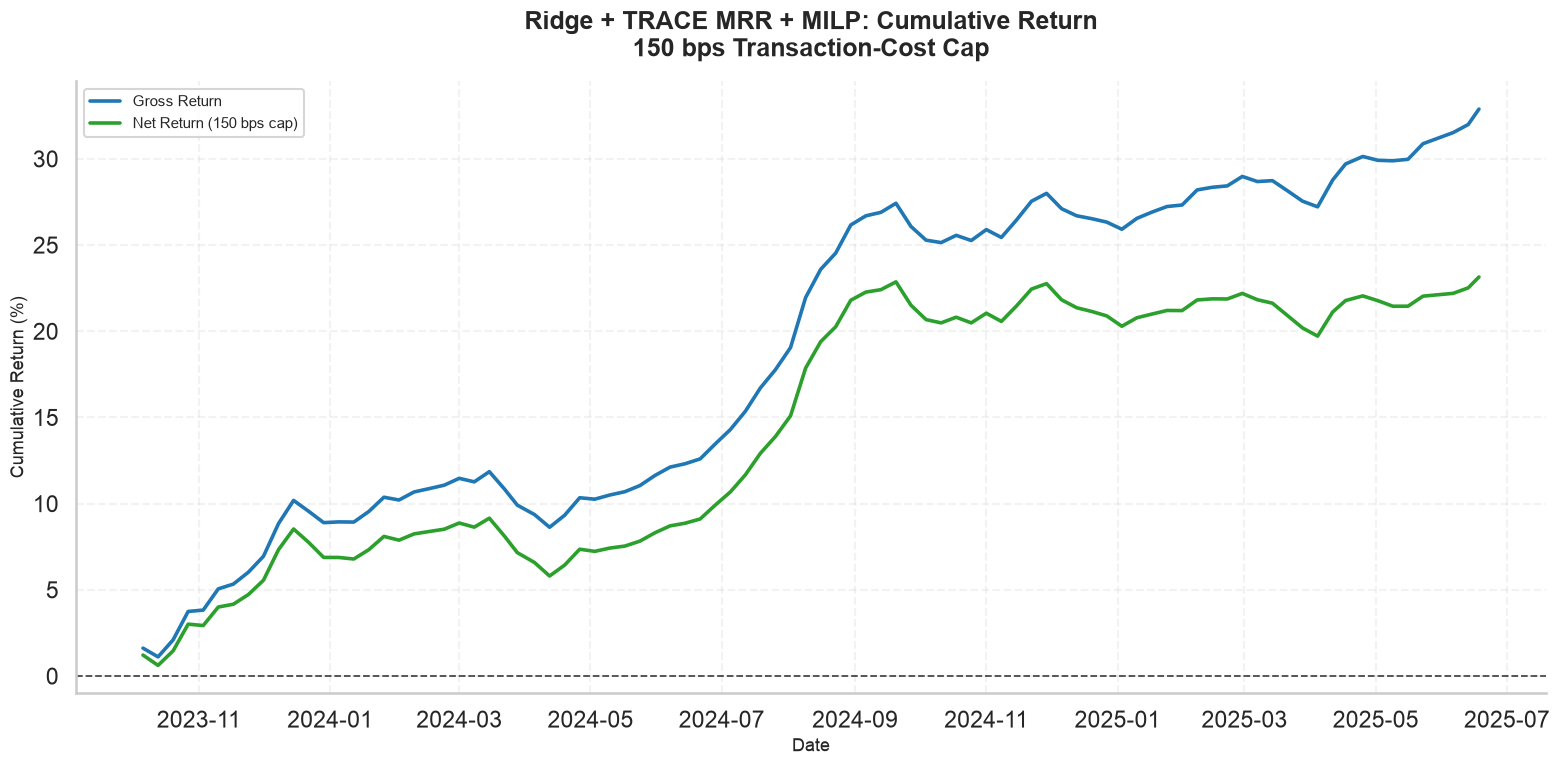

===== COST CAP PERFORMANCE COMPARISON =====


,Scenario,Final Gross Return,Final Net Return,Average Turnover,Average Weekly Cost,Total Transaction Cost
0,Raw,32.89%,-48.22%,31.88%,1.04%,92.36%
1,100 bps cap,32.89%,24.10%,31.88%,0.08%,6.86%
2,150 bps cap,32.89%,23.15%,31.88%,0.09%,7.63%
3,200 bps cap,32.89%,22.38%,31.88%,0.09%,8.26%
4,250 bps cap,32.89%,21.70%,31.88%,0.10%,8.82%


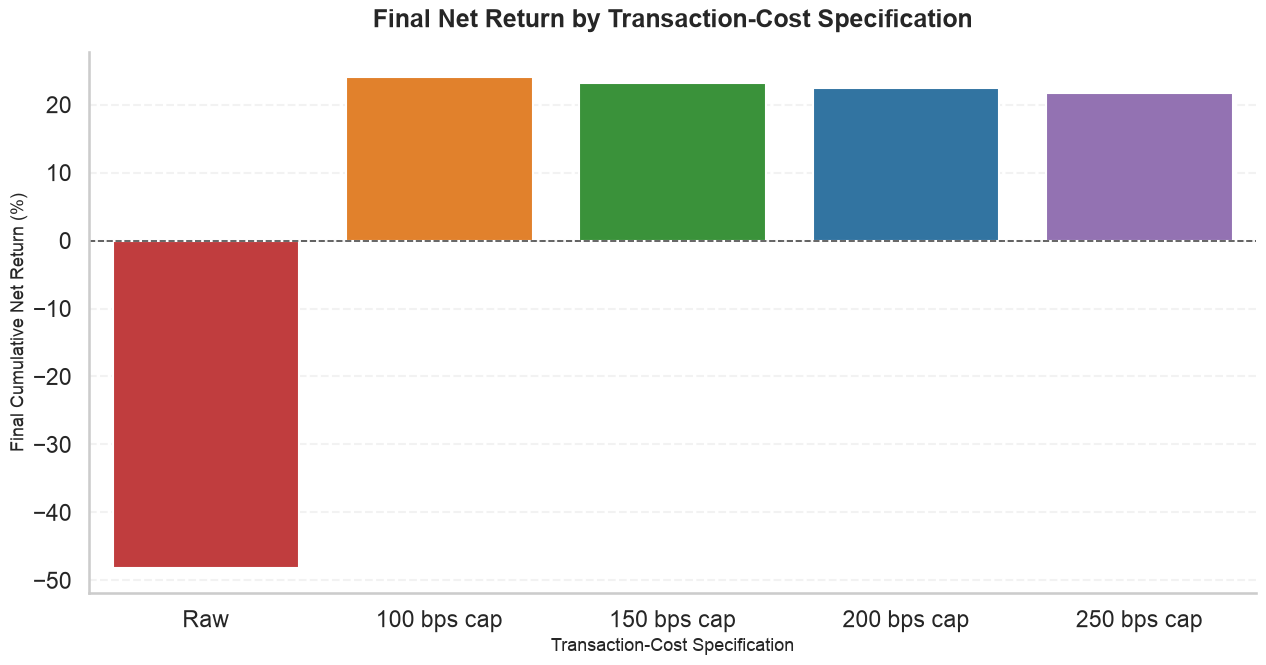

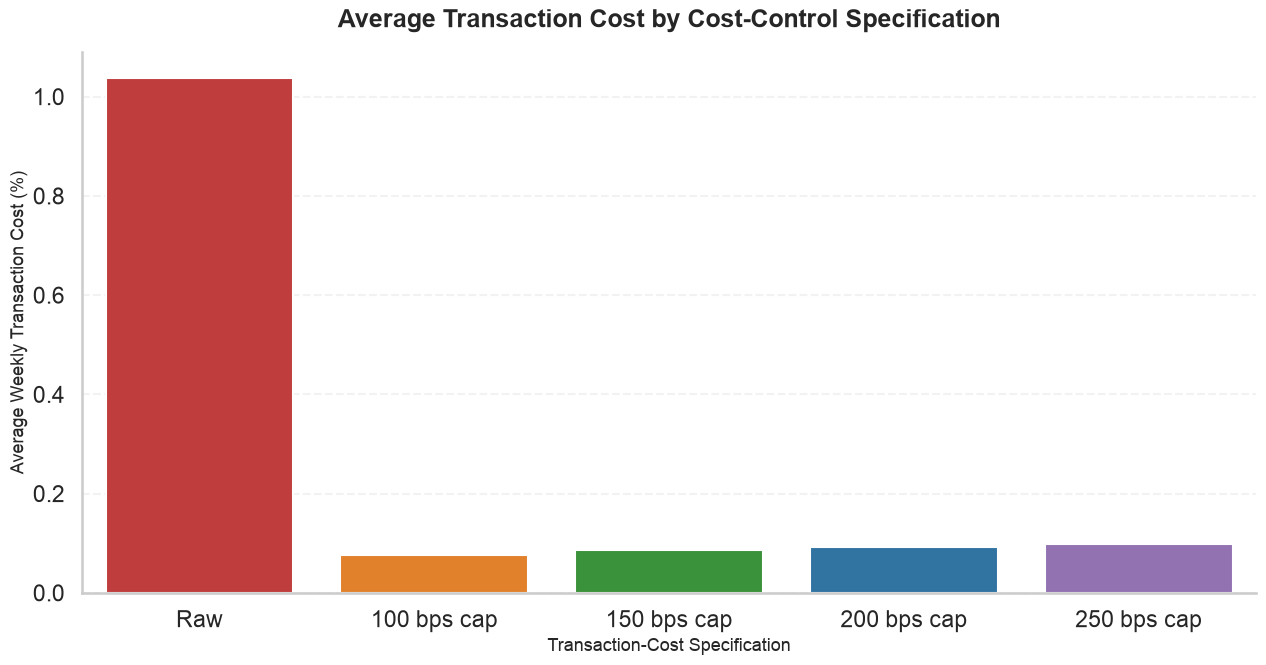


===== PRIMARY 150 BPS RESULT =====
Gross Return: 32.89%
Net Return: 23.15%
Average Turnover: 31.88%
Average Weekly Transaction Cost: 0.09%
Total Transaction Cost: 7.63%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 0. SEABORN VISUAL STYLE
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="talk"
)

# Distinct colors for the five cost scenarios
scenario_palette = {
    "Raw": "#D62728",          # red
    "100 bps cap": "#FF7F0E",  # orange
    "150 bps cap": "#2CA02C",  # green
    "200 bps cap": "#1F77B4",  # blue
    "250 bps cap": "#9467BD",  # purple
}


# ============================================================
# 1. PREPARE CUMULATIVE RETURN SERIES
# ============================================================

scenario_returns = {
    "Raw": returns_raw,
    "100 bps cap": returns_100,
    "150 bps cap": returns_150,
    "200 bps cap": returns_200,
    "250 bps cap": returns_250,
}


plot_data = {}

for name, df in scenario_returns.items():

    temp = (
        df
        .sort_values("date")
        .copy()
    )

    temp["cumulative_gross_return"] = (
        1 + temp["gross_return"].fillna(0)
    ).cumprod() - 1

    temp["cumulative_net_return"] = (
        1 + temp["net_return"].fillna(0)
    ).cumprod() - 1

    plot_data[name] = temp


# ============================================================
# 2. SEABORN GRAPH:
# RAW VS COST-CONTROLLED NET RETURNS
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

for name, temp in plot_data.items():

    sns.lineplot(
        data=temp,
        x="date",
        y=temp["cumulative_net_return"] * 100,
        label=name,
        linewidth=2.4,
        color=scenario_palette[name],
        ax=ax,
    )


# Zero-return reference line
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.3,
    color="black",
    alpha=0.7,
)


ax.set_title(
    "Ridge + TRACE MRR + MILP\n"
    "Net Return Sensitivity to Transaction-Cost Tail Control",
    fontsize=18,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Date",
    fontsize=13,
)

ax.set_ylabel(
    "Cumulative Net Return (%)",
    fontsize=13,
)


# Cleaner legend
ax.legend(
    title="Transaction-Cost Specification",
    frameon=True,
    fontsize=11,
    title_fontsize=11,
)


# Light research-paper style grid
ax.grid(
    True,
    linestyle="--",
    alpha=0.25,
)


sns.despine()

plt.tight_layout()
plt.show()


# ============================================================
# 3. PRIMARY 150-BPS SPECIFICATION:
# GROSS VS NET RETURN
# ============================================================

primary_plot = plot_data[
    "150 bps cap"
].copy()


fig, ax = plt.subplots(figsize=(16, 8))


sns.lineplot(
    data=primary_plot,
    x="date",
    y=primary_plot["cumulative_gross_return"] * 100,
    label="Gross Return",
    linewidth=2.6,
    color="#1F77B4",
    ax=ax,
)


sns.lineplot(
    data=primary_plot,
    x="date",
    y=primary_plot["cumulative_net_return"] * 100,
    label="Net Return (150 bps cap)",
    linewidth=2.6,
    color="#2CA02C",
    ax=ax,
)


ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.3,
    color="black",
    alpha=0.7,
)


ax.set_title(
    "Ridge + TRACE MRR + MILP: Cumulative Return\n"
    "150 bps Transaction-Cost Cap",
    fontsize=18,
    fontweight="bold",
    pad=18,
)


ax.set_xlabel(
    "Date",
    fontsize=13,
)


ax.set_ylabel(
    "Cumulative Return (%)",
    fontsize=13,
)


ax.legend(
    frameon=True,
    fontsize=11,
)


ax.grid(
    True,
    linestyle="--",
    alpha=0.25,
)


sns.despine()

plt.tight_layout()
plt.show()


# ============================================================
# 4. FINAL PERFORMANCE COMPARISON
# ============================================================

comparison_rows = []

for name, temp in plot_data.items():

    final_gross = (
        temp["cumulative_gross_return"]
        .iloc[-1]
    )

    final_net = (
        temp["cumulative_net_return"]
        .iloc[-1]
    )

    avg_turnover = (
        temp["turnover"].mean()
    )

    avg_cost = (
        temp["transaction_cost"].mean()
    )

    total_cost = (
        temp["transaction_cost"].sum()
    )

    comparison_rows.append(
        {
            "Scenario": name,

            "Final Gross Return":
                final_gross,

            "Final Net Return":
                final_net,

            "Average Turnover":
                avg_turnover,

            "Average Weekly Cost":
                avg_cost,

            "Total Transaction Cost":
                total_cost,
        }
    )


performance_comparison = pd.DataFrame(
    comparison_rows
)


# ============================================================
# 5. FORMAT TABLE
# ============================================================

display_table = (
    performance_comparison.copy()
)


pct_cols = [
    "Final Gross Return",
    "Final Net Return",
    "Average Turnover",
    "Average Weekly Cost",
    "Total Transaction Cost",
]


for col in pct_cols:

    display_table[col] = (
        display_table[col]
        .map(lambda x: f"{x:.2%}")
    )


print(
    "===== COST CAP PERFORMANCE COMPARISON ====="
)

display(display_table)


# ============================================================
# 6. SEABORN BAR CHART:
# FINAL NET RETURN BY COST SPECIFICATION
# ============================================================

bar_data = (
    performance_comparison
    .copy()
)

bar_data["Final Net Return (%)"] = (
    bar_data["Final Net Return"] * 100
)


fig, ax = plt.subplots(figsize=(13, 7))


sns.barplot(
    data=bar_data,
    x="Scenario",
    y="Final Net Return (%)",
    hue="Scenario",
    palette=scenario_palette,
    legend=False,
    ax=ax,
)


ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    color="black",
    alpha=0.7,
)


ax.set_title(
    "Final Net Return by Transaction-Cost Specification",
    fontsize=18,
    fontweight="bold",
    pad=18,
)


ax.set_xlabel(
    "Transaction-Cost Specification",
    fontsize=13,
)


ax.set_ylabel(
    "Final Cumulative Net Return (%)",
    fontsize=13,
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)


sns.despine()

plt.tight_layout()
plt.show()


# ============================================================
# 7. SEABORN BAR CHART:
# AVERAGE TRANSACTION COST
# ============================================================

cost_bar_data = (
    performance_comparison
    .copy()
)

cost_bar_data["Average Weekly Cost (%)"] = (
    cost_bar_data["Average Weekly Cost"] * 100
)


fig, ax = plt.subplots(figsize=(13, 7))


sns.barplot(
    data=cost_bar_data,
    x="Scenario",
    y="Average Weekly Cost (%)",
    hue="Scenario",
    palette=scenario_palette,
    legend=False,
    ax=ax,
)


ax.set_title(
    "Average Transaction Cost by Cost-Control Specification",
    fontsize=18,
    fontweight="bold",
    pad=18,
)


ax.set_xlabel(
    "Transaction-Cost Specification",
    fontsize=13,
)


ax.set_ylabel(
    "Average Weekly Transaction Cost (%)",
    fontsize=13,
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)


sns.despine()

plt.tight_layout()
plt.show()


# ============================================================
# 8. PRINT PRIMARY RESULT
# ============================================================

print("\n===== PRIMARY 150 BPS RESULT =====")

print(
    "Gross Return:",
    f"{primary_plot['cumulative_gross_return'].iloc[-1]:.2%}"
)

print(
    "Net Return:",
    f"{primary_plot['cumulative_net_return'].iloc[-1]:.2%}"
)

print(
    "Average Turnover:",
    f"{returns_150['turnover'].mean():.2%}"
)

print(
    "Average Weekly Transaction Cost:",
    f"{returns_150['transaction_cost'].mean():.2%}"
)

print(
    "Total Transaction Cost:",
    f"{returns_150['transaction_cost'].sum():.2%}"
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


# ============================================================
# 1. STRATEGY RETURNS
# ============================================================
#
# IMPORTANT:
# Use returns_150.
#
# Do NOT use ridge_cost_analysis because that is holdings-level
# and does not contain gross_return / net_return.
# ============================================================

strategy = (
    returns_150
    .sort_values("date")
    .copy()
)

strategy["date"] = pd.to_datetime(strategy["date"])


# ============================================================
# 2. CUMULATIVE STRATEGY RETURNS
# ============================================================

strategy["cumulative_gross_return"] = (
    1 + strategy["gross_return"].fillna(0)
).cumprod() - 1


strategy["cumulative_net_return"] = (
    1 + strategy["net_return"].fillna(0)
).cumprod() - 1


# ============================================================
# 3. DOWNLOAD LQD BENCHMARK
# ============================================================

start_date = (
    strategy["date"].min()
    - pd.Timedelta(days=15)
)

end_date = (
    strategy["date"].max()
    + pd.Timedelta(days=20)
)


lqd = yf.download(
    "LQD",
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
)


# ------------------------------------------------------------
# Handle newer yfinance MultiIndex format
# ------------------------------------------------------------

if isinstance(lqd.columns, pd.MultiIndex):
    lqd.columns = lqd.columns.get_level_values(0)


lqd = (
    lqd
    .reset_index()
    [["Date", "Close"]]
    .rename(
        columns={
            "Date": "date",
            "Close": "LQD_Close",
        }
    )
)

lqd["date"] = pd.to_datetime(lqd["date"])

lqd = (
    lqd
    .sort_values("date")
    .reset_index(drop=True)
)


# ============================================================
# 4. CALCULATE LQD 5-TRADING-DAY FORWARD RETURN
# ============================================================
#
# This matches your Ridge target:
#
# Price[t+5] / Price[t] - 1
#
# rather than using backward-looking pct_change().
# ============================================================

lqd["LQD_5d_return"] = (
    lqd["LQD_Close"].shift(-5)
    / lqd["LQD_Close"]
    - 1
)


# ============================================================
# 5. MATCH LQD TO STRATEGY REBALANCE DATES
# ============================================================

strategy = (
    pd.merge_asof(
        strategy.sort_values("date"),
        lqd[
            [
                "date",
                "LQD_Close",
                "LQD_5d_return",
            ]
        ].sort_values("date"),
        on="date",
        direction="backward",
    )
)


# ============================================================
# 6. CUMULATIVE LQD RETURN
# ============================================================

strategy["cumulative_LQD"] = (
    1
    + strategy["LQD_5d_return"].fillna(0)
).cumprod() - 1


# ============================================================
# 7. PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 7)
)


ax.plot(
    strategy["date"],
    strategy["cumulative_gross_return"] * 100,
    linewidth=2.5,
    label="Strategy Gross Return",
)


ax.plot(
    strategy["date"],
    strategy["cumulative_net_return"] * 100,
    linewidth=2.5,
    label="Strategy Net Return (150 bps cap)",
)


ax.plot(
    strategy["date"],
    strategy["cumulative_LQD"] * 100,
    linewidth=2.5,
    linestyle="--",
    label="LQD Benchmark",
)


# ============================================================
# 8. ZERO LINE
# ============================================================

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)


# ============================================================
# 9. LABELS
# ============================================================

ax.set_title(
    "Ridge + TRACE MRR + MILP: Cumulative Return\n"
    "150 bps Transaction-Cost Cap vs LQD Benchmark",
    fontsize=18,
    fontweight="bold",
)


ax.set_xlabel(
    "Date",
    fontsize=13,
)


ax.set_ylabel(
    "Cumulative Return (%)",
    fontsize=13,
)


ax.legend(
    fontsize=11,
)


ax.grid(
    linestyle="--",
    alpha=0.25,
)


plt.tight_layout()
plt.show()


# ============================================================
# 10. FINAL PERFORMANCE
# ============================================================

print("=" * 60)
print("FINAL CUMULATIVE RETURNS")
print("=" * 60)

print(
    "Strategy Gross:",
    f"{strategy['cumulative_gross_return'].iloc[-1]:.2%}"
)

print(
    "Strategy Net (150 bps):",
    f"{strategy['cumulative_net_return'].iloc[-1]:.2%}"
)

print(
    "LQD:",
    f"{strategy['cumulative_LQD'].iloc[-1]:.2%}"
)

KeyError: 'gross_return'

In [70]:
# ============================================================
# 4. ADVANCED PERFORMANCE COMPARISON
#
# Includes:
# - Final gross / net return
# - Annualized gross / net volatility
# - Gross / net Sharpe ratio
# - Turnover
# - Transaction costs
#
# Weekly strategy -> annualization factor = 52
# ============================================================

import numpy as np
import pandas as pd


ANNUALIZATION = 52

# Set to zero for simple strategy comparison.
# Sharpe technically uses excess return over risk-free rate.
RISK_FREE_ANNUAL = 0.00


# Convert annual risk-free rate to weekly
RISK_FREE_WEEKLY = (
    (1 + RISK_FREE_ANNUAL) ** (1 / ANNUALIZATION)
    - 1
)


def annualized_volatility(
    returns,
    annualization=52,
):

    x = (
        pd.to_numeric(
            returns,
            errors="coerce",
        )
        .dropna()
    )

    if len(x) < 2:

        return np.nan

    return (
        x.std(ddof=1)
        *
        np.sqrt(annualization)
    )


def annualized_sharpe(
    returns,
    risk_free_weekly=0.0,
    annualization=52,
):

    x = (
        pd.to_numeric(
            returns,
            errors="coerce",
        )
        .dropna()
    )

    if len(x) < 2:

        return np.nan


    excess = (
        x
        -
        risk_free_weekly
    )


    vol = (
        excess.std(ddof=1)
    )


    if (
        not np.isfinite(vol)
        or
        vol <= 0
    ):

        return np.nan


    return (
        np.sqrt(annualization)
        *
        excess.mean()
        /
        vol
    )


comparison_rows = []


for name, temp in plot_data.items():

    temp = (
        temp
        .sort_values("date")
        .copy()
    )


    # ========================================================
    # CUMULATIVE RETURN
    # ========================================================

    final_gross = (
        temp[
            "cumulative_gross_return"
        ]
        .iloc[-1]
    )


    final_net = (
        temp[
            "cumulative_net_return"
        ]
        .iloc[-1]
    )


    # ========================================================
    # VOLATILITY
    # ========================================================

    gross_vol = (
        annualized_volatility(
            temp[
                "gross_return"
            ]
        )
    )


    net_vol = (
        annualized_volatility(
            temp[
                "net_return"
            ]
        )
    )


    # ========================================================
    # SHARPE
    # ========================================================

    gross_sharpe = (
        annualized_sharpe(
            temp[
                "gross_return"
            ],
            risk_free_weekly=(
                RISK_FREE_WEEKLY
            ),
        )
    )


    net_sharpe = (
        annualized_sharpe(
            temp[
                "net_return"
            ],
            risk_free_weekly=(
                RISK_FREE_WEEKLY
            ),
        )
    )


    # ========================================================
    # TURNOVER / COST
    # ========================================================

    avg_turnover = (
        temp[
            "turnover"
        ]
        .mean()
    )


    avg_cost = (
        temp[
            "transaction_cost"
        ]
        .mean()
    )


    total_cost = (
        temp[
            "transaction_cost"
        ]
        .sum()
    )


    # ========================================================
    # WEEKLY RETURN STATS
    # ========================================================

    avg_gross_weekly = (
        temp[
            "gross_return"
        ]
        .mean()
    )


    avg_net_weekly = (
        temp[
            "net_return"
        ]
        .mean()
    )


    comparison_rows.append(
        {

            "Scenario":
                name,

            "Final Gross Return":
                final_gross,

            "Final Net Return":
                final_net,

            "Annualized Gross Volatility":
                gross_vol,

            "Annualized Net Volatility":
                net_vol,

            "Gross Sharpe":
                gross_sharpe,

            "Net Sharpe":
                net_sharpe,

            "Average Weekly Gross Return":
                avg_gross_weekly,

            "Average Weekly Net Return":
                avg_net_weekly,

            "Average Turnover":
                avg_turnover,

            "Average Weekly Cost":
                avg_cost,

            "Total Transaction Cost":
                total_cost,
        }
    )


performance_comparison = (
    pd.DataFrame(
        comparison_rows
    )
)


# ============================================================
# 5. RAW NUMERIC PERFORMANCE TABLE
# ============================================================

print()
print("=" * 120)
print(
    "RIDGE + TRACE MRR + MILP PERFORMANCE METRICS"
)
print("=" * 120)

display(
    performance_comparison
)


# ============================================================
# 6. FORMATTED TABLE
# ============================================================

display_table = (
    performance_comparison
    .copy()
)


pct_cols = [

    "Final Gross Return",
    "Final Net Return",

    "Annualized Gross Volatility",
    "Annualized Net Volatility",

    "Average Weekly Gross Return",
    "Average Weekly Net Return",

    "Average Turnover",
    "Average Weekly Cost",
    "Total Transaction Cost",
]


for col in pct_cols:

    display_table[col] = (
        display_table[col]
        .map(
            lambda x:
                f"{x:.2%}"
                if pd.notna(x)
                else "NaN"
        )
    )


for col in [
    "Gross Sharpe",
    "Net Sharpe",
]:

    display_table[col] = (
        display_table[col]
        .map(
            lambda x:
                f"{x:.3f}"
                if pd.notna(x)
                else "NaN"
        )
    )


print()
print("=" * 120)
print(
    "COST-CAP PERFORMANCE COMPARISON"
)
print("=" * 120)

display(
    display_table
)


# ============================================================
# 7. PRIMARY 150-BPS RESULT
# ============================================================

primary_returns = (
    returns_150
    .sort_values("date")
    .copy()
)


primary_gross_vol = (
    annualized_volatility(
        primary_returns[
            "gross_return"
        ]
    )
)


primary_net_vol = (
    annualized_volatility(
        primary_returns[
            "net_return"
        ]
    )
)


primary_gross_sharpe = (
    annualized_sharpe(
        primary_returns[
            "gross_return"
        ],
        risk_free_weekly=(
            RISK_FREE_WEEKLY
        ),
    )
)


primary_net_sharpe = (
    annualized_sharpe(
        primary_returns[
            "net_return"
        ],
        risk_free_weekly=(
            RISK_FREE_WEEKLY
        ),
    )
)


print()
print("=" * 80)
print(
    "PRIMARY 150 BPS RESULT"
)
print("=" * 80)


print(
    "Gross Return:",
    f"{primary_plot['cumulative_gross_return'].iloc[-1]:.2%}"
)


print(
    "Net Return:",
    f"{primary_plot['cumulative_net_return'].iloc[-1]:.2%}"
)


print(
    "Annualized Gross Volatility:",
    f"{primary_gross_vol:.2%}"
)


print(
    "Annualized Net Volatility:",
    f"{primary_net_vol:.2%}"
)


print(
    "Gross Sharpe Ratio:",
    f"{primary_gross_sharpe:.3f}"
)


print(
    "Net Sharpe Ratio:",
    f"{primary_net_sharpe:.3f}"
)


print(
    "Average Turnover:",
    f"{returns_150['turnover'].mean():.2%}"
)


print(
    "Average Weekly Transaction Cost:",
    f"{returns_150['transaction_cost'].mean():.2%}"
)


print(
    "Total Transaction Cost:",
    f"{returns_150['transaction_cost'].sum():.2%}"
)


RIDGE + TRACE MRR + MILP PERFORMANCE METRICS


,Scenario,Final Gross Return,Final Net Return,Annualized Gross Volatility,Annualized Net Volatility,Gross Sharpe,Net Sharpe,Average Weekly Gross Return,Average Weekly Net Return,Average Turnover,Average Weekly Cost,Total Transaction Cost
0,Raw,0.328876,-0.482234,0.046313,0.146096,3.615608,-2.547377,0.00322,-0.007157,0.318803,0.010377,0.923563
1,100 bps cap,0.328876,0.241020,0.046313,0.046175,3.615608,2.758346,0.00322,0.002449,0.318803,0.000771,0.068601
2,150 bps cap,0.328876,0.231491,0.046313,0.046155,3.615608,2.661733,0.00322,0.002363,0.318803,0.000858,0.076330
3,200 bps cap,0.328876,0.223836,0.046313,0.046142,3.615608,2.583327,0.00322,0.002292,0.318803,0.000928,0.082580
4,250 bps cap,0.328876,0.216958,0.046313,0.046163,3.615608,2.510686,0.00322,0.002229,0.318803,0.000991,0.088227



COST-CAP PERFORMANCE COMPARISON


,Scenario,Final Gross Return,Final Net Return,Annualized Gross Volatility,Annualized Net Volatility,Gross Sharpe,Net Sharpe,Average Weekly Gross Return,Average Weekly Net Return,Average Turnover,Average Weekly Cost,Total Transaction Cost
0,Raw,32.89%,-48.22%,4.63%,14.61%,3.616,-2.547,0.32%,-0.72%,31.88%,1.04%,92.36%
1,100 bps cap,32.89%,24.10%,4.63%,4.62%,3.616,2.758,0.32%,0.24%,31.88%,0.08%,6.86%
2,150 bps cap,32.89%,23.15%,4.63%,4.62%,3.616,2.662,0.32%,0.24%,31.88%,0.09%,7.63%
3,200 bps cap,32.89%,22.38%,4.63%,4.61%,3.616,2.583,0.32%,0.23%,31.88%,0.09%,8.26%
4,250 bps cap,32.89%,21.70%,4.63%,4.62%,3.616,2.511,0.32%,0.22%,31.88%,0.10%,8.82%



PRIMARY 150 BPS RESULT
Gross Return: 32.89%
Net Return: 23.15%
Annualized Gross Volatility: 4.63%
Annualized Net Volatility: 4.62%
Gross Sharpe Ratio: 3.616
Net Sharpe Ratio: 2.662
Average Turnover: 31.88%
Average Weekly Transaction Cost: 0.09%
Total Transaction Cost: 7.63%


In [76]:
# ============================================================
# FIX DATE DTYPES BEFORE MERGE
# ============================================================

strategy["date"] = pd.to_datetime(
    strategy["date"],
    errors="coerce"
)

lqd["date"] = pd.to_datetime(
    lqd["date"],
    errors="coerce"
)


# ------------------------------------------------------------
# Remove timezone if one exists
# ------------------------------------------------------------

if getattr(strategy["date"].dt, "tz", None) is not None:
    strategy["date"] = strategy["date"].dt.tz_localize(None)

if getattr(lqd["date"].dt, "tz", None) is not None:
    lqd["date"] = lqd["date"].dt.tz_localize(None)


# ------------------------------------------------------------
# Force EXACTLY SAME datetime resolution
# ------------------------------------------------------------

strategy["date"] = strategy["date"].astype("datetime64[ns]")
lqd["date"] = lqd["date"].astype("datetime64[ns]")


# ------------------------------------------------------------
# Sort before merge_asof
# ------------------------------------------------------------

strategy = (
    strategy
    .dropna(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

lqd = (
    lqd
    .dropna(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)


# ============================================================
# MATCH LQD TO STRATEGY DATES
# ============================================================

strategy = pd.merge_asof(
    strategy,
    lqd[
        [
            "date",
            "LQD_Close",
            "LQD_5d_return"
        ]
    ],
    on="date",
    direction="backward"
)

Strategy observations: 89
LQD matched observations: 89
LQD match rate: 100.00%


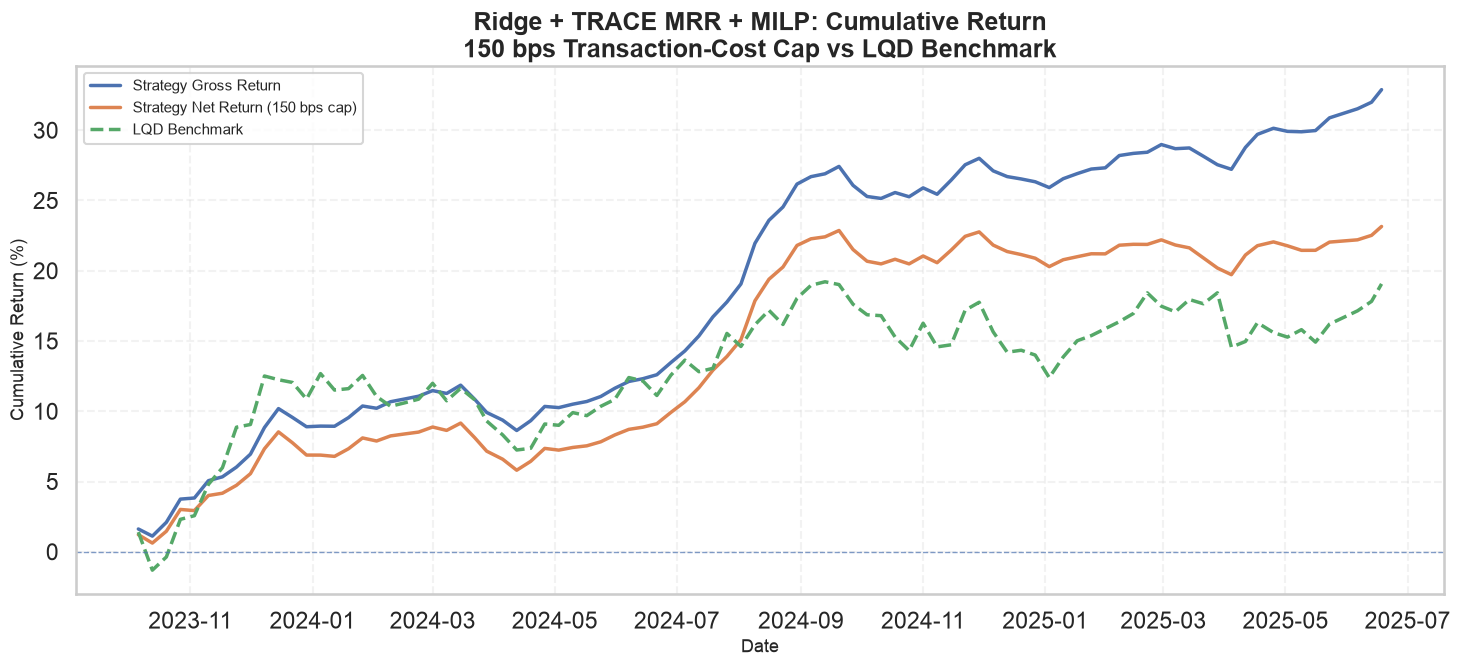


FINAL CUMULATIVE RETURNS
Strategy Gross: 32.89%
Strategy Net (150 bps): 23.15%
LQD Benchmark: 19.06%


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


# ============================================================
# 1. STRATEGY RETURNS
# ============================================================

strategy = (
    returns_150
    .sort_values("date")
    .copy()
)

# Convert to datetime
strategy["date"] = pd.to_datetime(
    strategy["date"],
    errors="coerce"
)

# Remove timezone if present
if getattr(strategy["date"].dt, "tz", None) is not None:
    strategy["date"] = strategy["date"].dt.tz_localize(None)

# Normalize to calendar date
strategy["date"] = strategy["date"].dt.normalize()


# ============================================================
# 2. CUMULATIVE STRATEGY RETURNS
# ============================================================

strategy["cumulative_gross_return"] = (
    1 + strategy["gross_return"].fillna(0)
).cumprod() - 1


strategy["cumulative_net_return"] = (
    1 + strategy["net_return"].fillna(0)
).cumprod() - 1


# ============================================================
# 3. DOWNLOAD LQD
# ============================================================

start_date = (
    strategy["date"].min()
    - pd.Timedelta(days=15)
)

end_date = (
    strategy["date"].max()
    + pd.Timedelta(days=20)
)


lqd = yf.download(
    "LQD",
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
)


# ============================================================
# 4. CLEAN YFINANCE OUTPUT
# ============================================================

if isinstance(lqd.columns, pd.MultiIndex):
    lqd.columns = lqd.columns.get_level_values(0)


lqd = (
    lqd
    .reset_index()
    [["Date", "Close"]]
    .rename(
        columns={
            "Date": "lqd_date",
            "Close": "LQD_Close",
        }
    )
)


lqd["lqd_date"] = pd.to_datetime(
    lqd["lqd_date"],
    errors="coerce"
)

# Remove timezone if necessary
if getattr(lqd["lqd_date"].dt, "tz", None) is not None:
    lqd["lqd_date"] = lqd["lqd_date"].dt.tz_localize(None)

lqd["lqd_date"] = lqd["lqd_date"].dt.normalize()

lqd = (
    lqd
    .dropna(subset=["lqd_date", "LQD_Close"])
    .sort_values("lqd_date")
    .reset_index(drop=True)
)


# ============================================================
# 5. LQD 5-TRADING-DAY FORWARD RETURN
# ============================================================

lqd["LQD_5d_return"] = (
    lqd["LQD_Close"].shift(-5)
    / lqd["LQD_Close"]
    - 1
)


# ============================================================
# 6. CREATE INTEGER DATE KEYS
# ============================================================
#
# This avoids the datetime64[ms] vs datetime64[s] problem
# completely.
# ============================================================

strategy["date_key"] = (
    strategy["date"]
    .astype("datetime64[ns]")
    .astype("int64")
)

lqd["date_key"] = (
    lqd["lqd_date"]
    .astype("datetime64[ns]")
    .astype("int64")
)


strategy = (
    strategy
    .dropna(subset=["date"])
    .sort_values("date_key")
    .reset_index(drop=True)
)

lqd = (
    lqd
    .sort_values("date_key")
    .reset_index(drop=True)
)


# ============================================================
# 7. MATCH LQD TO STRATEGY REBALANCE DATES
# ============================================================

strategy = pd.merge_asof(
    strategy,
    lqd[
        [
            "date_key",
            "lqd_date",
            "LQD_Close",
            "LQD_5d_return",
        ]
    ],
    on="date_key",
    direction="backward",
)


# ============================================================
# 8. CHECK MATCH QUALITY
# ============================================================

print("Strategy observations:", len(strategy))

print(
    "LQD matched observations:",
    strategy["LQD_5d_return"].notna().sum()
)

print(
    "LQD match rate:",
    f"{strategy['LQD_5d_return'].notna().mean():.2%}"
)


# ============================================================
# 9. CUMULATIVE LQD RETURN
# ============================================================

strategy["cumulative_LQD"] = (
    1
    + strategy["LQD_5d_return"].fillna(0)
).cumprod() - 1


# ============================================================
# 10. PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(15, 7))


ax.plot(
    strategy["date"],
    strategy["cumulative_gross_return"] * 100,
    linewidth=2.5,
    label="Strategy Gross Return",
)


ax.plot(
    strategy["date"],
    strategy["cumulative_net_return"] * 100,
    linewidth=2.5,
    label="Strategy Net Return (150 bps cap)",
)


ax.plot(
    strategy["date"],
    strategy["cumulative_LQD"] * 100,
    linewidth=2.5,
    linestyle="--",
    label="LQD Benchmark",
)


ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)


ax.set_title(
    "Ridge + TRACE MRR + MILP: Cumulative Return\n"
    "150 bps Transaction-Cost Cap vs LQD Benchmark",
    fontsize=18,
    fontweight="bold",
)


ax.set_xlabel(
    "Date",
    fontsize=13,
)


ax.set_ylabel(
    "Cumulative Return (%)",
    fontsize=13,
)


ax.legend(
    fontsize=11
)


ax.grid(
    linestyle="--",
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# 11. FINAL PERFORMANCE
# ============================================================

print()
print("=" * 60)
print("FINAL CUMULATIVE RETURNS")
print("=" * 60)

print(
    "Strategy Gross:",
    f"{strategy['cumulative_gross_return'].iloc[-1]:.2%}"
)

print(
    "Strategy Net (150 bps):",
    f"{strategy['cumulative_net_return'].iloc[-1]:.2%}"
)

print(
    "LQD Benchmark:",
    f"{strategy['cumulative_LQD'].iloc[-1]:.2%}"
)

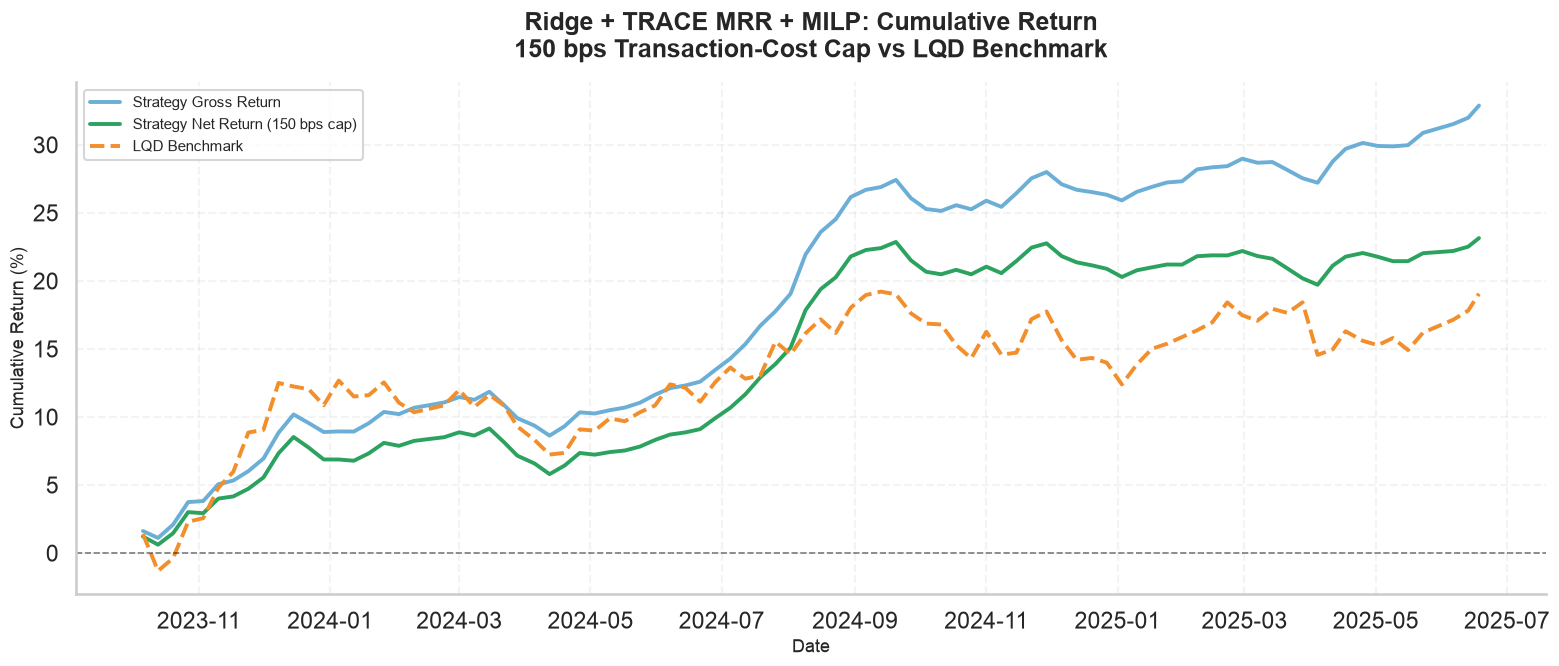

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    context="talk"
)

fig, ax = plt.subplots(figsize=(16, 7))

# Gross return = BLUE
sns.lineplot(
    data=strategy,
    x="date",
    y=strategy["cumulative_gross_return"] * 100,
    ax=ax,
    linewidth=2.8,
    color= "#6BAED6"  ,
    label="Strategy Gross Return"
)
   # orange
# Net return = GREEN
sns.lineplot(
    data=strategy,
    x="date",
    y=strategy["cumulative_net_return"] * 100,
    ax=ax,
    linewidth=2.8,
    color= "#2CA25F",
    label="Strategy Net Return (150 bps cap)"
)

# LQD benchmark = ORANGE dashed
sns.lineplot(
    data=strategy,
    x="date",
    y=strategy["cumulative_LQD"] * 100,
    ax=ax,
    linewidth=2.8,
    linestyle="--",
    color= "#F28E2B",
    label="LQD Benchmark"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    color="black",
    alpha=0.5
)

ax.set_title(
    "Ridge + TRACE MRR + MILP: Cumulative Return\n"
    "150 bps Transaction-Cost Cap vs LQD Benchmark",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Date", fontsize=13)
ax.set_ylabel("Cumulative Return (%)", fontsize=13)

ax.legend(loc="upper left", fontsize=11, frameon=True)

ax.grid(linestyle="--", alpha=0.22)
sns.despine()

plt.tight_layout()
plt.show()

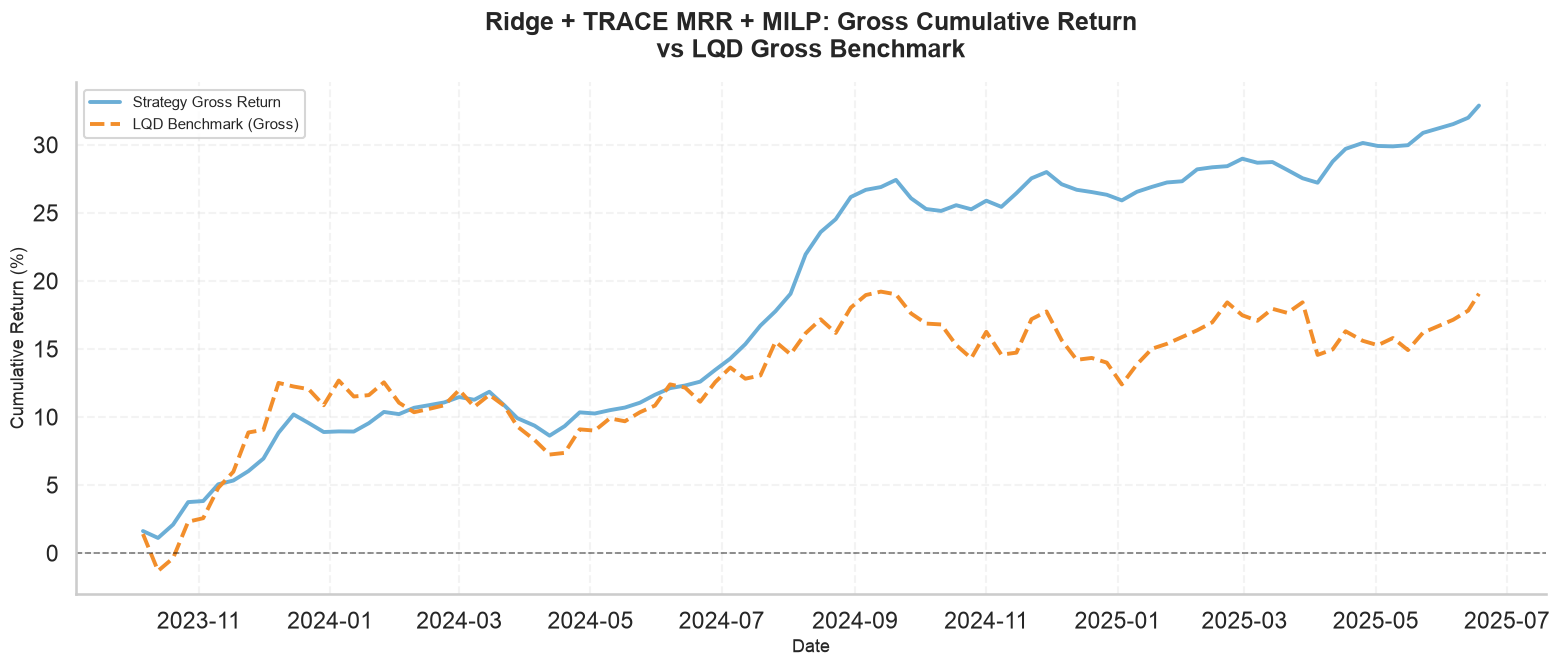

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    context="talk"
)

fig, ax = plt.subplots(figsize=(16, 7))

# Strategy Gross Return = LIGHT BLUE
sns.lineplot(
    data=strategy,
    x="date",
    y=strategy["cumulative_gross_return"] * 100,
    ax=ax,
    linewidth=2.8,
    color="#6BAED6",
    label="Strategy Gross Return"
)

# LQD Benchmark (Gross) = ORANGE dashed
sns.lineplot(
    data=strategy,
    x="date",
    y=strategy["cumulative_LQD"] * 100,
    ax=ax,
    linewidth=2.8,
    linestyle="--",
    color="#F28E2B",
    label="LQD Benchmark (Gross)"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    color="black",
    alpha=0.5
)

ax.set_title(
    "Ridge + TRACE MRR + MILP: Gross Cumulative Return\n"
    "vs LQD Gross Benchmark",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Date", fontsize=13)
ax.set_ylabel("Cumulative Return (%)", fontsize=13)

ax.legend(loc="upper left", fontsize=11, frameon=True)

ax.grid(linestyle="--", alpha=0.22)
sns.despine()

plt.tight_layout()
plt.show()

In [84]:
import numpy as np
import pandas as pd


# ============================================================
# PERFORMANCE / RISK METRICS
# ============================================================

PERIODS_PER_YEAR = 52

# Set to 0 for simple gross Sharpe.
# You can later replace this with Treasury/risk-free rate.
ANNUAL_RF = 0.00


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def performance_metrics(
    returns,
    periods_per_year=52,
    annual_rf=0.0
):
    returns = pd.Series(returns).dropna()

    # Periodic risk-free rate
    rf_period = (
        (1 + annual_rf) ** (1 / periods_per_year)
        - 1
    )

    excess = returns - rf_period

    # -----------------------------------------
    # Annualized volatility
    # -----------------------------------------

    annual_vol = (
        returns.std(ddof=1)
        * np.sqrt(periods_per_year)
    )


    # -----------------------------------------
    # Annualized Sharpe ratio
    # -----------------------------------------

    if excess.std(ddof=1) > 0:
        sharpe = (
            excess.mean()
            / excess.std(ddof=1)
            * np.sqrt(periods_per_year)
        )
    else:
        sharpe = np.nan


    # -----------------------------------------
    # Cumulative return
    # -----------------------------------------

    cumulative_return = (
        (1 + returns).prod() - 1
    )


    # -----------------------------------------
    # Annualized geometric return
    # -----------------------------------------

    n = len(returns)

    if n > 0:
        annualized_return = (
            (1 + cumulative_return)
            ** (periods_per_year / n)
            - 1
        )
    else:
        annualized_return = np.nan


    # -----------------------------------------
    # Maximum drawdown
    # -----------------------------------------

    wealth = (1 + returns).cumprod()

    running_max = wealth.cummax()

    drawdown = (
        wealth / running_max
        - 1
    )

    max_drawdown = drawdown.min()


    # -----------------------------------------
    # Downside volatility
    # -----------------------------------------

    downside = excess[
        excess < 0
    ]

    downside_vol = (
        downside.std(ddof=1)
        * np.sqrt(periods_per_year)
        if len(downside) > 1
        else np.nan
    )


    # -----------------------------------------
    # Sortino ratio
    # -----------------------------------------

    downside_period_std = downside.std(ddof=1)

    if (
        len(downside) > 1
        and downside_period_std > 0
    ):
        sortino = (
            excess.mean()
            / downside_period_std
            * np.sqrt(periods_per_year)
        )
    else:
        sortino = np.nan


    return {
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annual_vol,
        "Sharpe Ratio": sharpe,
        "Downside Volatility": downside_vol,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": max_drawdown,
    }


# ============================================================
# STRATEGY
# ============================================================

strategy_metrics = performance_metrics(
    strategy["gross_return"],
    periods_per_year=PERIODS_PER_YEAR,
    annual_rf=ANNUAL_RF
)


# ============================================================
# LQD
# ============================================================

lqd_metrics = performance_metrics(
    strategy["LQD_5d_return"],
    periods_per_year=PERIODS_PER_YEAR,
    annual_rf=ANNUAL_RF
)


# ============================================================
# COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    "Ridge + MRR + MILP": strategy_metrics,
    "LQD Benchmark": lqd_metrics
}).T


print("=" * 75)
print("STRATEGY VS LQD — RISK / RETURN METRICS")
print("=" * 75)

display(
    comparison.style.format({
        "Cumulative Return": "{:.2%}",
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "Downside Volatility": "{:.2%}",
        "Sortino Ratio": "{:.2f}",
        "Maximum Drawdown": "{:.2%}",
    })
)


# ============================================================
# TRACKING ERROR + INFORMATION RATIO
# ============================================================

aligned = strategy[
    ["gross_return", "LQD_5d_return"]
].dropna()


aligned["excess_return"] = (
    aligned["gross_return"]
    - aligned["LQD_5d_return"]
)


tracking_error = (
    aligned["excess_return"].std(ddof=1)
    * np.sqrt(PERIODS_PER_YEAR)
)


information_ratio = (
    aligned["excess_return"].mean()
    / aligned["excess_return"].std(ddof=1)
    * np.sqrt(PERIODS_PER_YEAR)
)


print()
print("=" * 75)
print("RELATIVE PERFORMANCE VS LQD")
print("=" * 75)

print(
    f"Annualized Tracking Error: {tracking_error:.2%}"
)

print(
    f"Information Ratio:        {information_ratio:.2f}"
)

STRATEGY VS LQD — RISK / RETURN METRICS


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Downside Volatility,Sortino Ratio,Maximum Drawdown
Ridge + MRR + MILP,32.89%,18.07%,4.63%,3.62,2.03%,8.25,-2.88%
LQD Benchmark,19.06%,10.73%,8.37%,1.26,4.89%,2.16,-5.72%



RELATIVE PERFORMANCE VS LQD
Annualized Tracking Error: 6.49%
Information Ratio:        0.95


In [71]:
import numpy as np
import pandas as pd


# ============================================================
# PERFORMANCE METRICS
# ============================================================

def calculate_performance_metrics(
    returns_df,
    annualization=52,
):

    df = (
        returns_df
        .sort_values("date")
        .copy()
    )

    gross = (
        pd.to_numeric(
            df["gross_return"],
            errors="coerce",
        )
        .dropna()
    )

    net = (
        pd.to_numeric(
            df["net_return"],
            errors="coerce",
        )
        .dropna()
    )

    # --------------------------------------------------------
    # Cumulative returns
    # --------------------------------------------------------

    cumulative_gross = (
        (1 + gross).prod() - 1
    )

    cumulative_net = (
        (1 + net).prod() - 1
    )

    # --------------------------------------------------------
    # Annualized return
    # --------------------------------------------------------

    n_periods = len(net)

    annualized_gross_return = (
        (1 + cumulative_gross)
        ** (annualization / n_periods)
        - 1
        if n_periods > 0
        else np.nan
    )

    annualized_net_return = (
        (1 + cumulative_net)
        ** (annualization / n_periods)
        - 1
        if n_periods > 0
        and (1 + cumulative_net) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # Annualized volatility
    # --------------------------------------------------------

    gross_vol = (
        gross.std(ddof=1)
        * np.sqrt(annualization)
    )

    net_vol = (
        net.std(ddof=1)
        * np.sqrt(annualization)
    )

    # --------------------------------------------------------
    # Sharpe ratios
    # Assumes risk-free rate = 0
    # --------------------------------------------------------

    gross_sharpe = (
        np.sqrt(annualization)
        * gross.mean()
        / gross.std(ddof=1)
        if gross.std(ddof=1) > 0
        else np.nan
    )

    net_sharpe = (
        np.sqrt(annualization)
        * net.mean()
        / net.std(ddof=1)
        if net.std(ddof=1) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # Maximum drawdown
    # --------------------------------------------------------

    gross_wealth = (
        1 + gross
    ).cumprod()

    gross_running_max = (
        gross_wealth.cummax()
    )

    gross_drawdown = (
        gross_wealth
        / gross_running_max
        - 1
    )

    max_gross_drawdown = (
        gross_drawdown.min()
    )


    net_wealth = (
        1 + net
    ).cumprod()

    net_running_max = (
        net_wealth.cummax()
    )

    net_drawdown = (
        net_wealth
        / net_running_max
        - 1
    )

    max_net_drawdown = (
        net_drawdown.min()
    )

    # --------------------------------------------------------
    # Win rate
    # --------------------------------------------------------

    gross_win_rate = (
        (gross > 0).mean()
    )

    net_win_rate = (
        (net > 0).mean()
    )

    # --------------------------------------------------------
    # Turnover / costs
    # --------------------------------------------------------

    avg_turnover = (
        df["turnover"].mean()
        if "turnover" in df.columns
        else np.nan
    )

    median_turnover = (
        df["turnover"].median()
        if "turnover" in df.columns
        else np.nan
    )

    avg_weekly_cost = (
        df["transaction_cost"].mean()
        if "transaction_cost" in df.columns
        else np.nan
    )

    total_transaction_cost = (
        df["transaction_cost"].sum()
        if "transaction_cost" in df.columns
        else np.nan
    )

    avg_tickets = (
        df["n_tickets"].mean()
        if "n_tickets" in df.columns
        else np.nan
    )

    avg_holdings = (
        df["n_holdings"].mean()
        if "n_holdings" in df.columns
        else np.nan
    )

    # --------------------------------------------------------
    # Return table
    # --------------------------------------------------------

    return pd.Series(
        {
            "Number of periods":
                n_periods,

            "Cumulative Gross Return":
                cumulative_gross,

            "Cumulative Net Return":
                cumulative_net,

            "Annualized Gross Return":
                annualized_gross_return,

            "Annualized Net Return":
                annualized_net_return,

            "Gross Volatility":
                gross_vol,

            "Net Volatility":
                net_vol,

            "Gross Sharpe":
                gross_sharpe,

            "Net Sharpe":
                net_sharpe,

            "Gross Max Drawdown":
                max_gross_drawdown,

            "Net Max Drawdown":
                max_net_drawdown,

            "Gross Win Rate":
                gross_win_rate,

            "Net Win Rate":
                net_win_rate,

            "Average Turnover":
                avg_turnover,

            "Median Turnover":
                median_turnover,

            "Average Weekly Cost":
                avg_weekly_cost,

            "Total Transaction Cost":
                total_transaction_cost,

            "Average Tickets":
                avg_tickets,

            "Average Holdings":
                avg_holdings,
        }
    )


# ============================================================
# PRIMARY 150 BPS SPECIFICATION
# ============================================================

metrics_150 = (
    calculate_performance_metrics(
        returns_150,
        annualization=52,
    )
)

print(
    "===== RIDGE + MRR + MILP: 150 BPS CAP ====="
)

display(
    metrics_150.to_frame(
        name="Value"
    )
)

===== RIDGE + MRR + MILP: 150 BPS CAP =====


,Value
Number of periods,89.000000
Cumulative Gross Return,0.328876
Cumulative Net Return,0.231491
Annualized Gross Return,0.180723
Annualized Net Return,0.129370
Gross Volatility,0.046313
Net Volatility,0.046155
Gross Sharpe,3.615608
Net Sharpe,2.661733
Gross Max Drawdown,-0.028836


In [62]:
# ============================================================
# COMPARE ALL TRANSACTION-COST SCENARIOS
# ============================================================

all_metrics = pd.DataFrame(
    {
        "Raw":
            calculate_performance_metrics(
                returns_raw
            ),

        "100 bps":
            calculate_performance_metrics(
                returns_100
            ),

        "150 bps":
            calculate_performance_metrics(
                returns_150
            ),

        "200 bps":
            calculate_performance_metrics(
                returns_200
            ),

        "250 bps":
            calculate_performance_metrics(
                returns_250
            ),
    }
)
display(all_metrics)

,Raw,100 bps,150 bps,200 bps,250 bps
Number of periods,89.000000,89.000000,89.000000,89.000000,89.000000
Cumulative Gross Return,0.328876,0.328876,0.328876,0.328876,0.328876
Cumulative Net Return,-0.482234,0.241020,0.231491,0.223836,0.216958
Annualized Gross Return,0.180723,0.180723,0.180723,0.180723,0.180723
Annualized Net Return,-0.319267,0.134468,0.129370,0.125263,0.121564
Gross Volatility,0.046313,0.046313,0.046313,0.046313,0.046313
Net Volatility,0.146096,0.046175,0.046155,0.046142,0.046163
Gross Sharpe,3.615608,3.615608,3.615608,3.615608,3.615608
Net Sharpe,-2.547377,2.758346,2.661733,2.583327,2.510686
Gross Max Drawdown,-0.028836,-0.028836,-0.028836,-0.028836,-0.028836


Testing new.

In [63]:
from dataclasses import replace

LAMBDA_COST_5 = replace(
    LAMBDA,
    transaction_cost=5.0,
)

print(LAMBDA_COST_5)


ridge_holdings_cost5, ridge_diagnostics_cost5 = (
    run_model_milp_backtest_efficient(
        ridge_predictions,
        policy=RIDGE_TEST_POLICY,
        penalties=LAMBDA_COST_5,
        frequency=MODEL_CONFIG.rebalance_frequency,
        candidate_limit=500,
        retry_candidate_limit=900,
        verbose=True,
    )
)

ObjectivePenalties(target_tracking=4.0, segment_tracking=2.0, names=0.001, tickets=0.002, expected_return=10.0, illiquidity=1.0, transaction_cost=5.0)
[Ridge] 2023-10-06 | 1/90 | candidates=372 | tickets_tested=[75] | ticket_used=75 | initial=True | success=True | solve=0.41s
[Ridge] 2023-10-13 | 2/90 | candidates=390 | tickets_tested=[30, 45, 60] | ticket_used=60 | initial=False | success=True | solve=0.72s
[Ridge] 2023-10-20 | 3/90 | candidates=420 | tickets_tested=[30, 45] | ticket_used=45 | initial=False | success=True | solve=0.87s
[Ridge] 2023-10-27 | 4/90 | candidates=400 | tickets_tested=[30, 45] | ticket_used=45 | initial=False | success=True | solve=1.72s
[Ridge] 2023-11-03 | 5/90 | candidates=405 | tickets_tested=[30, 45] | ticket_used=45 | initial=False | success=True | solve=2.32s
[Ridge] 2023-11-10 | 6/90 | candidates=420 | tickets_tested=[30, 45] | ticket_used=45 | initial=False | success=True | solve=9.72s
[Ridge] 2023-11-17 | 7/90 | candidates=399 | tickets_tested=[30,

Testing mode